In [25]:
import pickle 
import os
import pandas as pd
import re

# Reference lists
# good = ['e0ed99f9', '0393f9dd', 'bc117a87', '17674d60', 'c41cfd0f', '6fabb7c5', '8f69cfdc', '0cc3384a', 'fbf8412f', '19f3a445']
# invented = ['4ec1fc58', '1df312c6', 'f492a5f4', 'a9c6abc0', 'f741e874', '64358cd7']
# underfit = ['c631a64c', '945575ce', 'b67d9926', '3f93dbf0']

invented = {
    # gnode
    'b8b48028', 'f492a5f4', '64358cd7', '5d4dfe4a', '9dc644f8', '02a69630',
    '1e9588f2', 'a9c6abc0', '4c2d6827', '2ac77f90', '7c029f3f', '5b5eed4c',
    '04e7df0e', '2decde61', 'f5bb38d1', '4ec1fc58', 'cd9a7f6e', '5affcbc0',

    # gru
    '1df312c6', 'f3c5e126',

    # node
    'ec49fe76', 'a89d9062', '47849297', '0f85a8e3', '90ff7966', 'bf935b0b',
    'dc70cdf9', '558e9526', 'a6353ced', 'f3c6b011', '0d9116d3', 'e3cba591',
    'da23dded', '82843c5d', 'aaffb04f', '3d0639c4', 'f741e874'
}

underfit =  {
    # gnode
    '1f5ba8c6', '5c1ddcd4', '3ba4b0a9', '6496136e', '4c485089', 'f9b9eed0',

    # gru
    'c631a64c', 'ff61b4da', '945575ce', '99e827ab', 'b67d9926', '56f38c06',
    '812c1c42', 'c16d6269', '668e9d89', 'f49d0127', '55fe4874', '01743df6',
    'c142fbce', 'e2ba8806', 'fff1781f', 'a058d181', '3f93dbf0', '2fe1636c',

    # node
    'edd50266', 'a1397d01', 'ab098499', '5786594d', '4925fdf9', '8ae0abef',
    'e9d58413', 'd69306a4', 'ab17c719', '26784770'
}

good  = {
    # gnode
    'c41cfd0f', '6fabb7c5', '0cc3384a', '8f69cfdc',

    # gru
    'fbf8412f', '19f3a445', '0393f9dd', 'e0ed99f9',

    # node
    'bc117a87', '17674d60', '0dba453e', 'd3a07ea8'
}



# Load CSV that maps hashname -> model
csv_path = "/home/ad2002/ComputationThruDynamicsBenchmark/examples/notebooks/hash_tables_final/from_all.csv"  # <-- change this!
hash_to_model = pd.read_csv(csv_path)
hash_dict = dict(zip(hash_to_model['hashname'], hash_to_model['model']))

# Directories and output lists
fps_dir = "/scratch/gpfs/ad2002/fixed_points"
fps_list = []
alpha_list = []  
filenames_list = []
models_list = []
categories_list = []
subcategories_list = []

# Walk through the fps_dir
for dirpath, dirnames, filenames in os.walk(fps_dir):
    for filename in filenames:
        filepath = os.path.join(fps_dir, filename)
        with open(filepath, "rb") as file:
            fps = pickle.load(file)
            fps_list.append(fps)
        
        filenames_list.append(filename)

        # Initialize
        model_name = "UNKNOWN"
        category = "UNKNOWN"
        subcategory = "UNKNOWN"

        filename_lower = filename.lower()

        # If 'tt' is NOT in the filename
        if "tt" not in filename_lower:
            match = re.search(r"fps_([a-f0-9]+)_\d+\.pkl", filename_lower)
            if match:
                hashname = match.group(1)
                model_name = hash_dict.get(hashname, "UNKNOWN")

                # Determine subcategory
                if hashname in good:
                    subcategory = "good"
                elif hashname in invented:
                    subcategory = "invent"
                elif hashname in underfit:
                    subcategory = "underfit"
                else:
                    subcategory = "UNKNOWN"
            else:
                model_name = "UNKNOWN"
                subcategory = "UNKNOWN"
        else:
            # If 'tt' IS in filename, mark TT
            model_name = "TT_MODEL"
            subcategory = "tt"

        model_name_lower = model_name.lower()

        # Now determine ALPHA
        if "tt" in filename_lower:
            alpha = 0.05
        elif "node" in filename_lower or "node" in model_name_lower:
            alpha = 0.05
        elif "gru" in filename_lower or "gru" in model_name_lower:
            alpha = 1.0
        elif "fr" in filename_lower or "fr" in model_name_lower:
            alpha = 1.0
        else:
            alpha = 0.1

        alpha_list.append(alpha)

        # Determine category (same as before)
        if "gru" in filename_lower or "gru" in model_name_lower:
            category = "gru"
        elif "gnode" in filename_lower or "gnode" in model_name_lower:
            category = "gnode"
        elif "node" in filename_lower or "node" in model_name_lower:
            category = "node"
        else:
            category = "fr"

        # Save results
        models_list.append(model_name)
        categories_list.append(category)
        subcategories_list.append(subcategory)

        print(f"loaded {filename} | model: {model_name} | alpha: {alpha} | category: {category} | subcategory: {subcategory}")


loaded fps_c41cfd0f_000.pkl | model: node | alpha: 0.05 | category: node | subcategory: good
loaded fps_node6_tt_000.pkl | model: TT_MODEL | alpha: 0.05 | category: node | subcategory: tt
loaded fps_gru_tt_110.pkl | model: TT_MODEL | alpha: 0.05 | category: gru | subcategory: tt
loaded fps_c41cfd0f_110.pkl | model: node | alpha: 0.05 | category: node | subcategory: good
loaded fps_gnode7_tt_000.pkl | model: TT_MODEL | alpha: 0.05 | category: gnode | subcategory: tt
loaded fps_5d4dfe4a_000.pkl | model: node | alpha: 0.05 | category: node | subcategory: invent
loaded fps_1df312c6_000.pkl | model: gnode | alpha: 0.05 | category: gnode | subcategory: invent
loaded fps_8f69cfdc_000.pkl | model: node | alpha: 0.05 | category: node | subcategory: good
loaded fps_gru3_tt_000.pkl | model: TT_MODEL | alpha: 0.05 | category: gru | subcategory: tt
loaded fps_fbf8412f_000.pkl | model: node | alpha: 0.05 | category: node | subcategory: good
loaded fps_e0ed99f9_000.pkl | model: gnode | alpha: 0.05 | 

In [31]:
analyzer = StabilityAnalyzer(stability_threshold=1e-3)
results = analyzer.analyze(
    fps_list=fps_list,
    file_paths=filenames_list,
    delta_t_list=alpha_list,
    alpha_list=alpha_list,
    categories=categories_list,  # List of model categories
    subcategories=subcategories_list,  # List of subcategories
    filter_box=((-20, 20), (-20, 20)),  # Example spatial filter
    filter_code="110",  # Optional parameter code filter
)

In [33]:
print(summary_stats)

  category subcategory  n_fixed_points  percent_stable  percent_complex  \
0    gnode        good             273        1.831502              0.0   
1    gnode          tt              59       40.677966              0.0   
2      gru          tt             299      100.000000            100.0   
3     node        good            5253      100.000000              0.0   
4     node          tt             921      100.000000              0.0   

   mean_decaying_timescale  median_decaying_timescale  \
0                18.146152                  18.200907   
1                 0.217397                   0.217397   
2                 1.008474                   1.000141   
3                 0.454951                   0.442468   
4                 0.409356                   0.395243   

   mean_exploding_timescale  median_exploding_timescale  \
0                       NaN                         NaN   
1                       NaN                         NaN   
2                       NaN  

/tmp/ipykernel_1856490/3702474366.py:465: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


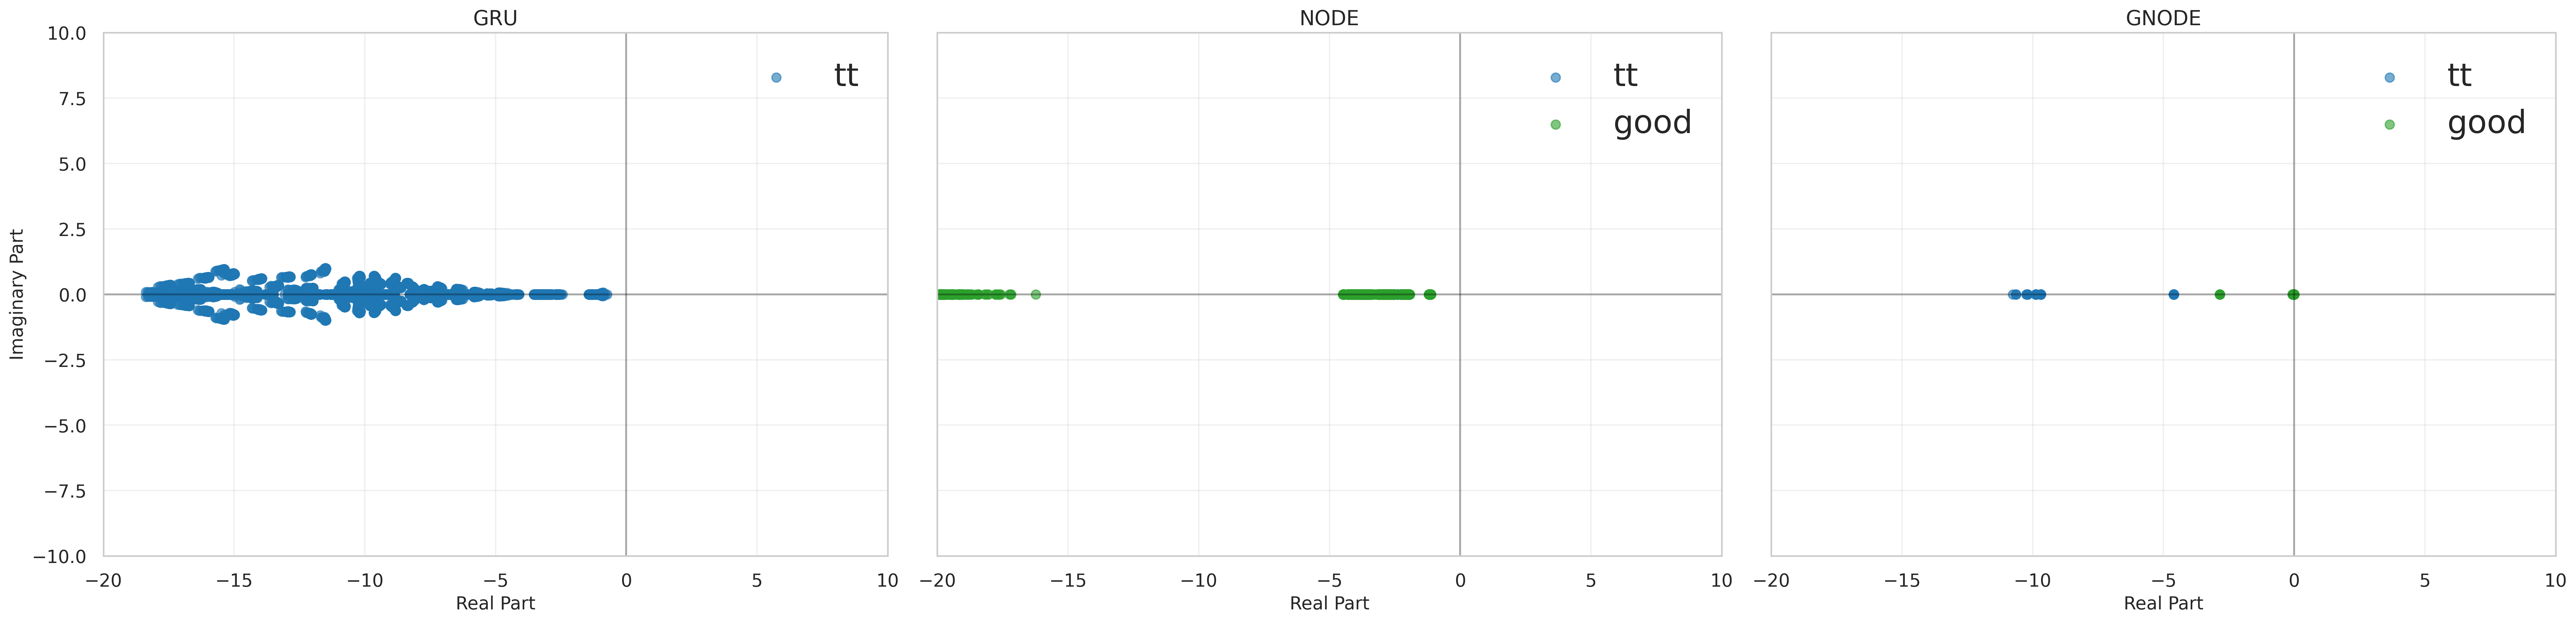

/tmp/ipykernel_1856490/3702474366.py:540: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


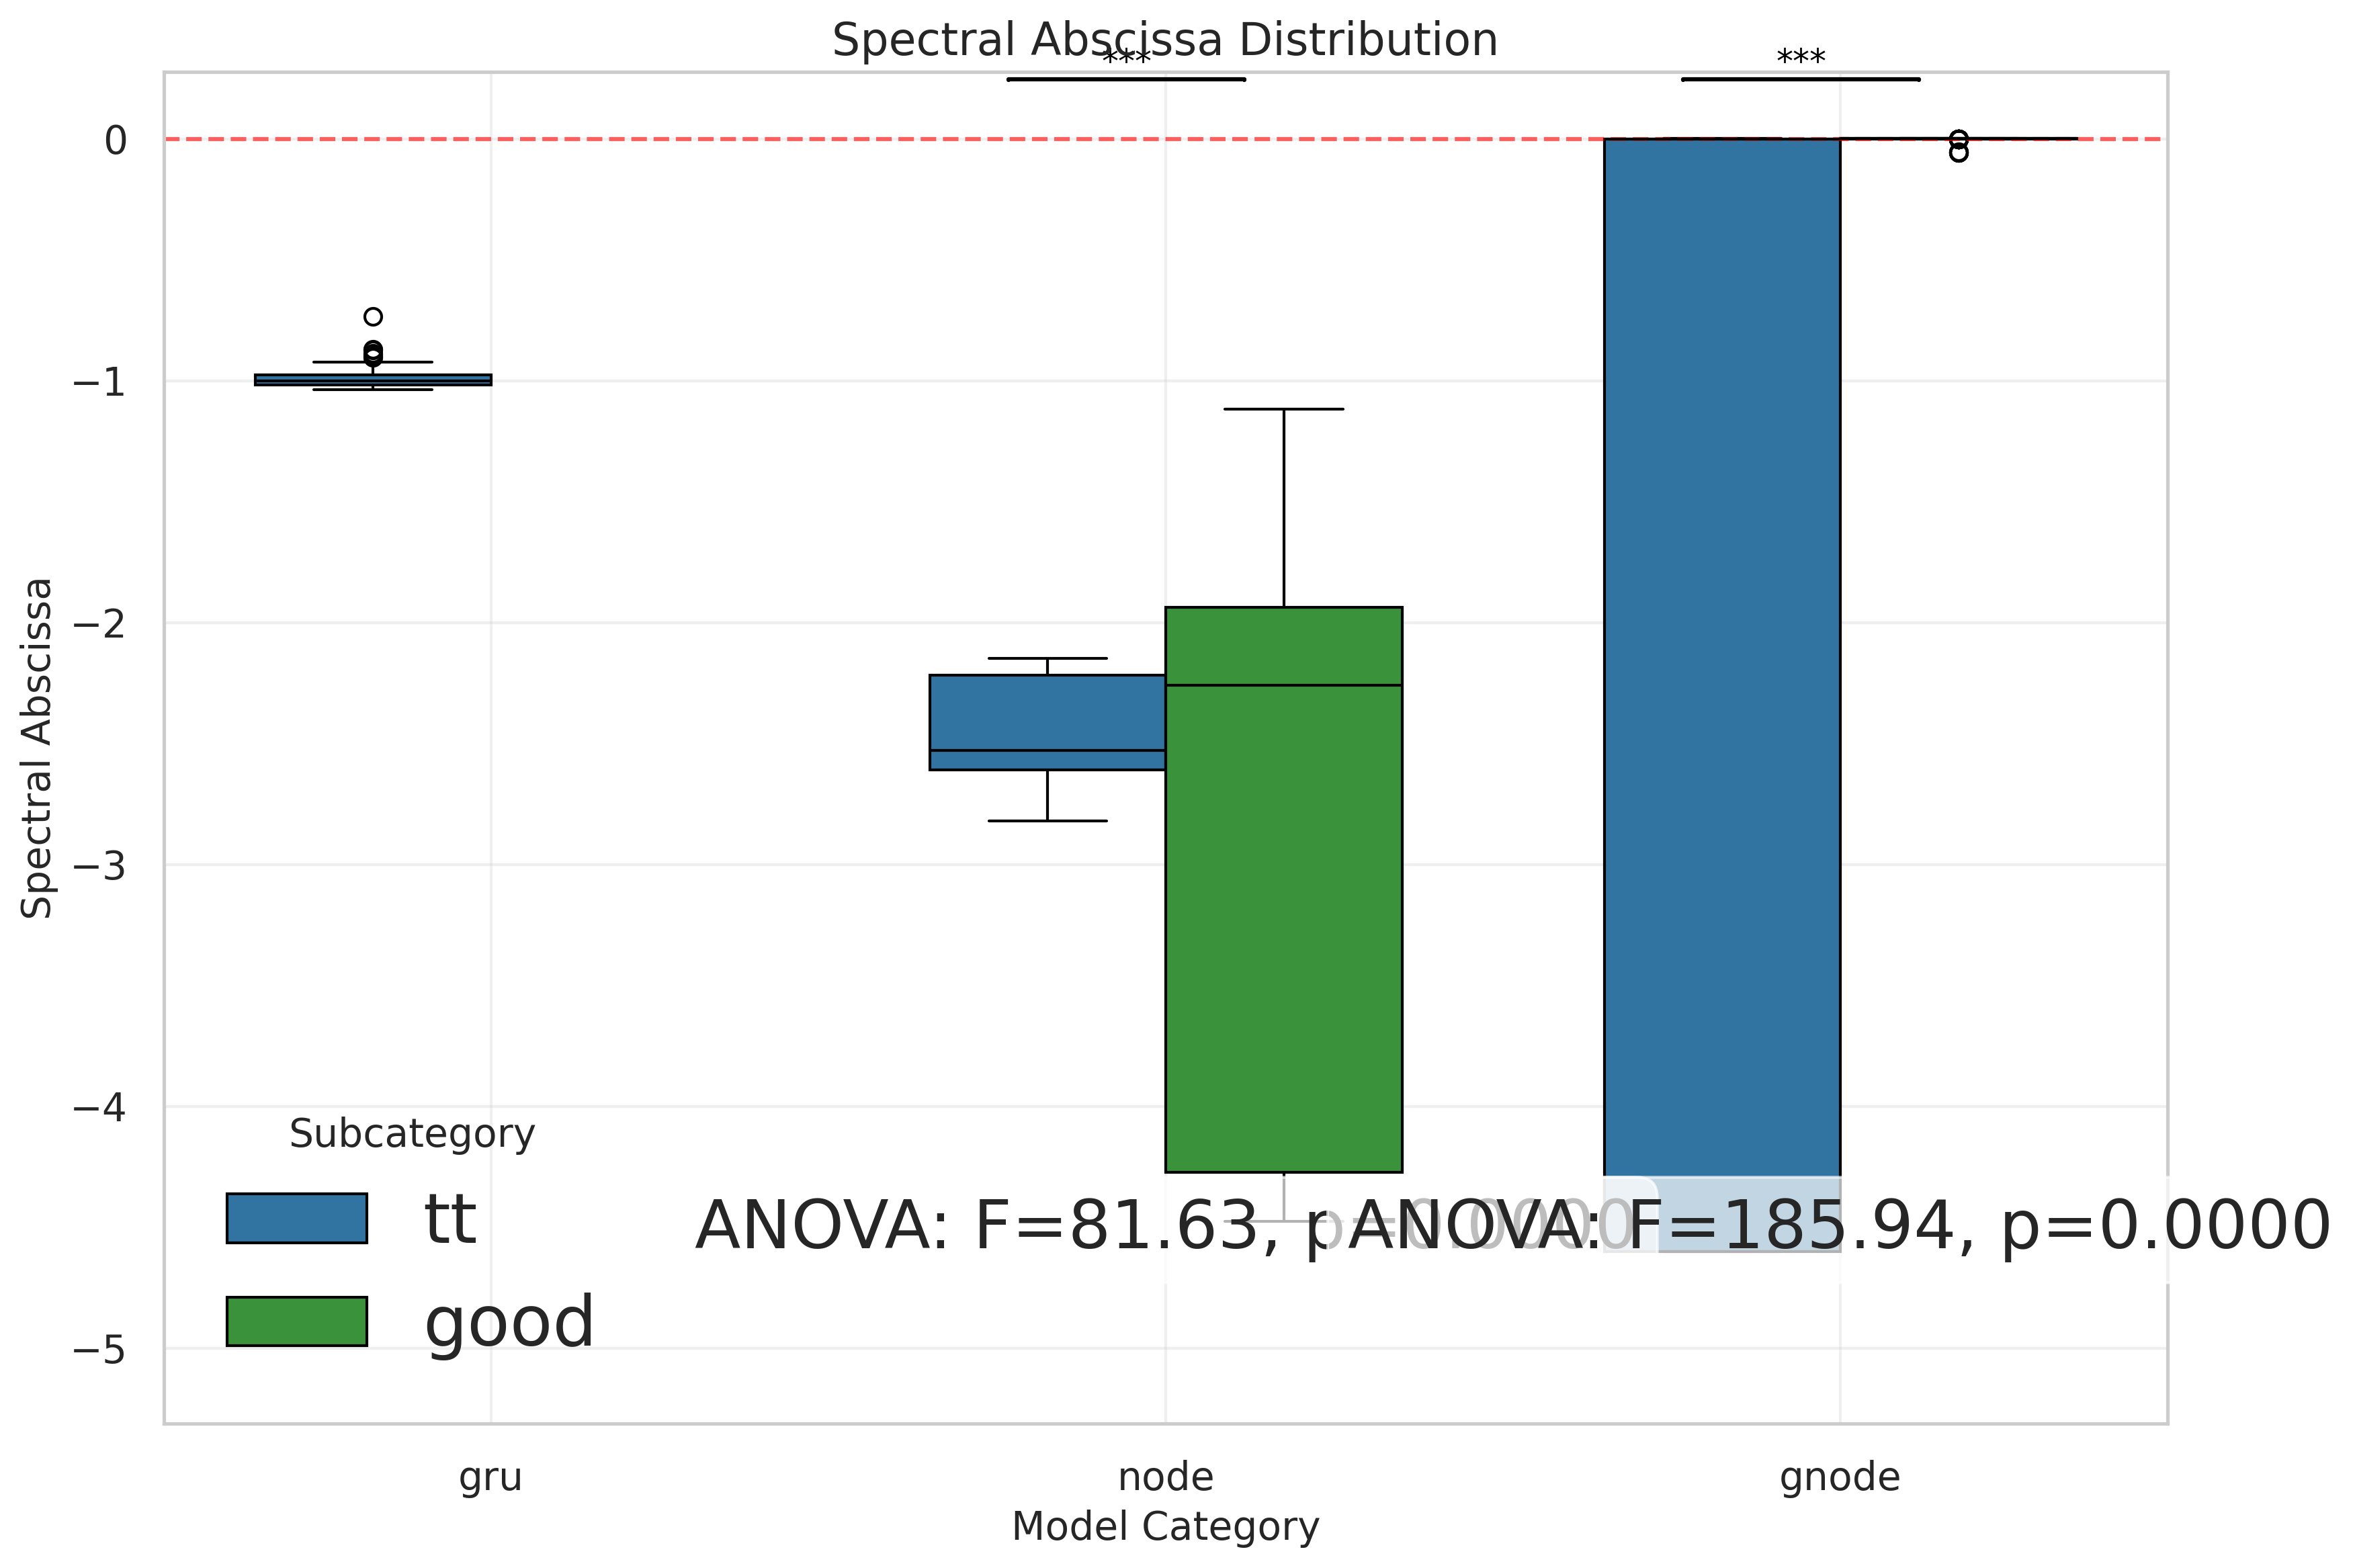

/tmp/ipykernel_1856490/3702474366.py:574: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_1856490/3702474366.py:574: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


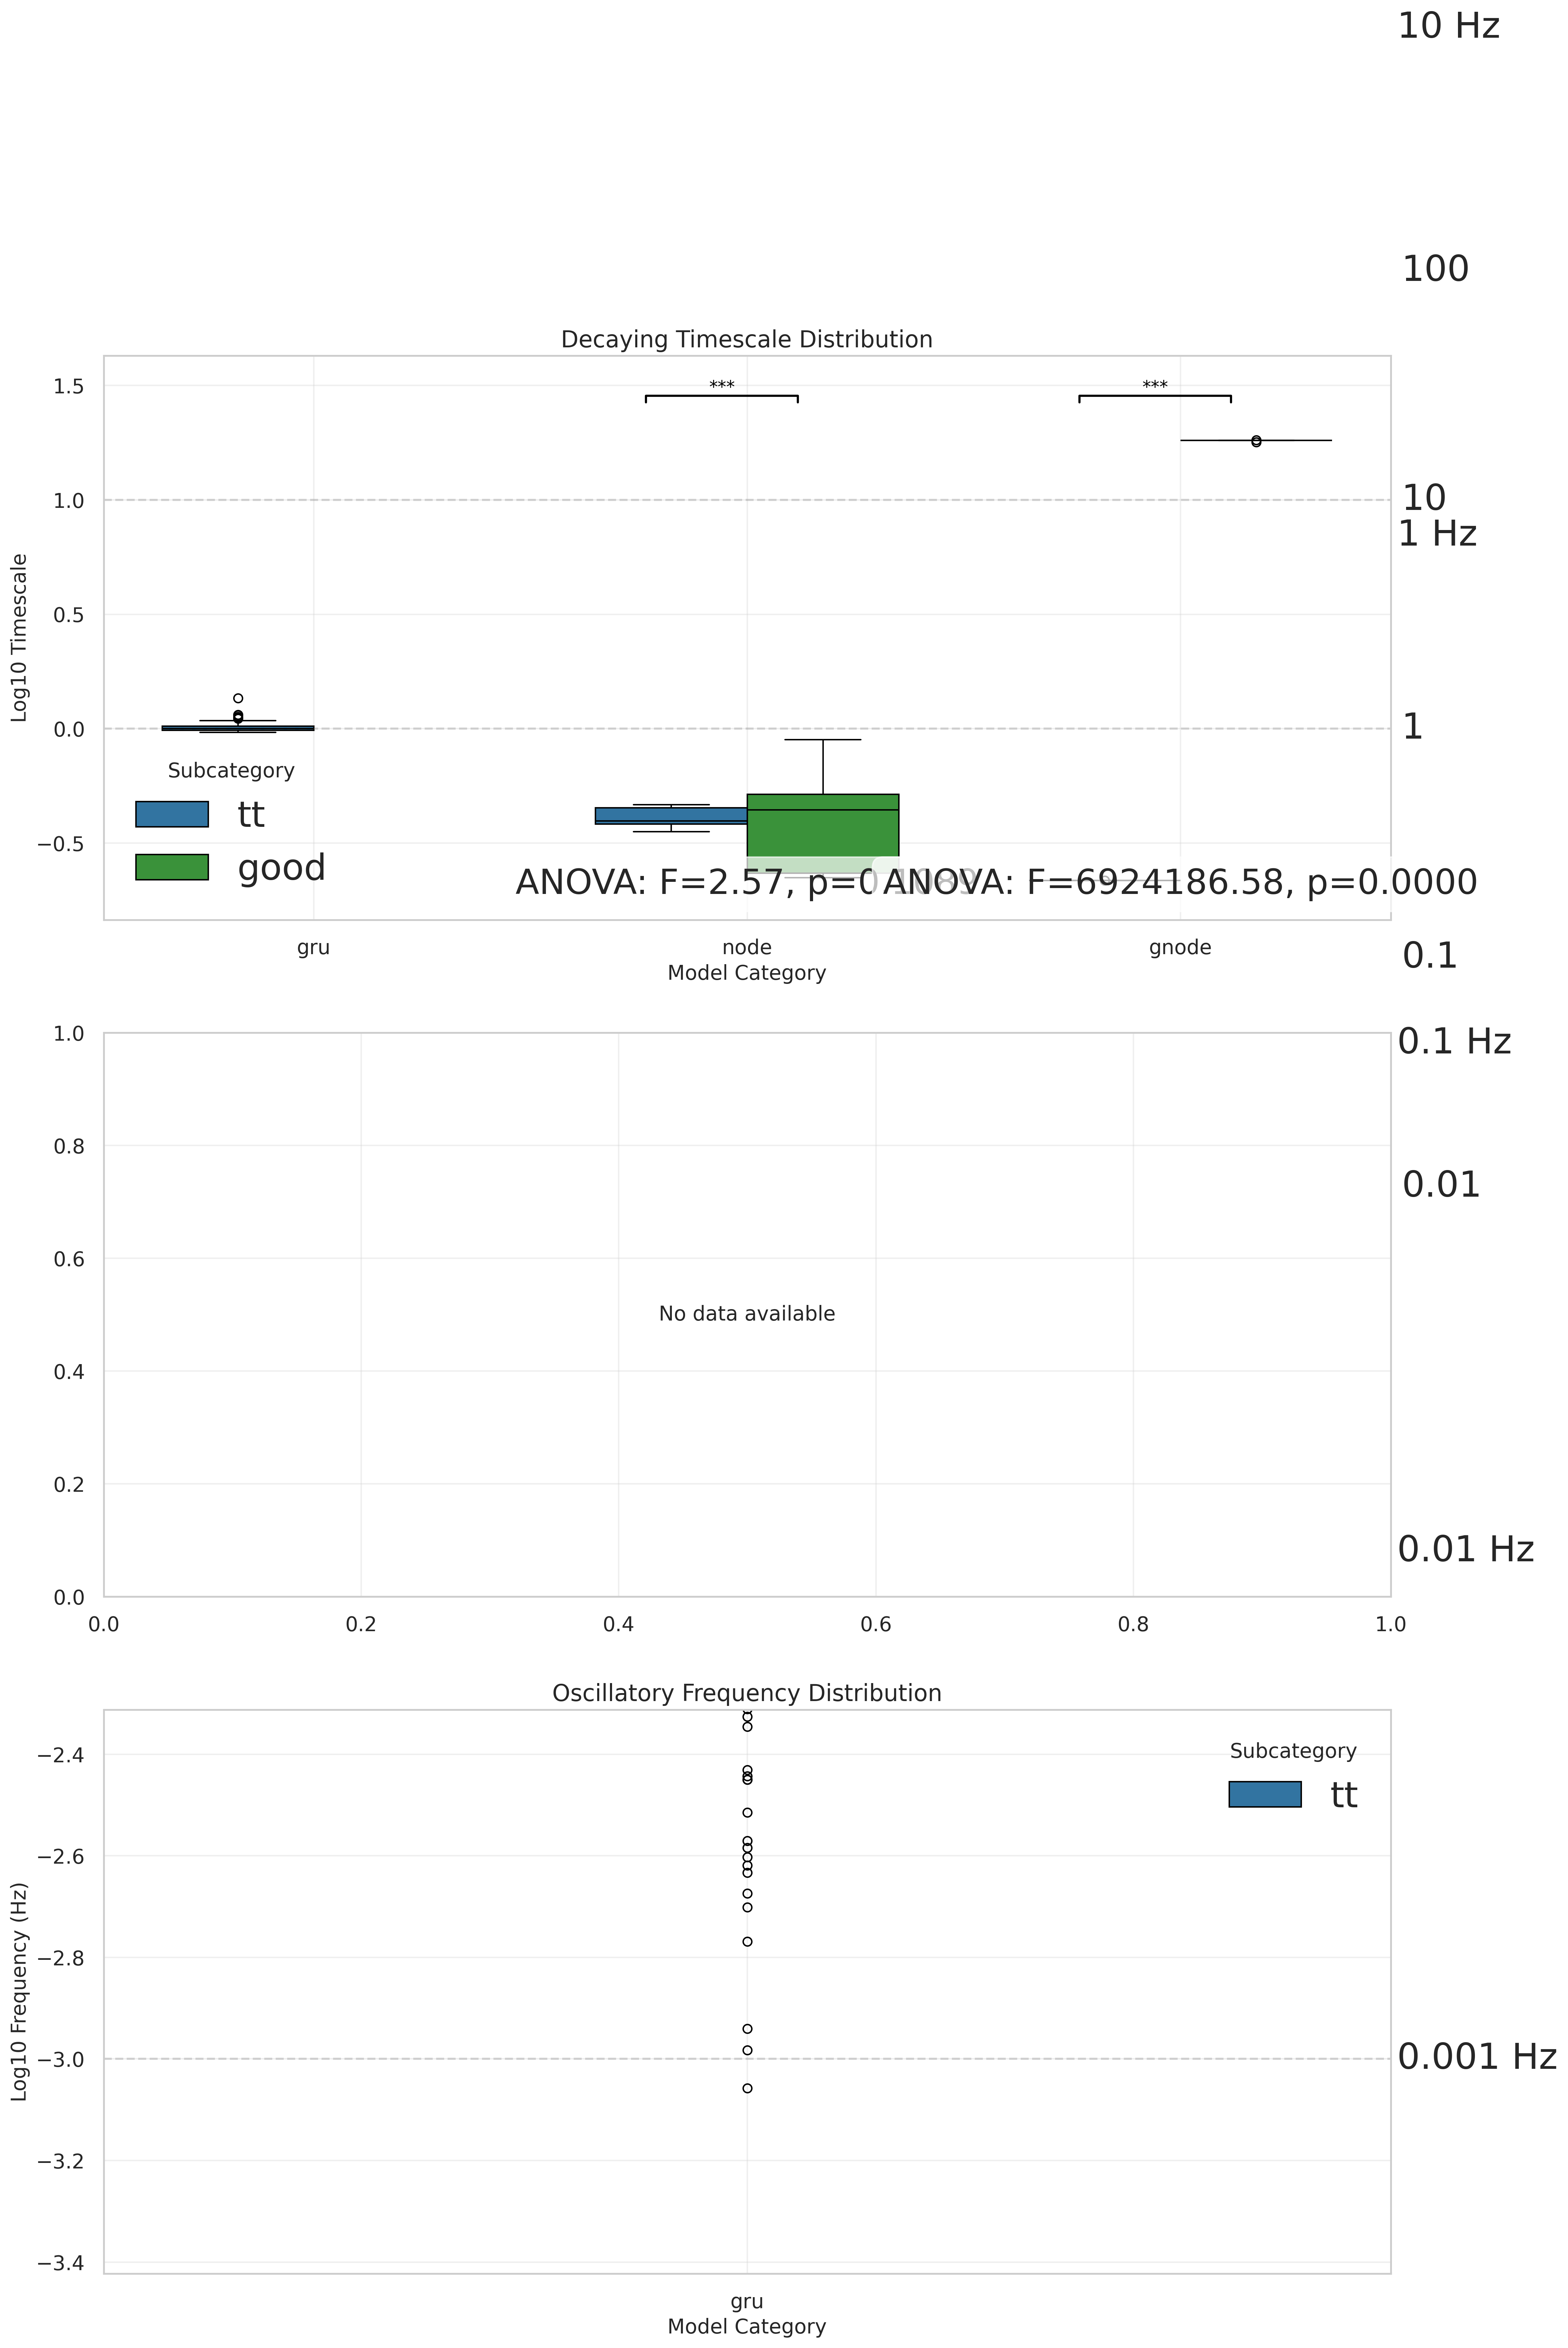

/tmp/ipykernel_1856490/3702474366.py:881: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


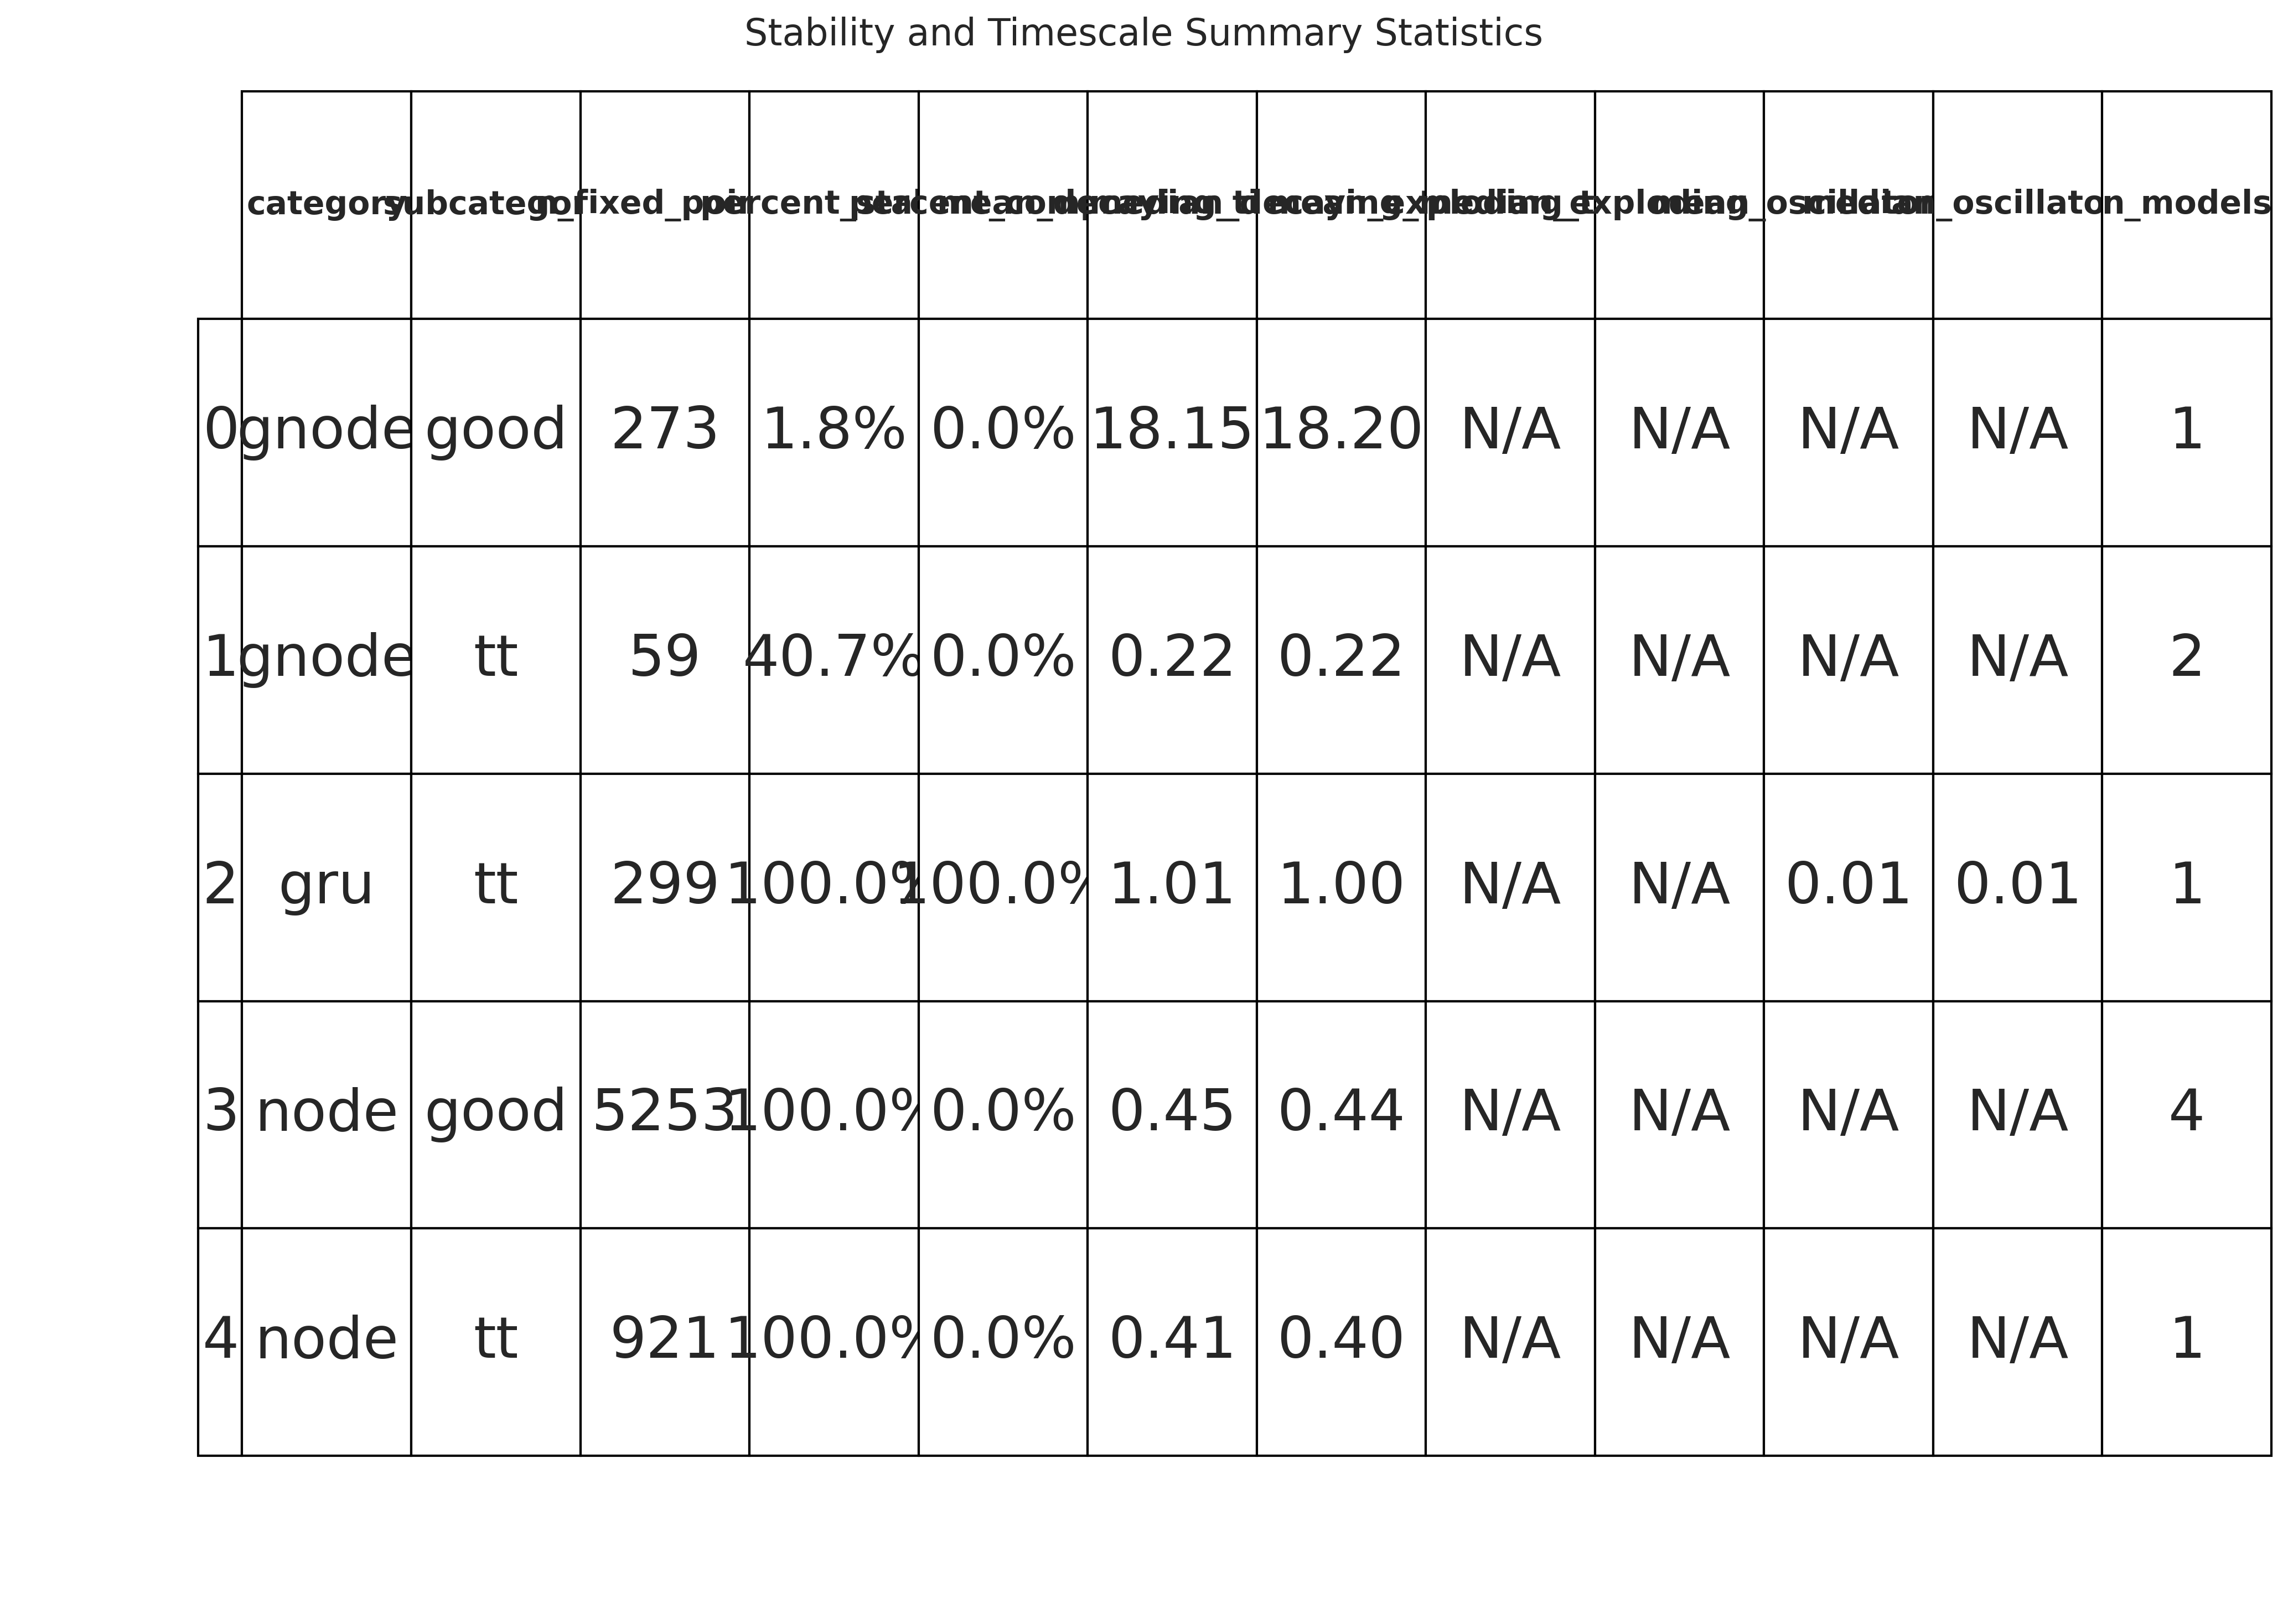

In [32]:
# 2. Visualize the results
visualizer = StabilityVisualizer(analyzer)

# Create all visualizations
visualizer.plot_eigenvalue_spectra(save_path="eigenvalue_spectra.png")
visualizer.plot_spectral_abscissa_distribution(save_path="spectral_abscissa.png")
visualizer.plot_timescale_distributions(save_path="timescales.png")
visualizer.plot_summary_statistics(save_path="summary.png")

# You can also access the data directly
summary_stats = analyzer.get_summary_statistics()
combined_results = analyzer.get_combined_results()

In [22]:
import numpy as np
import pandas as pd
from scipy import stats
import re
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from itertools import combinations

class StabilityAnalyzer:
    """Comprehensive stability and timescale analysis for dynamical systems fixed points."""
    
    def __init__(self, tau_param=1.0, q_threshold=1e-3, stability_threshold=1e-8):
        """
        Initialize the analyzer with analysis parameters.
        
        Args:
            tau_param: Membrane time constant (default 1.0)
            q_threshold: Threshold for discarding fixed points with qstar > threshold
            stability_threshold: Threshold for determining stability (real parts must be below this)
        """
        self.tau_param = tau_param
        self.q_threshold = q_threshold
        self.stability_threshold = stability_threshold
        self.results = None
    
    def analyze(self, fps_list, file_paths, delta_t_list, alpha_list, 
                categories, subcategories, filter_box=None, filter_code="000"):
        """
        Main analysis function that processes all fixed points.
        
        Args:
            fps_list: List of FixedPoint objects
            file_paths: List of file paths containing model info
            delta_t_list: List of delta_t values for each model
            alpha_list: List of alpha values for each model
            categories: List of model categories (gru, node, gnode)
            subcategories: List of subcategories (tt, good_dd, underfitting, inventing_features)
            filter_box: Spatial filtering box ((x_min, x_max), (y_min, y_max))
            filter_code: Parameter code filter (e.g., "000")
            
        Returns:
            Dictionary containing all analysis results
        """
        # Input validation
        self._validate_inputs(fps_list, file_paths, delta_t_list, alpha_list, 
                            categories, subcategories)
        
        # Initialize results storage
        self.results = {
            'model_data': [],
            'combined_df': None,
            'summary_stats': None
        }
        
        # Process each model
        for i, fps in enumerate(fps_list):
            model_results = self._analyze_single_model(
                fps, file_paths[i], delta_t_list[i], alpha_list[i],
                categories[i], subcategories[i], filter_box, filter_code
            )
            if model_results:
                self.results['model_data'].append(model_results)
        
        # Combine all results into a dataframe
        if self.results['model_data']:
            self._combine_results()
            self._compute_summary_statistics()
        
        return self.results
    
    def _validate_inputs(self, fps_list, file_paths, delta_t_list, alpha_list,
                       categories, subcategories):
        """Validate all input lists have matching lengths."""
        n_models = len(fps_list)
        if not all(len(lst) == n_models for lst in 
                  [file_paths, delta_t_list, alpha_list, categories, subcategories]):
            raise ValueError("All input lists must have the same length")
    
    def _analyze_single_model(self, fps, file_path, delta_t, alpha, 
                            category, subcategory, filter_box, filter_code):
        """Analyze fixed points for a single model."""
        # Extract parameter code from file path
        param_match = re.search(r'_(\d{3})', file_path)
        param_code = param_match.group(1) if param_match else "unknown"
        
        # Filter fixed points
        filtered_fps = self._filter_fixed_points(
            fps, category, param_code, filter_box, filter_code
        )
        
        if len(filtered_fps['J_xstar']) == 0:
            print(f"Warning: No fixed points remain after filtering for {file_path}")
            return None
        
        # Initialize results structure
        model_results = {
            'file_path': file_path,
            'category': category.lower(),
            'subcategory': subcategory.lower(),
            'param_code': param_code,
            'delta_t': delta_t,
            'alpha': alpha,
            'n_fixed_points': len(filtered_fps['J_xstar']),
            'fixed_points': []
        }
        
        # Analyze each fixed point
        for i, J_discrete in enumerate(filtered_fps['J_xstar']):
            fp_result = self._analyze_single_fp(
                J_discrete, 
                filtered_fps['xstar'][i] if len(filtered_fps['xstar']) > 0 else None,
                delta_t
            )
            model_results['fixed_points'].append(fp_result)
        
        # Compute model-level statistics
        model_results.update(self._compute_model_stats(model_results))
        
        return model_results
    
    def _filter_fixed_points(self, fps, model_type, param_code, filter_box, filter_code):
        """Filter fixed points based on various criteria."""
        indices_to_keep = []
        
        for i in range(len(fps.xstar)):
            # Check qstar threshold
            if hasattr(fps, 'qstar'):
                if model_type == "gnode" and fps.qstar[i] > 1e-9:
                    continue
                elif fps.qstar[i] > self.q_threshold:
                    continue
            
            # Filter by parameter code
            if filter_code is not None and param_code != filter_code:
                continue
            
            # Spatial filtering
            if filter_box is not None:
                (x_min, x_max), (y_min, y_max) = filter_box
                x, y = fps.xstar[i][0], fps.xstar[i][1]
                
                # Different bounds for different model types
                if model_type == "node":
                    if not (x_min <= x <= x_max and y_min <= y <= y_max):
                        continue
                elif model_type == "gnode":
                    if not (x_min+1 <= x <= x_max-1 and y_min+1 <= y <= y_max-1):
                        continue
            
            indices_to_keep.append(i)
        
        # Create filtered fps object
        filtered_fps = {
            'xstar': fps.xstar[indices_to_keep] if indices_to_keep else np.array([]),
            'J_xstar': [fps.J_xstar[i] for i in indices_to_keep] if indices_to_keep else []
        }
        
        if hasattr(fps, 'qstar'):
            filtered_fps['qstar'] = fps.qstar[indices_to_keep] if indices_to_keep else np.array([])
        
        return filtered_fps
    
    def _analyze_single_fp(self, J_discrete, coords=None, delta_t=0.1):
        """Analyze stability and timescales for a single fixed point."""
        result = {
            'coords': coords,
            'eigenvalues': None,
            'is_stable': False,
            'spectral_abscissa': np.nan,
            'decaying_timescale': np.nan,
            'exploding_timescale': np.nan,
            'has_complex': False,
            'oscillatory_freq': 0
        }
        
        try:
            # Calculate continuous Jacobian
            D = (J_discrete - np.eye(*J_discrete.shape))/delta_t
            e_vals, _ = np.linalg.eig(D)
            result['eigenvalues'] = e_vals
            
            # Stability analysis
            real_parts = np.real(e_vals)
            result['is_stable'] = np.all(real_parts < -self.stability_threshold)
            
            # Spectral abscissa (maximum real part)
            spectral_abscissa = np.max(real_parts)
            result['spectral_abscissa'] = spectral_abscissa
            
            # Timescales
            if spectral_abscissa < -self.stability_threshold:
                result['decaying_timescale'] = -self.tau_param / spectral_abscissa
            elif spectral_abscissa > self.stability_threshold:
                result['exploding_timescale'] = self.tau_param / spectral_abscissa
            
            # Oscillatory components
            imag_parts = np.imag(e_vals)
            result['has_complex'] = np.any(np.abs(imag_parts) > 1e-10)
            
            if result['has_complex']:
                complex_indices = np.where(np.abs(imag_parts) > 1e-10)[0]
                complex_real_parts = real_parts[complex_indices]
                idx = complex_indices[np.argmax(complex_real_parts)]
                result['oscillatory_freq'] = np.abs(imag_parts[idx]) / (2 * np.pi)
        
        except np.linalg.LinAlgError:
            pass
        
        return result
    
    def _compute_model_stats(self, model_results):
        """Compute summary statistics for a single model."""
        stats = {
            'percent_stable': 0,
            'percent_complex': 0,
            'mean_decaying_timescale': np.nan,
            'median_decaying_timescale': np.nan,
            'mean_exploding_timescale': np.nan,
            'median_exploding_timescale': np.nan,
            'mean_oscillatory_freq': np.nan,
            'median_oscillatory_freq': np.nan  # Added median oscillatory frequency
        }
        
        if not model_results['fixed_points']:
            return stats
        
        # Convert to arrays for vectorized operations
        is_stable = np.array([fp['is_stable'] for fp in model_results['fixed_points']])
        has_complex = np.array([fp['has_complex'] for fp in model_results['fixed_points']])
        decaying = np.array([fp['decaying_timescale'] for fp in model_results['fixed_points']])
        exploding = np.array([fp['exploding_timescale'] for fp in model_results['fixed_points']])
        freqs = np.array([fp['oscillatory_freq'] for fp in model_results['fixed_points']])
        
        # Compute statistics
        stats['percent_stable'] = np.mean(is_stable) * 100
        stats['percent_complex'] = np.mean(has_complex) * 100
        
        valid_decaying = ~np.isnan(decaying)
        if np.any(valid_decaying):
            stats['mean_decaying_timescale'] = np.mean(decaying[valid_decaying])
            stats['median_decaying_timescale'] = np.median(decaying[valid_decaying])
        
        valid_exploding = ~np.isnan(exploding)
        if np.any(valid_exploding):
            stats['mean_exploding_timescale'] = np.mean(exploding[valid_exploding])
            stats['median_exploding_timescale'] = np.median(exploding[valid_exploding])
        
        complex_freqs = freqs[has_complex & (freqs > 0)]
        if len(complex_freqs) > 0:
            stats['mean_oscillatory_freq'] = np.mean(complex_freqs)
            stats['median_oscillatory_freq'] = np.median(complex_freqs)  # Added median calculation
        
        return stats
    
    def _combine_results(self):
        """Combine all model results into a single dataframe."""
        rows = []
        
        for model in self.results['model_data']:
            for fp in model['fixed_points']:
                row = {
                    'file_path': model['file_path'],
                    'category': model['category'],
                    'subcategory': model['subcategory'],
                    'param_code': model['param_code'],
                    'delta_t': model['delta_t'],
                    'alpha': model['alpha'],
                    'is_stable': fp['is_stable'],
                    'spectral_abscissa': fp['spectral_abscissa'],
                    'decaying_timescale': fp['decaying_timescale'],
                    'exploding_timescale': fp['exploding_timescale'],
                    'has_complex': fp['has_complex'],
                    'oscillatory_freq': fp['oscillatory_freq'],
                    'eigenvalues': fp['eigenvalues']
                }
                
                # Add coordinates if available
                if fp['coords'] is not None:
                    for dim, val in enumerate(fp['coords']):
                        row[f'coord_{dim}'] = val
                
                rows.append(row)
    
        self.results['combined_df'] = pd.DataFrame(rows)
        
    def _compute_summary_statistics(self):
        """Compute comprehensive summary statistics across all models."""
        if self.results['combined_df'] is None:
            return
        
        # Group by category and subcategory
        grouped = self.results['combined_df'].groupby(['category', 'subcategory'])
        
        stats = []
        
        for (category, subcategory), group in grouped:
            # Basic counts
            n_fps = len(group)
            n_stable = group['is_stable'].sum()
            n_complex = group['has_complex'].sum()
            
            # Timescale statistics
            decaying = group['decaying_timescale'].dropna()
            exploding = group['exploding_timescale'].dropna()
            freqs = group.loc[group['oscillatory_freq'] > 0, 'oscillatory_freq']
            
            stats.append({
                'category': category,
                'subcategory': subcategory,
                'n_fixed_points': n_fps,
                'percent_stable': (n_stable / n_fps) * 100 if n_fps > 0 else 0,
                'percent_complex': (n_complex / n_fps) * 100 if n_fps > 0 else 0,
                'mean_decaying_timescale': decaying.mean() if len(decaying) > 0 else np.nan,
                'median_decaying_timescale': decaying.median() if len(decaying) > 0 else np.nan,
                'mean_exploding_timescale': exploding.mean() if len(exploding) > 0 else np.nan,
                'median_exploding_timescale': exploding.median() if len(exploding) > 0 else np.nan,
                'mean_oscillatory_freq': freqs.mean() if len(freqs) > 0 else np.nan,
                'median_oscillatory_freq': freqs.median() if len(freqs) > 0 else np.nan,  # Added median frequency
                'n_models': group['file_path'].nunique()
            })
        
        self.results['summary_stats'] = pd.DataFrame(stats)
    
    def get_summary_statistics(self):
        """Return the computed summary statistics."""
        return self.results['summary_stats'] if self.results else None
    
    def get_combined_results(self):
        """Return the combined results dataframe."""
        return self.results['combined_df'] if self.results else None


class StabilityVisualizer:
    """Enhanced visualization tools with statistical testing and improved formatting."""
    
    def __init__(self, analyzer=None):
        self.analyzer = analyzer
        self.subcategory_palette = {
            'tt': '#1f77b4',       # Blue
            'good': '#2ca02c',  # Green
            'underfit': '#d62728',  # Red
            'invent': '#9467bd',  # Purple
            'unknown': "black"
        }
        self.fontsize = 14
        self.title_fontsize = 16
        self.label_fontsize = 14
        self.ticks_fontsize = 25
        
    def set_analyzer(self, analyzer):
        self.analyzer = analyzer
        
    def _configure_plot(self, ax, title=None):
        """Configure plot appearance with consistent styling."""
        if title:
            ax.set_title(title, fontsize=self.title_fontsize, pad=15)
        ax.tick_params(axis='both', which='major', labelsize=self.ticks_fontsize)
        for item in ([ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
            item.set_fontsize(self.label_fontsize)
        ax.grid(True, alpha=0.3)
        return ax
    
    def _add_statistical_annotation(self, ax, x1, x2, y, pvalue):
        """Add statistical annotation between two groups."""
        line_y = y * 1.02  # Slightly above the max value
        ax.plot([x1, x1, x2, x2], [y, line_y, line_y, y], lw=1.5, color='k')
        
        if pvalue < 0.001:
            text = '***'
        elif pvalue < 0.01:
            text = '**'
        elif pvalue < 0.05:
            text = '*'
        else:
            text = f'p={pvalue:.2f}'
            
        ax.text((x1+x2)*0.5, line_y, text, ha='center', va='bottom', 
                fontsize=self.fontsize-2, color='k')
    
    def _perform_pairwise_tests(self, df, value_col, group_col):
        """Perform pairwise t-tests between all groups."""
        groups = df[group_col].unique()
        results = []
        
        for (group1, group2) in combinations(groups, 2):
            data1 = df[df[group_col] == group1][value_col].dropna()
            data2 = df[df[group_col] == group2][value_col].dropna()
            
            if len(data1) > 1 and len(data2) > 1:  # Need at least 2 samples for t-test
                _, pvalue = stats.ttest_ind(data1, data2, equal_var=False)
                results.append((group1, group2, pvalue))
        
        return results
    
    def _perform_anova(self, df, value_col, group_col):
        """Perform one-way ANOVA test across all groups."""
        groups = df[group_col].unique()
        data_groups = []
        
        # Collect data for each group
        for group in groups:
            group_data = df[df[group_col] == group][value_col].dropna()
            if len(group_data) > 0:
                data_groups.append(group_data)
        
        # Perform ANOVA only if we have at least 2 groups with data
        if len(data_groups) >= 2 and all(len(group) > 1 for group in data_groups):
            f_val, p_val = stats.f_oneway(*data_groups)
            return {
                'f_statistic': f_val,
                'p_value': p_val,
                'significant': p_val < 0.05
            }
        return None
    
    def plot_eigenvalue_spectra(self, figsize=(28, 20), save_path=None):
        """Plot eigenvalue spectra with statistical comparisons."""
        df = self.analyzer.get_combined_results()
        categories = df['category'].unique()
        
        fig, axes = plt.subplots(1, len(categories), figsize=figsize, 
                                sharex=True, sharey=True, squeeze=False)
        axes = axes[0]
        
        for i, category in enumerate(categories):
            ax = axes[i]
            cat_df = df[df['category'] == category]
            
            # Plot each subcategory
            for subcat, color in self.subcategory_palette.items():
                subcat_df = cat_df[cat_df['subcategory'] == subcat]
                if len(subcat_df) == 0:
                    continue
                
                eigvals = []
                for val in subcat_df['eigenvalues'].values:
                    if val is not None and not all(np.isnan(val)):
                        eigvals.extend(val)
                
                eigvals = np.array(eigvals)
                eigvals = eigvals[~np.isnan(eigvals)]
                
                if len(eigvals) > 0:
                    ax.scatter(np.real(eigvals), np.imag(eigvals), 
                             alpha=0.6, color=color, s=50, label=subcat)
            
            # Reference lines and styling
            ax.axhline(0, color='k', linestyle='-', alpha=0.3)
            ax.axvline(0, color='k', linestyle='-', alpha=0.3)
            theta = np.linspace(0, 2*np.pi, 100)
#             ax.plot(np.cos(theta), np.sin(theta), 'r--', alpha=0.3, linewidth=10)
            
            ax.set_xlabel('Real Part', fontsize=self.label_fontsize)
            ax.set_title(f"{category.upper()}", fontsize=self.title_fontsize)
            if i == 0:
                ax.set_ylabel('Imaginary Part', fontsize=self.label_fontsize)
            
            ax.legend(fontsize=self.ticks_fontsize)
            ax.set_aspect('equal')
            ax.set_xlim(-20,10)
            ax.set_ylim(-10, 10)
            self._configure_plot(ax)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_spectral_abscissa_distribution(self, figsize=(12, 8), save_path=None):
        """Plot spectral abscissa with statistical comparisons."""
        df = self.analyzer.get_combined_results()
        plot_df = df[~np.isnan(df['spectral_abscissa'])].copy()
        
        fig, ax = plt.subplots(figsize=figsize)
        
        if len(plot_df) > 0:
            # Create boxplot
            box = sns.boxplot(
                data=plot_df, 
                x='category', 
                y='spectral_abscissa', 
                hue='subcategory',
                palette=self.subcategory_palette,
                ax=ax,
                width=0.7
            )
            
            # Add stability threshold line
            ax.axhline(0, color='r', linestyle='--', alpha=0.6)
            
            # Get current y-axis limits
            ymin, ymax = ax.get_ylim()
            
            # Perform and plot ANOVA test for each category
            for category_idx, category in enumerate(plot_df['category'].unique()):
                cat_df = plot_df[plot_df['category'] == category]
                
                # ANOVA test
                anova_result = self._perform_anova(cat_df, 'spectral_abscissa', 'subcategory')
                
                # Add ANOVA result as text annotation
                if anova_result:
                    ax.text(category_idx, ymin * 0.95, 
                           f"ANOVA: F={anova_result['f_statistic']:.2f}, p={anova_result['p_value']:.4f}",
                           ha='center', fontsize=self.ticks_fontsize-1,
                           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
                
                # Perform and plot pairwise t-tests
                test_results = self._perform_pairwise_tests(cat_df, 'spectral_abscissa', 'subcategory')
                
                # Get positions of boxes for this category
                boxes = [patch for patch in ax.patches 
                        if patch.get_path().vertices[:, 0].mean() > category_idx - 0.5 
                        and patch.get_path().vertices[:, 0].mean() < category_idx + 0.5]
                boxes.sort(key=lambda x: x.get_path().vertices[:, 0].mean())
                
                for i, (group1, group2, pvalue) in enumerate(test_results):
                    # Get x positions based on box positions
                    x1 = boxes[list(self.subcategory_palette.keys()).index(group1)].get_path().vertices[:, 0].mean()
                    x2 = boxes[list(self.subcategory_palette.keys()).index(group2)].get_path().vertices[:, 0].mean()
                    
                    # Calculate y position above the highest box
                    y = ymax * (1.0 + 0.05 * (i + 1))
                    self._add_statistical_annotation(ax, x1, x2, y, pvalue)
            
            # Adjust ylim to accommodate annotations
            ax.set_ylim(ymin * 1.1, ymax * 1.2)
            
            ax.set_xlabel('Model Category', fontsize=self.label_fontsize)
            ax.set_ylabel('Spectral Abscissa', fontsize=self.label_fontsize)
            ax.set_title('Spectral Abscissa Distribution', fontsize=self.title_fontsize)
            ax.legend(title='Subcategory', fontsize=self.ticks_fontsize, 
                     title_fontsize=self.label_fontsize)
        else:
            ax.text(0.5, 0.5, 'No data available', fontsize=self.fontsize,
                   horizontalalignment='center', verticalalignment='center')
        
        self._configure_plot(ax)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_timescale_distributions(self, figsize=(16, 24), save_path=None):
        """Plot timescale distributions with statistical comparisons."""
        df = self.analyzer.get_combined_results()
        
        # Now include 3 panels: decaying, exploding, and oscillatory
        fig = plt.figure(figsize=figsize)
        gs = gridspec.GridSpec(3, 1)
        
        # Decaying timescales
        ax1 = plt.subplot(gs[0, 0])
        self._plot_timescale_panel(
            df, 'decaying_timescale', ax1, 
            'Decaying Timescale Distribution'
        )
        
        # Exploding timescales
        ax2 = plt.subplot(gs[1, 0])
        self._plot_timescale_panel(
            df, 'exploding_timescale', ax2,
            'Exploding Timescale Distribution'
        )
        
        # Oscillatory frequencies - new panel
        ax3 = plt.subplot(gs[2, 0])
        self._plot_frequency_panel(
            df, 'oscillatory_freq', ax3,
            'Oscillatory Frequency Distribution'
        )
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def _plot_timescale_panel(self, df, column, ax, title):
        """Helper function to plot timescale distributions."""
        plot_df = df[~np.isnan(df[column])].copy()
        
        if len(plot_df) > 0:
            # Convert to log scale
            plot_df['log_timescale'] = np.log10(np.abs(plot_df[column]))
            
            # Create boxplot
            box = sns.boxplot(
                data=plot_df,
                x='category',
                y='log_timescale',
                hue='subcategory',
                palette=self.subcategory_palette,
                ax=ax,
                width=0.7
            )
            
            # Get current y-axis limits
            ymin, ymax = ax.get_ylim()
            
            # Perform and plot ANOVA test for each category
            for category_idx, category in enumerate(plot_df['category'].unique()):
                cat_df = plot_df[plot_df['category'] == category]
                
                # ANOVA test
                anova_result = self._perform_anova(cat_df, 'log_timescale', 'subcategory')
                
                # Add ANOVA result as text annotation
                if anova_result:
                    ax.text(category_idx, ymin * 0.95, 
                           f"ANOVA: F={anova_result['f_statistic']:.2f}, p={anova_result['p_value']:.4f}",
                           ha='center', fontsize=self.ticks_fontsize-1,
                           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
                
                # Perform and plot pairwise t-tests
                test_results = self._perform_pairwise_tests(cat_df, 'log_timescale', 'subcategory')
                
                # Get positions of boxes for this category
                boxes = [patch for patch in ax.patches 
                        if patch.get_path().vertices[:, 0].mean() > category_idx - 0.5 
                        and patch.get_path().vertices[:, 0].mean() < category_idx + 0.5]
                boxes.sort(key=lambda x: x.get_path().vertices[:, 0].mean())
                
                # Only process if we have the expected boxes
                if len(boxes) >= 2:
                    for i, (group1, group2, pvalue) in enumerate(test_results):
                        # Get x positions based on box positions
                        try:
                            x1 = boxes[list(self.subcategory_palette.keys()).index(group1)].get_path().vertices[:, 0].mean()
                            x2 = boxes[list(self.subcategory_palette.keys()).index(group2)].get_path().vertices[:, 0].mean()
                            
                            # Calculate y position above the highest box
                            y = ymax * (1.0 + 0.05 * (i + 1))
                            self._add_statistical_annotation(ax, x1, x2, y, pvalue)
                        except (ValueError, IndexError):
                            # Skip if we can't find the right box
                            continue
            
            # Adjust ylim to accommodate annotations
            ax.set_ylim(ymin * 1.1, ymax * 1.2)
            
            # Reference lines (without 's' or 'seconds')
            time_refs = [0.01, 0.1, 1, 10, 100]
            for t in time_refs:
                ax.axhline(np.log10(t), color='gray', linestyle='--', alpha=0.3)
                ax.text(ax.get_xlim()[1] * 1.01, np.log10(t), f"{t}", 
                       va='center', ha='left', fontsize=self.ticks_fontsize)
            
            ax.set_xlabel('Model Category', fontsize=self.label_fontsize)
            ax.set_ylabel('Log10 Timescale', fontsize=self.label_fontsize)
            ax.set_title(title, fontsize=self.title_fontsize)
            ax.legend(title='Subcategory', fontsize=self.ticks_fontsize, 
                     title_fontsize=self.label_fontsize)
        else:
            ax.text(0.5, 0.5, 'No data available', fontsize=self.fontsize,
                   horizontalalignment='center', verticalalignment='center')
        
        self._configure_plot(ax)
    
    def _plot_frequency_panel(self, df, column, ax, title):
        """Helper function to plot oscillatory frequency distributions."""
        # Only use data points with oscillatory components (has_complex = True)
        # and positive frequencies
        plot_df = df[(df['has_complex'] == True) & (df[column] > 0)].copy()
        
        if len(plot_df) > 0:
            # Convert to log scale for better visualization
            plot_df['log_freq'] = np.log10(plot_df[column])
            
            # Create boxplot
            box = sns.boxplot(
                data=plot_df,
                x='category',
                y='log_freq',
                hue='subcategory',
                palette=self.subcategory_palette,
                ax=ax,
                width=0.7
            )
            
            # Get current y-axis limits
            ymin, ymax = ax.get_ylim()
            
            # Perform and plot ANOVA test for each category
            for category_idx, category in enumerate(plot_df['category'].unique()):
                cat_df = plot_df[plot_df['category'] == category]
                
                # ANOVA test
                anova_result = self._perform_anova(cat_df, 'log_freq', 'subcategory')
                
                # Add ANOVA result as text annotation
                if anova_result:
                    ax.text(category_idx, ymin * 0.95, 
                           f"ANOVA: F={anova_result['f_statistic']:.2f}, p={anova_result['p_value']:.4f}",
                           ha='center', fontsize=self.ticks_fontsize-1,
                           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
                
                # Perform and plot pairwise t-tests
                test_results = self._perform_pairwise_tests(cat_df, 'log_freq', 'subcategory')
                
                # Get positions of boxes for this category
                boxes = [patch for patch in ax.patches 
                        if patch.get_path().vertices[:, 0].mean() > category_idx - 0.5 
                        and patch.get_path().vertices[:, 0].mean() < category_idx + 0.5]
                boxes.sort(key=lambda x: x.get_path().vertices[:, 0].mean())
                
                # Only process if we have the expected boxes
                if len(boxes) >= 2:
                    for i, (group1, group2, pvalue) in enumerate(test_results):
                        try:
                            # Get x positions based on box positions
                            x1 = boxes[list(self.subcategory_palette.keys()).index(group1)].get_path().vertices[:, 0].mean()
                            x2 = boxes[list(self.subcategory_palette.keys()).index(group2)].get_path().vertices[:, 0].mean()
                            
                            # Calculate y position above the highest box
                            y = ymax * (1.0 + 0.05 * (i + 1))
                            self._add_statistical_annotation(ax, x1, x2, y, pvalue)
                        except (ValueError, IndexError):
                            # Skip if we can't find the right box
                            continue
            
            # Adjust ylim to accommodate annotations
            ax.set_ylim(ymin * 1.1, ymax * 1.2)
            
            # Reference lines for frequency values
            freq_refs = [0.001, 0.01, 0.1, 1, 10]
            for f in freq_refs:
                ax.axhline(np.log10(f), color='gray', linestyle='--', alpha=0.3)
                ax.text(ax.get_xlim()[1] * 1.01, np.log10(f), f"{f} Hz", 
                       va='center', ha='left', fontsize=self.ticks_fontsize)
            
            ax.set_xlabel('Model Category', fontsize=self.label_fontsize)
            ax.set_ylabel('Log10 Frequency (Hz)', fontsize=self.label_fontsize)
            ax.set_title(title, fontsize=self.title_fontsize)
            ax.legend(title='Subcategory', fontsize=self.ticks_fontsize, 
                     title_fontsize=self.label_fontsize)
        else:
            ax.text(0.5, 0.5, 'No oscillatory fixed points found', fontsize=self.fontsize,
                   horizontalalignment='center', verticalalignment='center')
        
        self._configure_plot(ax)
    
    def plot_oscillatory_frequency_distribution(self, figsize=(12, 8), save_path=None):
        """Plot oscillatory frequency distribution with statistical comparisons."""
        df = self.analyzer.get_combined_results()
        # Only use data points with oscillatory components (has_complex = True)
        # and positive frequencies
        plot_df = df[(df['has_complex'] == True) & (df['oscillatory_freq'] > 0)].copy()
        
        fig, ax = plt.subplots(figsize=figsize)
        
        if len(plot_df) > 0:
            # Convert to log scale for better visualization
            plot_df['log_freq'] = np.log10(plot_df['oscillatory_freq'])
            
            # Create boxplot
            box = sns.boxplot(
                data=plot_df,
                x='category',
                y='log_freq',
                hue='subcategory',
                palette=self.subcategory_palette,
                ax=ax,
                width=0.7
            )
            
            # Get current y-axis limits
            ymin, ymax = ax.get_ylim()
            
            # Perform and plot ANOVA test for each category
            for category_idx, category in enumerate(plot_df['category'].unique()):
                cat_df = plot_df[plot_df['category'] == category]
                
                # ANOVA test
                anova_result = self._perform_anova(cat_df, 'log_freq', 'subcategory')
                
                # Add ANOVA result as text annotation
                if anova_result:
                    ax.text(category_idx, ymin * 0.95, 
                           f"ANOVA: F={anova_result['f_statistic']:.2f}, p={anova_result['p_value']:.4f}",
                           ha='center', fontsize=self.ticks_fontsize-1,
                           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
                
                # Perform and plot pairwise t-tests
                test_results = self._perform_pairwise_tests(cat_df, 'log_freq', 'subcategory')
                
                # Get positions of boxes for this category
                boxes = [patch for patch in ax.patches 
                        if patch.get_path().vertices[:, 0].mean() > category_idx - 0.5 
                        and patch.get_path().vertices[:, 0].mean() < category_idx + 0.5]
                boxes.sort(key=lambda x: x.get_path().vertices[:, 0].mean())
                
                # Only process if we have the expected boxes
                if len(boxes) >= 2:
                    for i, (group1, group2, pvalue) in enumerate(test_results):
                        try:
                            # Get x positions based on box positions
                            x1 = boxes[list(self.subcategory_palette.keys()).index(group1)].get_path().vertices[:, 0].mean()
                            x2 = boxes[list(self.subcategory_palette.keys()).index(group2)].get_path().vertices[:, 0].mean()
                            
                            # Calculate y position above the highest box
                            y = ymax * (1.0 + 0.05 * (i + 1))
                            self._add_statistical_annotation(ax, x1, x2, y, pvalue)
                        except (ValueError, IndexError):
                            # Skip if we can't find the right box
                            continue
            
            # Adjust ylim to accommodate annotations
            ax.set_ylim(ymin * 1.1, ymax * 1.2)
            
            # Reference lines for frequency values
            freq_refs = [0.001, 0.01, 0.1, 1, 10]
            for f in freq_refs:
                ax.axhline(np.log10(f), color='gray', linestyle='--', alpha=0.3)
                ax.text(ax.get_xlim()[1] * 1.01, np.log10(f), f"{f} Hz", 
                       va='center', ha='left', fontsize=self.ticks_fontsize)
            
            ax.set_xlabel('Model Category', fontsize=self.label_fontsize)
            ax.set_ylabel('Log10 Oscillatory Frequency (Hz)', fontsize=self.label_fontsize)
            ax.set_title('Oscillatory Frequency Distribution', fontsize=self.title_fontsize)
            ax.legend(title='Subcategory', fontsize=self.ticks_fontsize, 
                     title_fontsize=self.label_fontsize)
        else:
            ax.text(0.5, 0.5, 'No oscillatory fixed points found', fontsize=self.fontsize,
                   horizontalalignment='center', verticalalignment='center')
        
        self._configure_plot(ax)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_summary_statistics(self, figsize=(14, 10), save_path=None):
        """Display summary statistics with improved formatting."""
        stats_df = self.analyzer.get_summary_statistics()
        
        fig, ax = plt.subplots(figsize=figsize)
        ax.axis('off')
        
        # Format the statistics for display
        display_df = stats_df.copy()
        display_df['percent_stable'] = display_df['percent_stable'].apply(lambda x: f"{x:.1f}%")
        display_df['percent_complex'] = display_df['percent_complex'].apply(lambda x: f"{x:.1f}%")
        
        # Format timescales (without units)
        def format_timescale(x):
            return f"{x:.2f}" if not np.isnan(x) else "N/A"
        
        timescale_cols = [
            'mean_decaying_timescale', 'median_decaying_timescale',
            'mean_exploding_timescale', 'median_exploding_timescale',
            'mean_oscillatory_freq', 'median_oscillatory_freq'  # Added oscillatory frequencies
        ]
        for col in timescale_cols:
            display_df[col] = display_df[col].apply(format_timescale)
        
        # Create table with improved formatting
        table = ax.table(
            cellText=display_df.values,
            colLabels=display_df.columns,
            rowLabels=display_df.index,
            cellLoc='center',
            loc='center',
            bbox=[0.1, 0.1, 0.9, 0.9]
        )
        
        table.auto_set_font_size(False)
        table.set_fontsize(self.ticks_fontsize)
        table.scale(1.2, 1.5)
        
        # Style the table
        for (row, col), cell in table.get_celld().items():
            if row == 0:
                cell.set_text_props(fontsize=self.label_fontsize, weight='bold')
            else:
                cell.set_text_props(fontsize=self.ticks_fontsize)
        
        ax.set_title('Stability and Timescale Summary Statistics', 
                    fontsize=self.title_fontsize, pad=20)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_oscillatory_proportion_by_category(self, figsize=(10, 6), save_path=None):
        """Plot the proportion of fixed points with oscillatory behavior by category and subcategory."""
        df = self.analyzer.get_combined_results()
        
        # Group by category and subcategory and calculate proportion of oscillatory points
        grouped = df.groupby(['category', 'subcategory'])
        prop_oscillatory = grouped.apply(lambda x: (x['has_complex'] == True).mean() * 100).reset_index(name='percent_oscillatory')
        
        fig, ax = plt.subplots(figsize=figsize)
        
        if len(prop_oscillatory) > 0:
            # Create barplot
            bar = sns.barplot(
                data=prop_oscillatory,
                x='category',
                y='percent_oscillatory',
                hue='subcategory',
                palette=self.subcategory_palette,
                ax=ax
            )
            
            # Perform and plot ANOVA test across categories
            anova_result = self._perform_anova(prop_oscillatory, 'percent_oscillatory', 'category')
            if anova_result:
                ax.text(0.5, -0.15, 
                       f"ANOVA across categories: F={anova_result['f_statistic']:.2f}, p={anova_result['p_value']:.4f}",
                       ha='center', fontsize=self.ticks_fontsize,
                       transform=ax.transAxes,
                       bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
            
            ax.set_xlabel('Model Category', fontsize=self.label_fontsize)
            ax.set_ylabel('Percentage of Oscillatory Fixed Points (%)', fontsize=self.label_fontsize)
            ax.set_title('Proportion of Fixed Points with Oscillatory Behavior', fontsize=self.title_fontsize)
            ax.legend(title='Subcategory', fontsize=self.ticks_fontsize, 
                     title_fontsize=self.label_fontsize)
        else:
            ax.text(0.5, 0.5, 'No data available', fontsize=self.fontsize,
                   horizontalalignment='center', verticalalignment='center')
        
        self._configure_plot(ax)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import gridspec
from scipy import stats
from itertools import combinations

class StabilityVisualizer:
    """Enhanced visualization tools with statistical testing and improved formatting."""
    
    def __init__(self, analyzer=None):
        self.analyzer = analyzer
        self.subcategory_palette = {
            'tt': '#1f77b4',       # Blue
            'good': '#2ca02c',  # Green
            'underfit': '#d62728',  # Red
            'invent': '#9467bd',  # Purple
            'unknown': "black"
        }
        self.fontsize = 14
        self.title_fontsize = 16
        self.label_fontsize = 14
        self.ticks_fontsize = 12
        
    def set_analyzer(self, analyzer):
        self.analyzer = analyzer
        
    def _configure_plot(self, ax, title=None):
        """Configure plot appearance with consistent styling."""
        if title:
            ax.set_title(title, fontsize=self.title_fontsize, pad=15)
        ax.tick_params(axis='both', which='major', labelsize=self.ticks_fontsize)
        for item in ([ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
            item.set_fontsize(self.label_fontsize)
        ax.grid(True, alpha=0.3)
        return ax
    
    def _add_statistical_annotation(self, ax, x1, x2, y, pvalue):
        """Add statistical annotation between two groups."""
        line_y = y * 1.02  # Slightly above the max value
        ax.plot([x1, x1, x2, x2], [y, line_y, line_y, y], lw=1.5, color='k')
        
        if pvalue < 0.001:
            text = '***'
        elif pvalue < 0.01:
            text = '**'
        elif pvalue < 0.05:
            text = '*'
        else:
            text = f'p={pvalue:.2f}'
            
        ax.text((x1+x2)*0.5, line_y, text, ha='center', va='bottom', 
                fontsize=self.fontsize-2, color='k')
    
    def _perform_pairwise_tests(self, df, value_col, group_col):
        """Perform pairwise t-tests between all groups."""
        groups = df[group_col].unique()
        results = []
        
        for (group1, group2) in combinations(groups, 2):
            data1 = df[df[group_col] == group1][value_col].dropna()
            data2 = df[df[group_col] == group2][value_col].dropna()
            
            if len(data1) > 1 and len(data2) > 1:  # Need at least 2 samples for t-test
                _, pvalue = stats.ttest_ind(data1, data2, equal_var=False)
                results.append((group1, group2, pvalue))
        
        return results
    
    def plot_eigenvalue_spectra(self, figsize=(28, 20), save_path=None):
        """Plot eigenvalue spectra with statistical comparisons."""
        df = self.analyzer.get_combined_results()
        categories = df['category'].unique()
        
        fig, axes = plt.subplots(1, len(categories), figsize=figsize, 
                                sharex=True, sharey=True, squeeze=False)
        axes = axes[0]
        
        for i, category in enumerate(categories):
            ax = axes[i]
            cat_df = df[df['category'] == category]
            
            # Plot each subcategory
            for subcat, color in self.subcategory_palette.items():
                subcat_df = cat_df[cat_df['subcategory'] == subcat]
                if len(subcat_df) == 0:
                    continue
                
                eigvals = []
                for val in subcat_df['eigenvalues'].values:
                    if val is not None and not all(np.isnan(val)):
                        eigvals.extend(val)
                
                eigvals = np.array(eigvals)
                eigvals = eigvals[~np.isnan(eigvals)]
                
                if len(eigvals) > 0:
                    ax.scatter(np.real(eigvals), np.imag(eigvals), 
                             alpha=0.6, color=color, s=50, label=subcat)
            
            # Reference lines and styling
            ax.axhline(0, color='k', linestyle='-', alpha=0.3)
            ax.axvline(0, color='k', linestyle='-', alpha=0.3)
            theta = np.linspace(0, 2*np.pi, 100)
            ax.plot(np.cos(theta), np.sin(theta), 'r--', alpha=0.3, linewidth=10)
            
            ax.set_xlabel('Real Part', fontsize=self.label_fontsize)
            ax.set_title(f"{category.upper()}", fontsize=self.title_fontsize)
            if i == 0:
                ax.set_ylabel('Imaginary Part', fontsize=self.label_fontsize)
            
            ax.legend(fontsize=self.ticks_fontsize)
            ax.set_aspect('equal')
            ax.set_xlim(-20,10)
            ax.set_ylim(-10, 10)
            self._configure_plot(ax)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_spectral_abscissa_distribution(self, figsize=(12, 8), save_path=None):
        """Plot spectral abscissa with statistical comparisons."""
        df = self.analyzer.get_combined_results()
        plot_df = df[~np.isnan(df['spectral_abscissa'])].copy()
        
        fig, ax = plt.subplots(figsize=figsize)
        
        if len(plot_df) > 0:
            # Create boxplot
            box = sns.boxplot(
                data=plot_df, 
                x='category', 
                y='spectral_abscissa', 
                hue='subcategory',
                palette=self.subcategory_palette,
                ax=ax,
                width=0.7
            )
            
            # Add stability threshold line
            ax.axhline(0, color='r', linestyle='--', alpha=0.6)
            
            # Get current y-axis limits
            ymin, ymax = ax.get_ylim()
            
            # Perform and plot pairwise t-tests
            for category_idx, category in enumerate(plot_df['category'].unique()):
                cat_df = plot_df[plot_df['category'] == category]
                test_results = self._perform_pairwise_tests(cat_df, 'spectral_abscissa', 'subcategory')
                
                # Get positions of boxes for this category
                boxes = [patch for patch in ax.patches 
                        if patch.get_path().vertices[:, 0].mean() > category_idx - 0.5 
                        and patch.get_path().vertices[:, 0].mean() < category_idx + 0.5]
                boxes.sort(key=lambda x: x.get_path().vertices[:, 0].mean())
                
                for i, (group1, group2, pvalue) in enumerate(test_results):
                    # Get x positions based on box positions
                    x1 = boxes[list(self.subcategory_palette.keys()).index(group1)].get_path().vertices[:, 0].mean()
                    x2 = boxes[list(self.subcategory_palette.keys()).index(group2)].get_path().vertices[:, 0].mean()
                    
                    # Calculate y position above the highest box
                    y = ymax * (1.0 + 0.05 * (i + 1))
                    self._add_statistical_annotation(ax, x1, x2, y, pvalue)
            
            # Adjust ylim to accommodate annotations
            ax.set_ylim(ymin, ymax * 1.2)
            
            ax.set_xlabel('Model Category', fontsize=self.label_fontsize)
            ax.set_ylabel('Spectral Abscissa', fontsize=self.label_fontsize)
            ax.set_title('Spectral Abscissa Distribution', fontsize=self.title_fontsize)
            ax.legend(title='Subcategory', fontsize=self.ticks_fontsize, 
                     title_fontsize=self.label_fontsize)
        else:
            ax.text(0.5, 0.5, 'No data available', fontsize=self.fontsize,
                   horizontalalignment='center', verticalalignment='center')
        
        self._configure_plot(ax)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_timescale_distributions(self, figsize=(16, 20), save_path=None):
        """Plot timescale distributions with statistical comparisons."""
        df = self.analyzer.get_combined_results()
        
        fig = plt.figure(figsize=figsize)
        gs = gridspec.GridSpec(2, 1)
        
        # Decaying timescales
        ax1 = plt.subplot(gs[0, 0])
        self._plot_timescale_panel(
            df, 'decaying_timescale', ax1, 
            'Decaying Timescale Distribution'
        )
        
        # Exploding timescales
        ax2 = plt.subplot(gs[1, 0])
        self._plot_timescale_panel(
            df, 'exploding_timescale', ax2,
            'Exploding Timescale Distribution'
        )
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def _plot_timescale_panel(self, df, column, ax, title):
        """Helper function to plot timescale distributions."""
        plot_df = df[~np.isnan(df[column])].copy()
        
        if len(plot_df) > 0:
            # Convert to log scale
            plot_df['log_timescale'] = np.log10(np.abs(plot_df[column]))
            
            # Create boxplot
            box = sns.boxplot(
                data=plot_df,
                x='category',
                y='log_timescale',
                hue='subcategory',
                palette=self.subcategory_palette,
                ax=ax,
                width=0.7
            )
            
            # Get current y-axis limits
            ymin, ymax = ax.get_ylim()
            
            # Perform and plot pairwise t-tests
            for category_idx, category in enumerate(plot_df['category'].unique()):
                cat_df = plot_df[plot_df['category'] == category]
                test_results = self._perform_pairwise_tests(cat_df, 'log_timescale', 'subcategory')
                
                # Get positions of boxes for this category
                boxes = [patch for patch in ax.patches 
                        if patch.get_path().vertices[:, 0].mean() > category_idx - 0.5 
                        and patch.get_path().vertices[:, 0].mean() < category_idx + 0.5]
                boxes.sort(key=lambda x: x.get_path().vertices[:, 0].mean())
                
                for i, (group1, group2, pvalue) in enumerate(test_results):
                    # Get x positions based on box positions
                    x1 = boxes[list(self.subcategory_palette.keys()).index(group1)].get_path().vertices[:, 0].mean()
                    x2 = boxes[list(self.subcategory_palette.keys()).index(group2)].get_path().vertices[:, 0].mean()
                    
                    # Calculate y position above the highest box
                    y = ymax * (1.0 + 0.05 * (i + 1))
                    self._add_statistical_annotation(ax, x1, x2, y, pvalue)
            
            # Adjust ylim to accommodate annotations
            ax.set_ylim(ymin, ymax * 1.2)
            
            # Reference lines (without 's' or 'seconds')
            time_refs = [0.01, 0.1, 1, 10, 100]
            for t in time_refs:
                ax.axhline(np.log10(t), color='gray', linestyle='--', alpha=0.3)
                ax.text(ax.get_xlim()[1] * 1.01, np.log10(t), f"{t}", 
                       va='center', ha='left', fontsize=self.ticks_fontsize)
            
            ax.set_xlabel('Model Category', fontsize=self.label_fontsize)
            ax.set_ylabel('Log10 Timescale', fontsize=self.label_fontsize)
            ax.set_title(title, fontsize=self.title_fontsize)
            ax.legend(title='Subcategory', fontsize=self.ticks_fontsize, 
                     title_fontsize=self.label_fontsize)
        else:
            ax.text(0.5, 0.5, 'No data available', fontsize=self.fontsize,
                   horizontalalignment='center', verticalalignment='center')
        
        self._configure_plot(ax)
    
    def plot_summary_statistics(self, figsize=(14, 10), save_path=None):
        """Display summary statistics with improved formatting."""
        stats_df = self.analyzer.get_summary_statistics()
        
        fig, ax = plt.subplots(figsize=figsize)
        ax.axis('off')
        
        # Format the statistics for display
        display_df = stats_df.copy()
        display_df['percent_stable'] = display_df['percent_stable'].apply(lambda x: f"{x:.1f}%")
        display_df['percent_complex'] = display_df['percent_complex'].apply(lambda x: f"{x:.1f}%")
        
        # Format timescales (without units)
        def format_timescale(x):
            return f"{x:.2f}" if not np.isnan(x) else "N/A"
        
        timescale_cols = ['mean_decaying_timescale', 'median_decaying_timescale',
                         'mean_exploding_timescale', 'median_exploding_timescale']
        for col in timescale_cols:
            display_df[col] = display_df[col].apply(format_timescale)
        
        # Create table with improved formatting
        table = ax.table(
            cellText=display_df.values,
            colLabels=display_df.columns,
            rowLabels=display_df.index,
            cellLoc='center',
            loc='center',
            bbox=[0.1, 0.1, 0.9, 0.9]
        )
        
        table.auto_set_font_size(False)
        table.set_fontsize(self.ticks_fontsize)
        table.scale(1.2, 1.5)
        
        # Style the table
        for (row, col), cell in table.get_celld().items():
            if row == 0:
                cell.set_text_props(fontsize=self.label_fontsize, weight='bold')
            else:
                cell.set_text_props(fontsize=self.ticks_fontsize)
        
        ax.set_title('Stability and Timescale Summary Statistics', 
                    fontsize=self.title_fontsize, pad=20)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

Running refined stability analysis...


/tmp/ipykernel_3589138/126195796.py:309: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_3589138/126195796.py:318: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_3589138/126195796.py:327: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_3589138/126195796.py:345: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_3589138/126195796.py:358: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


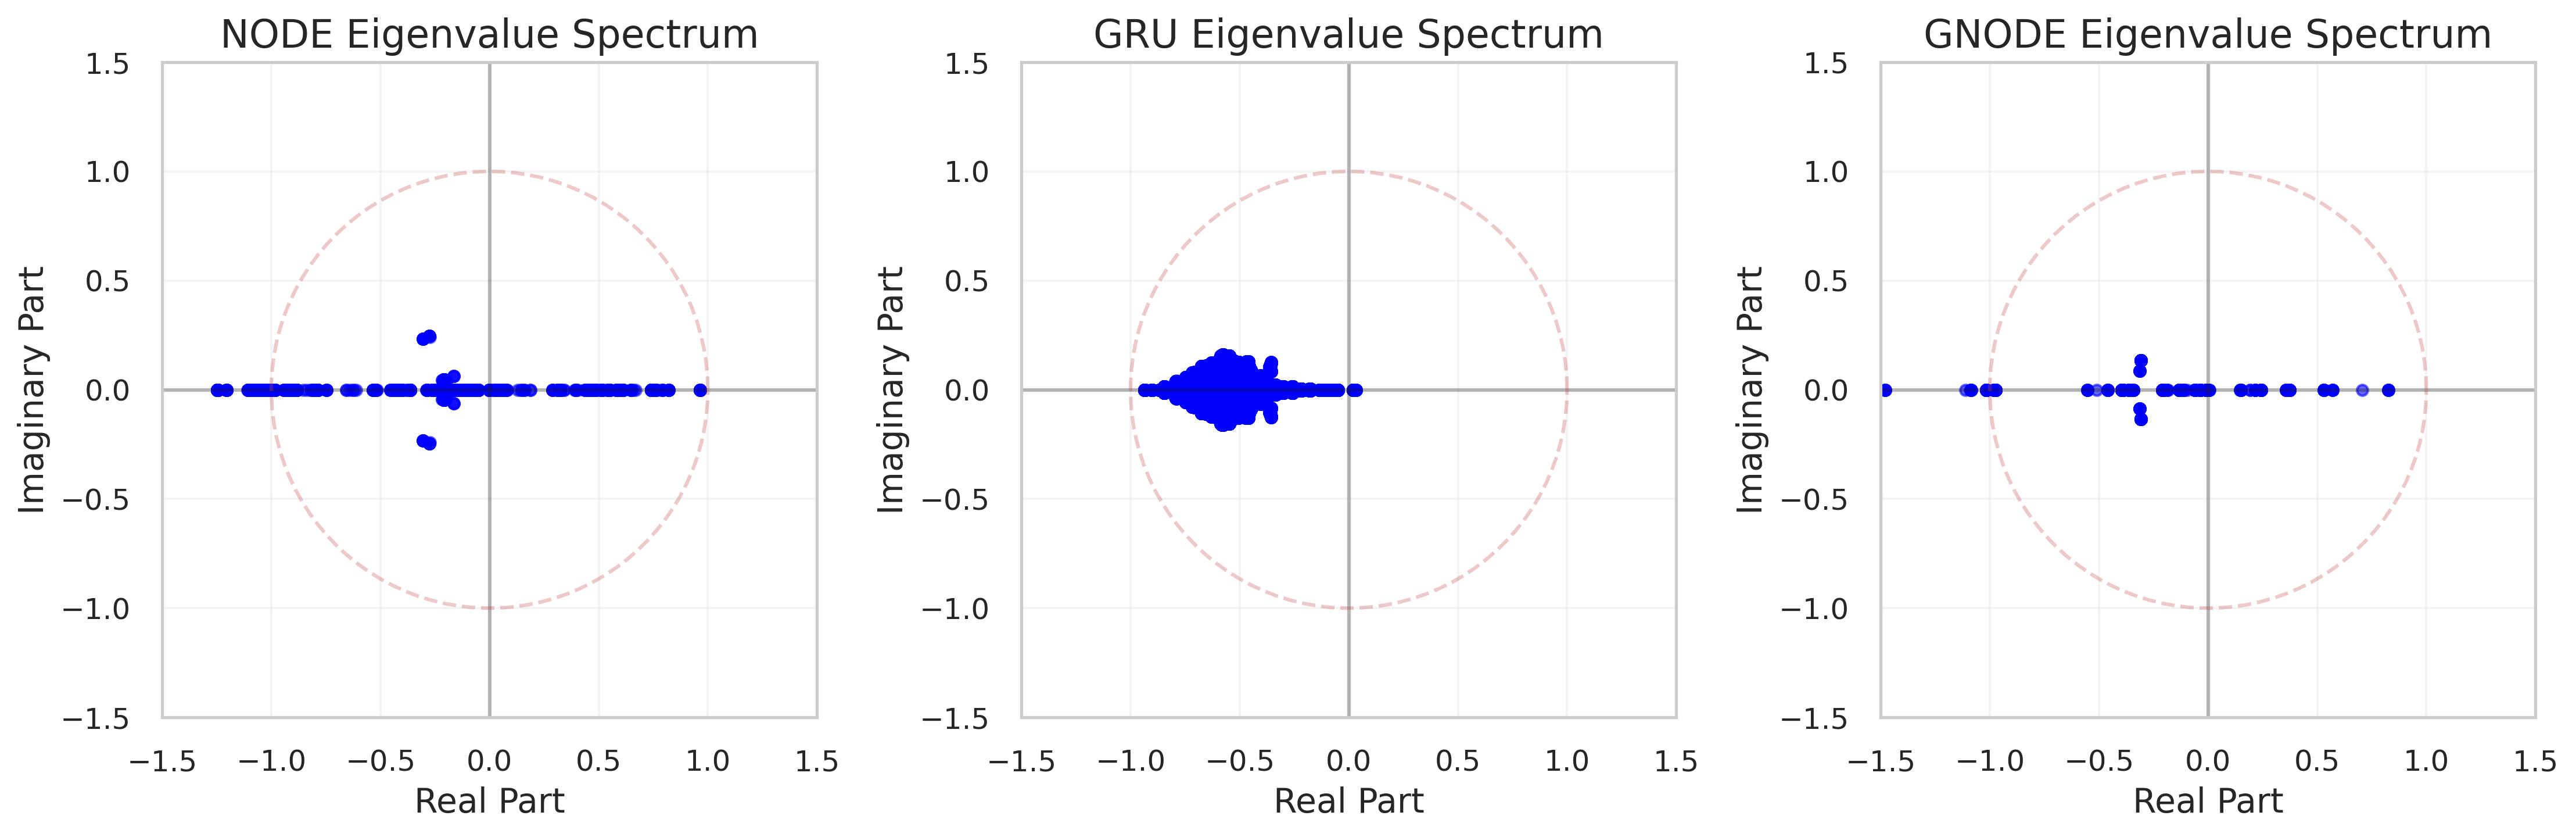

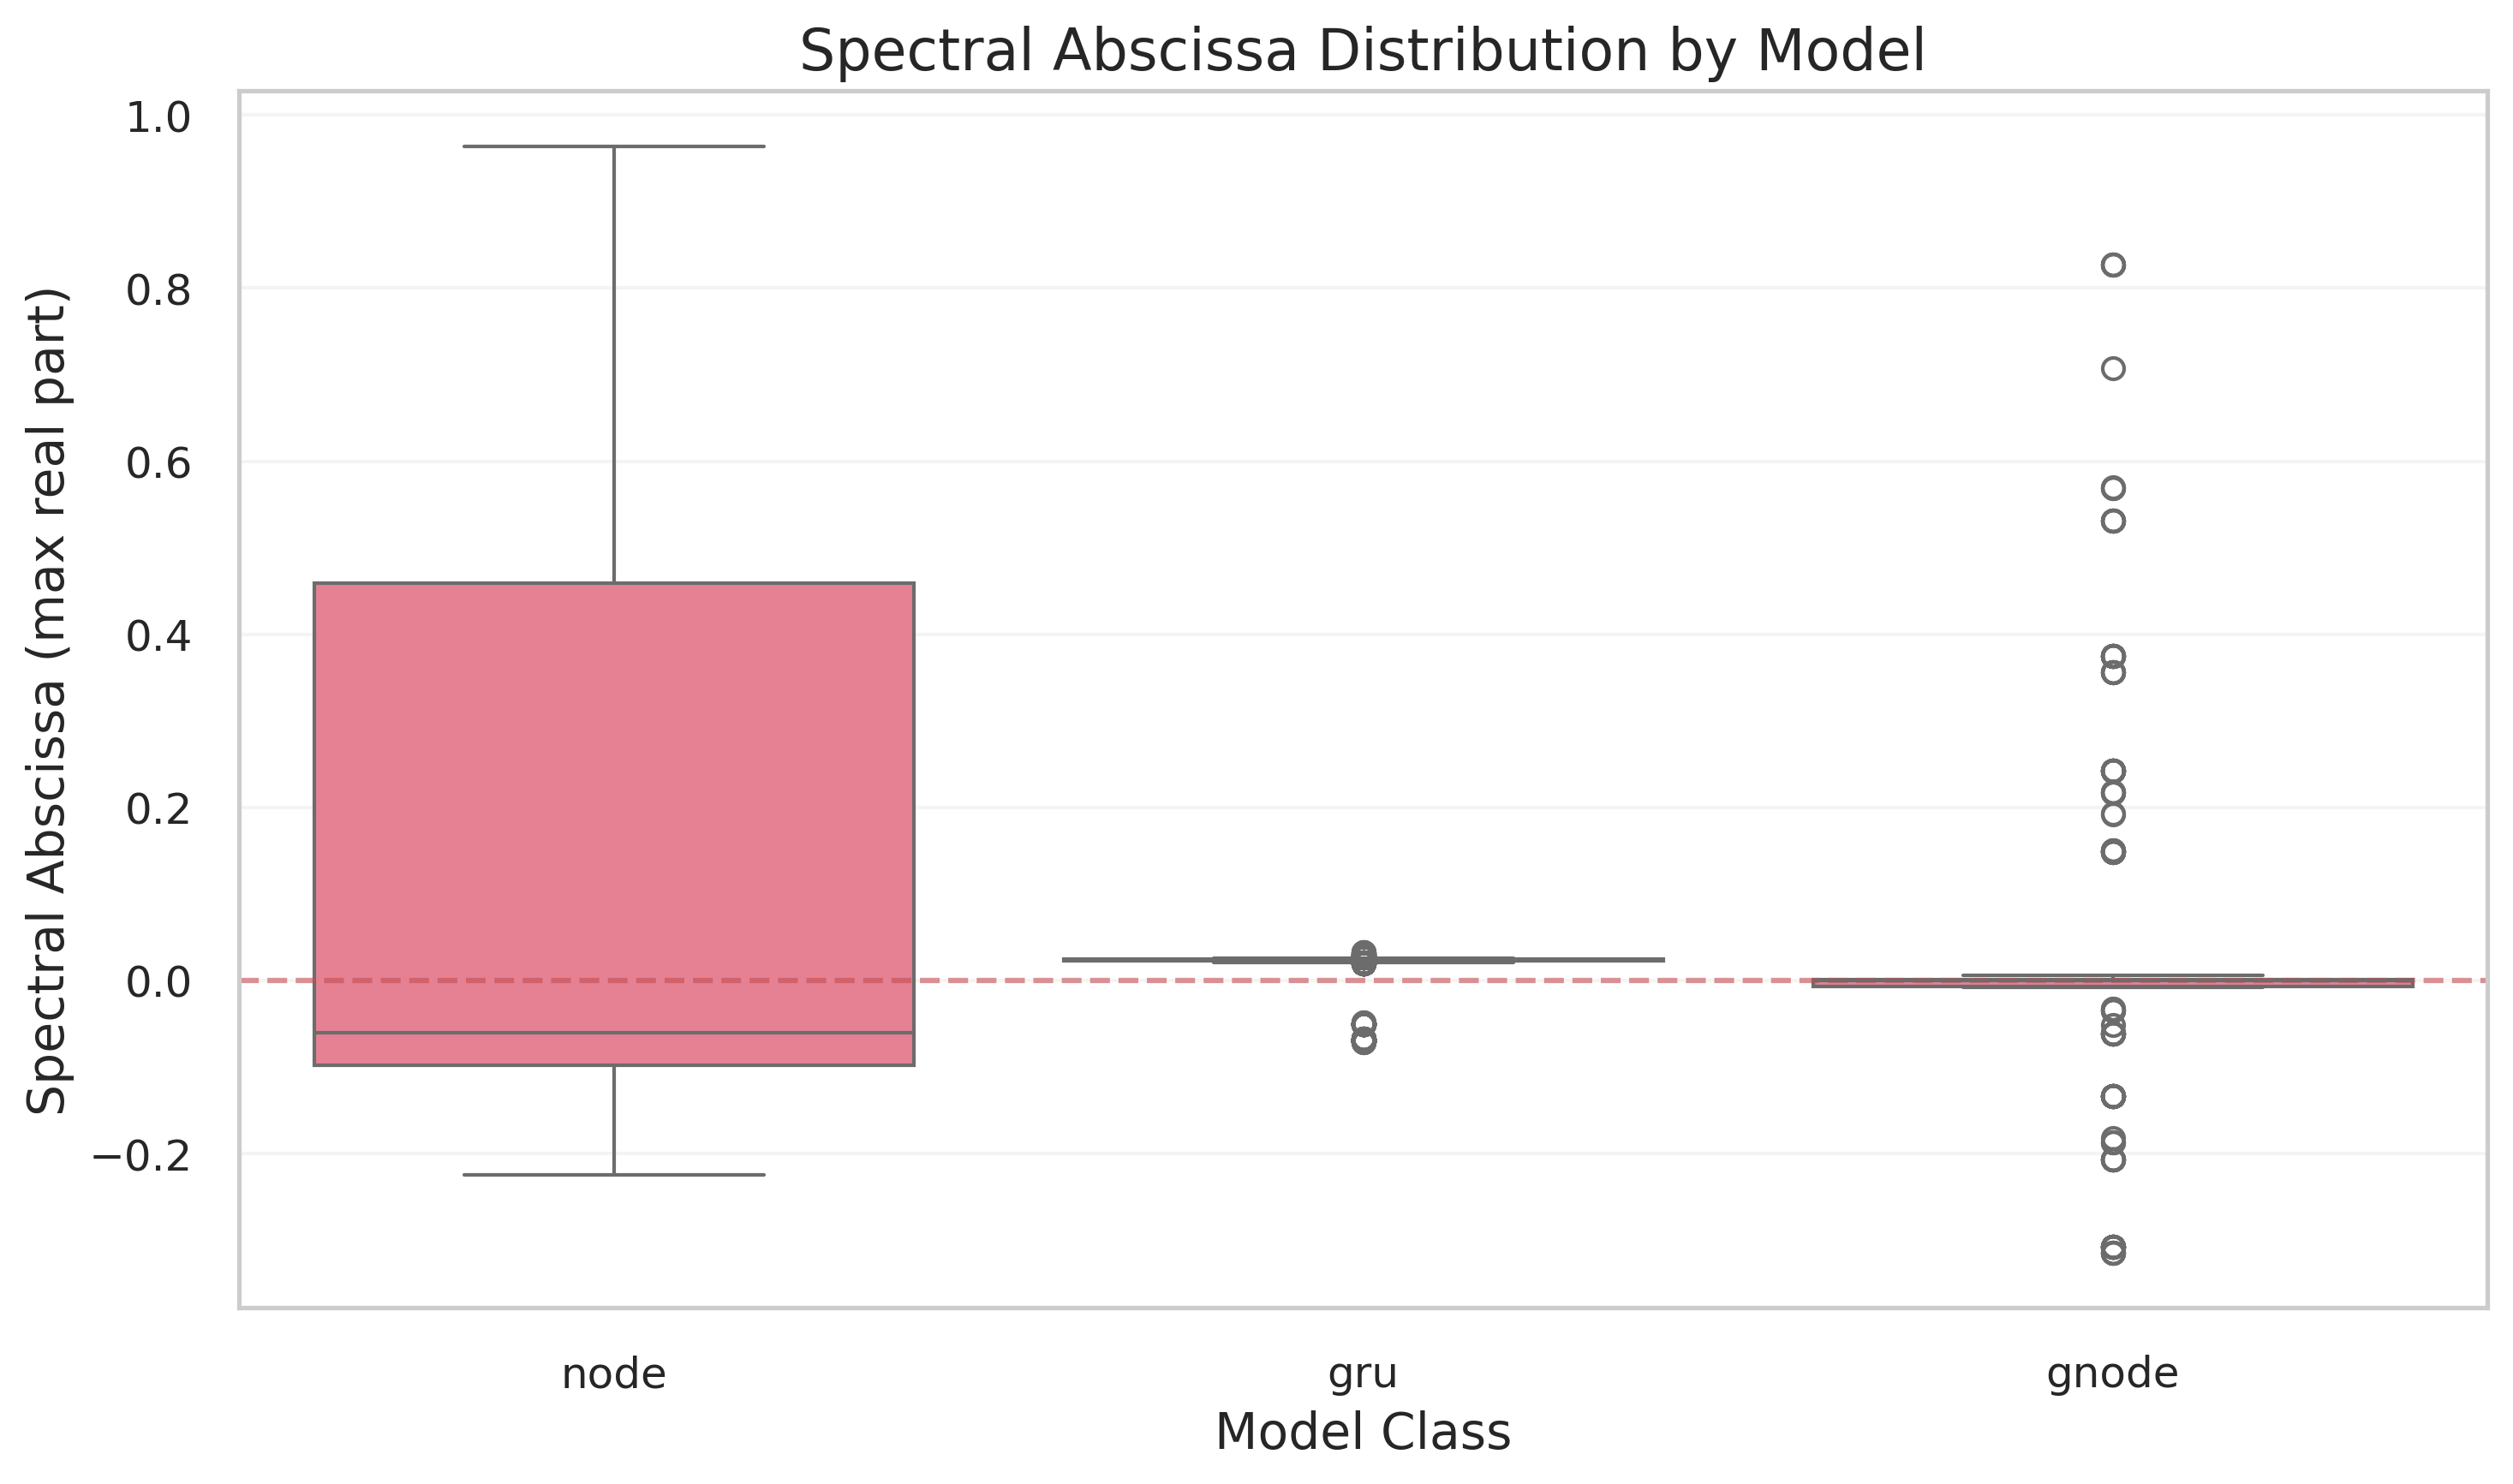

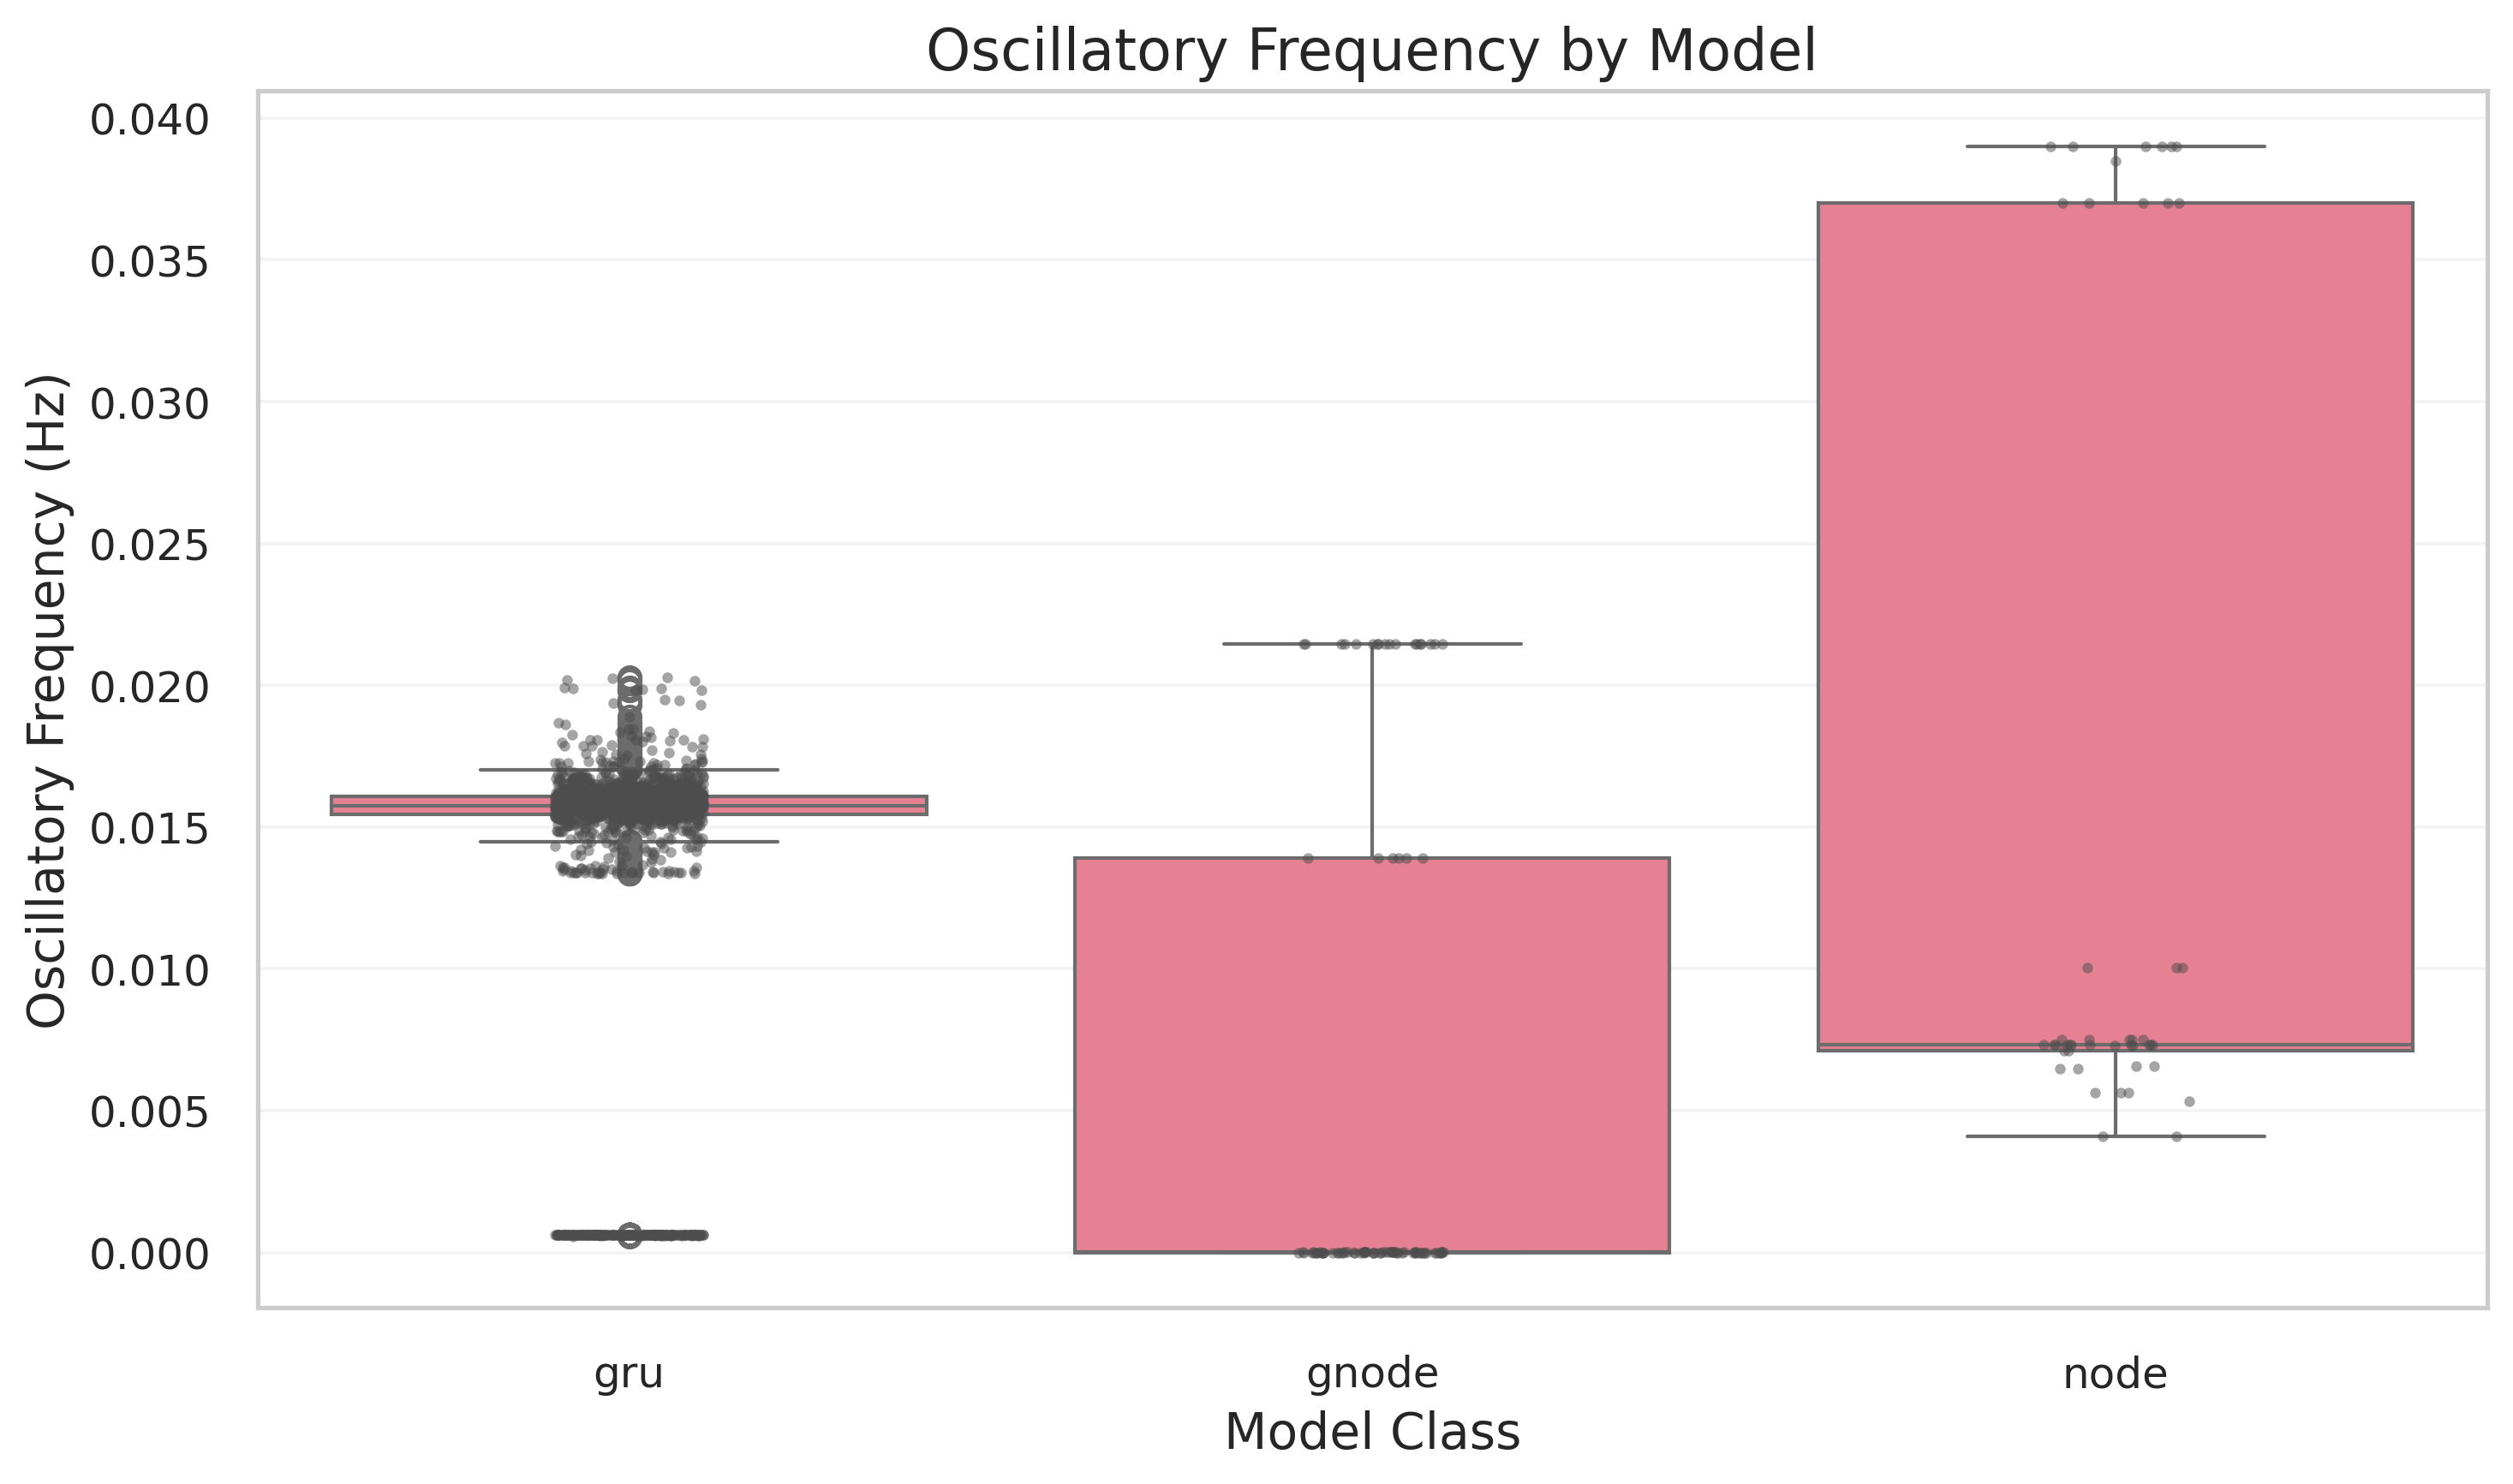

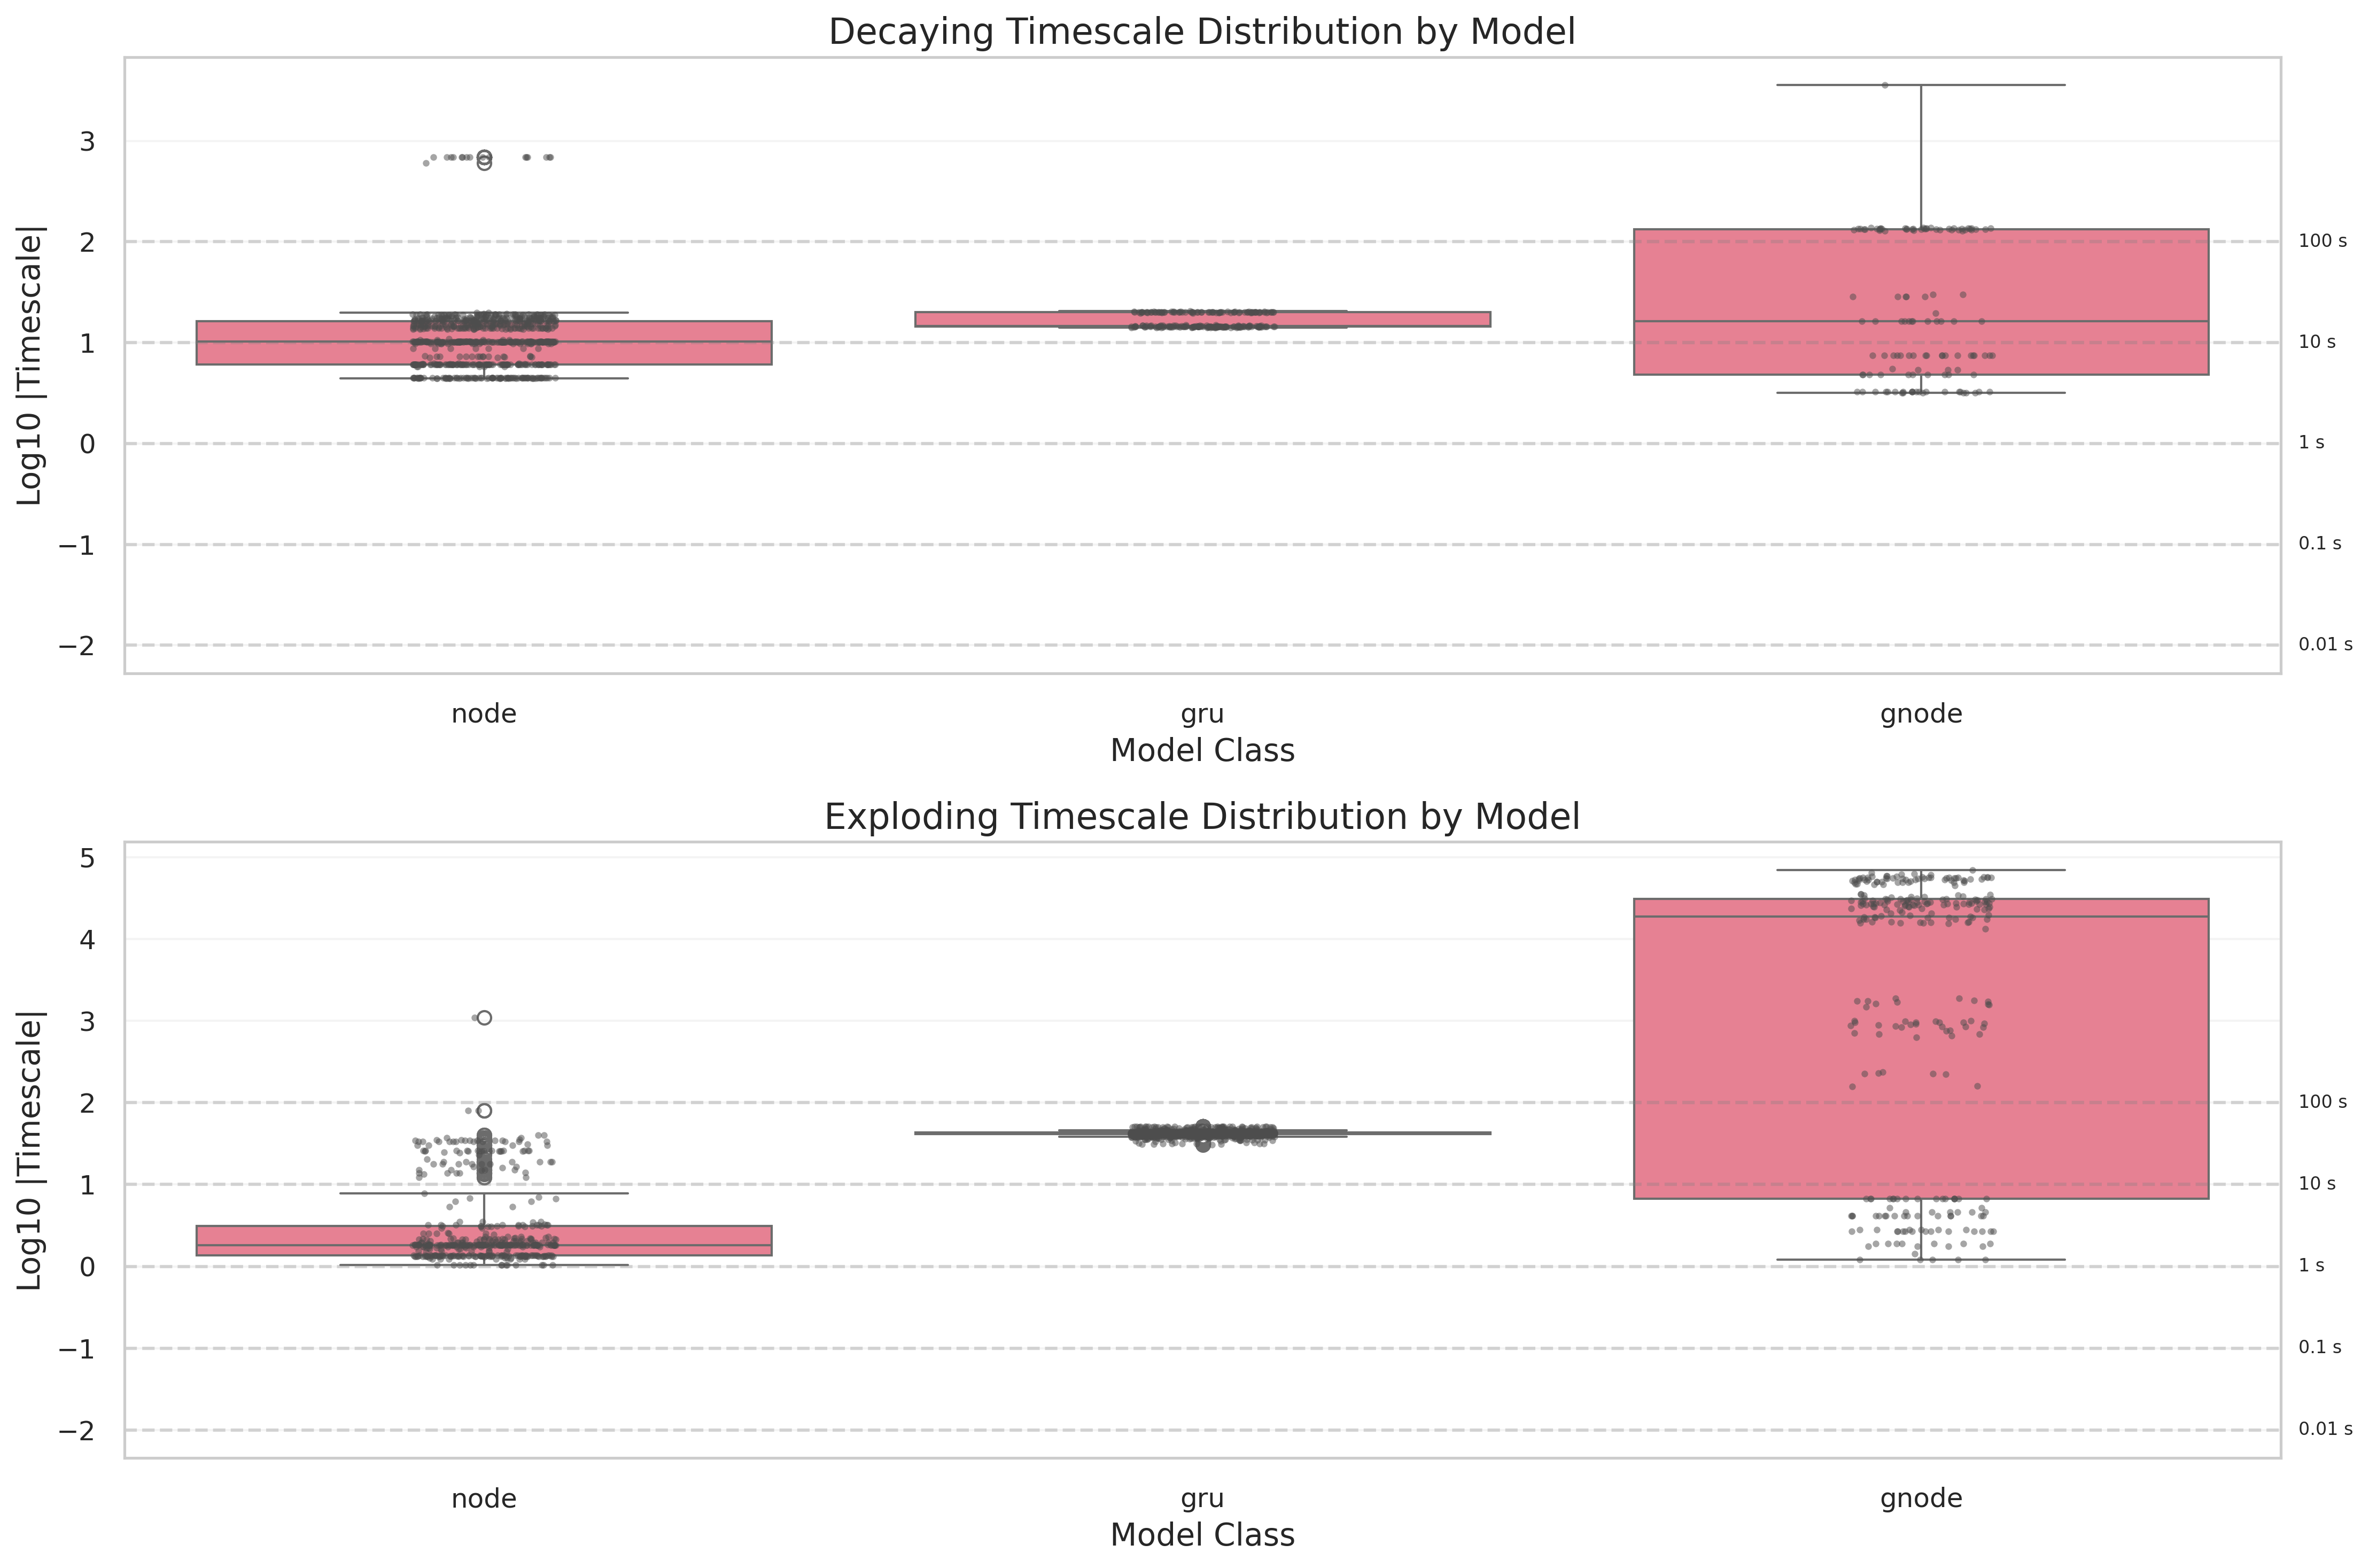

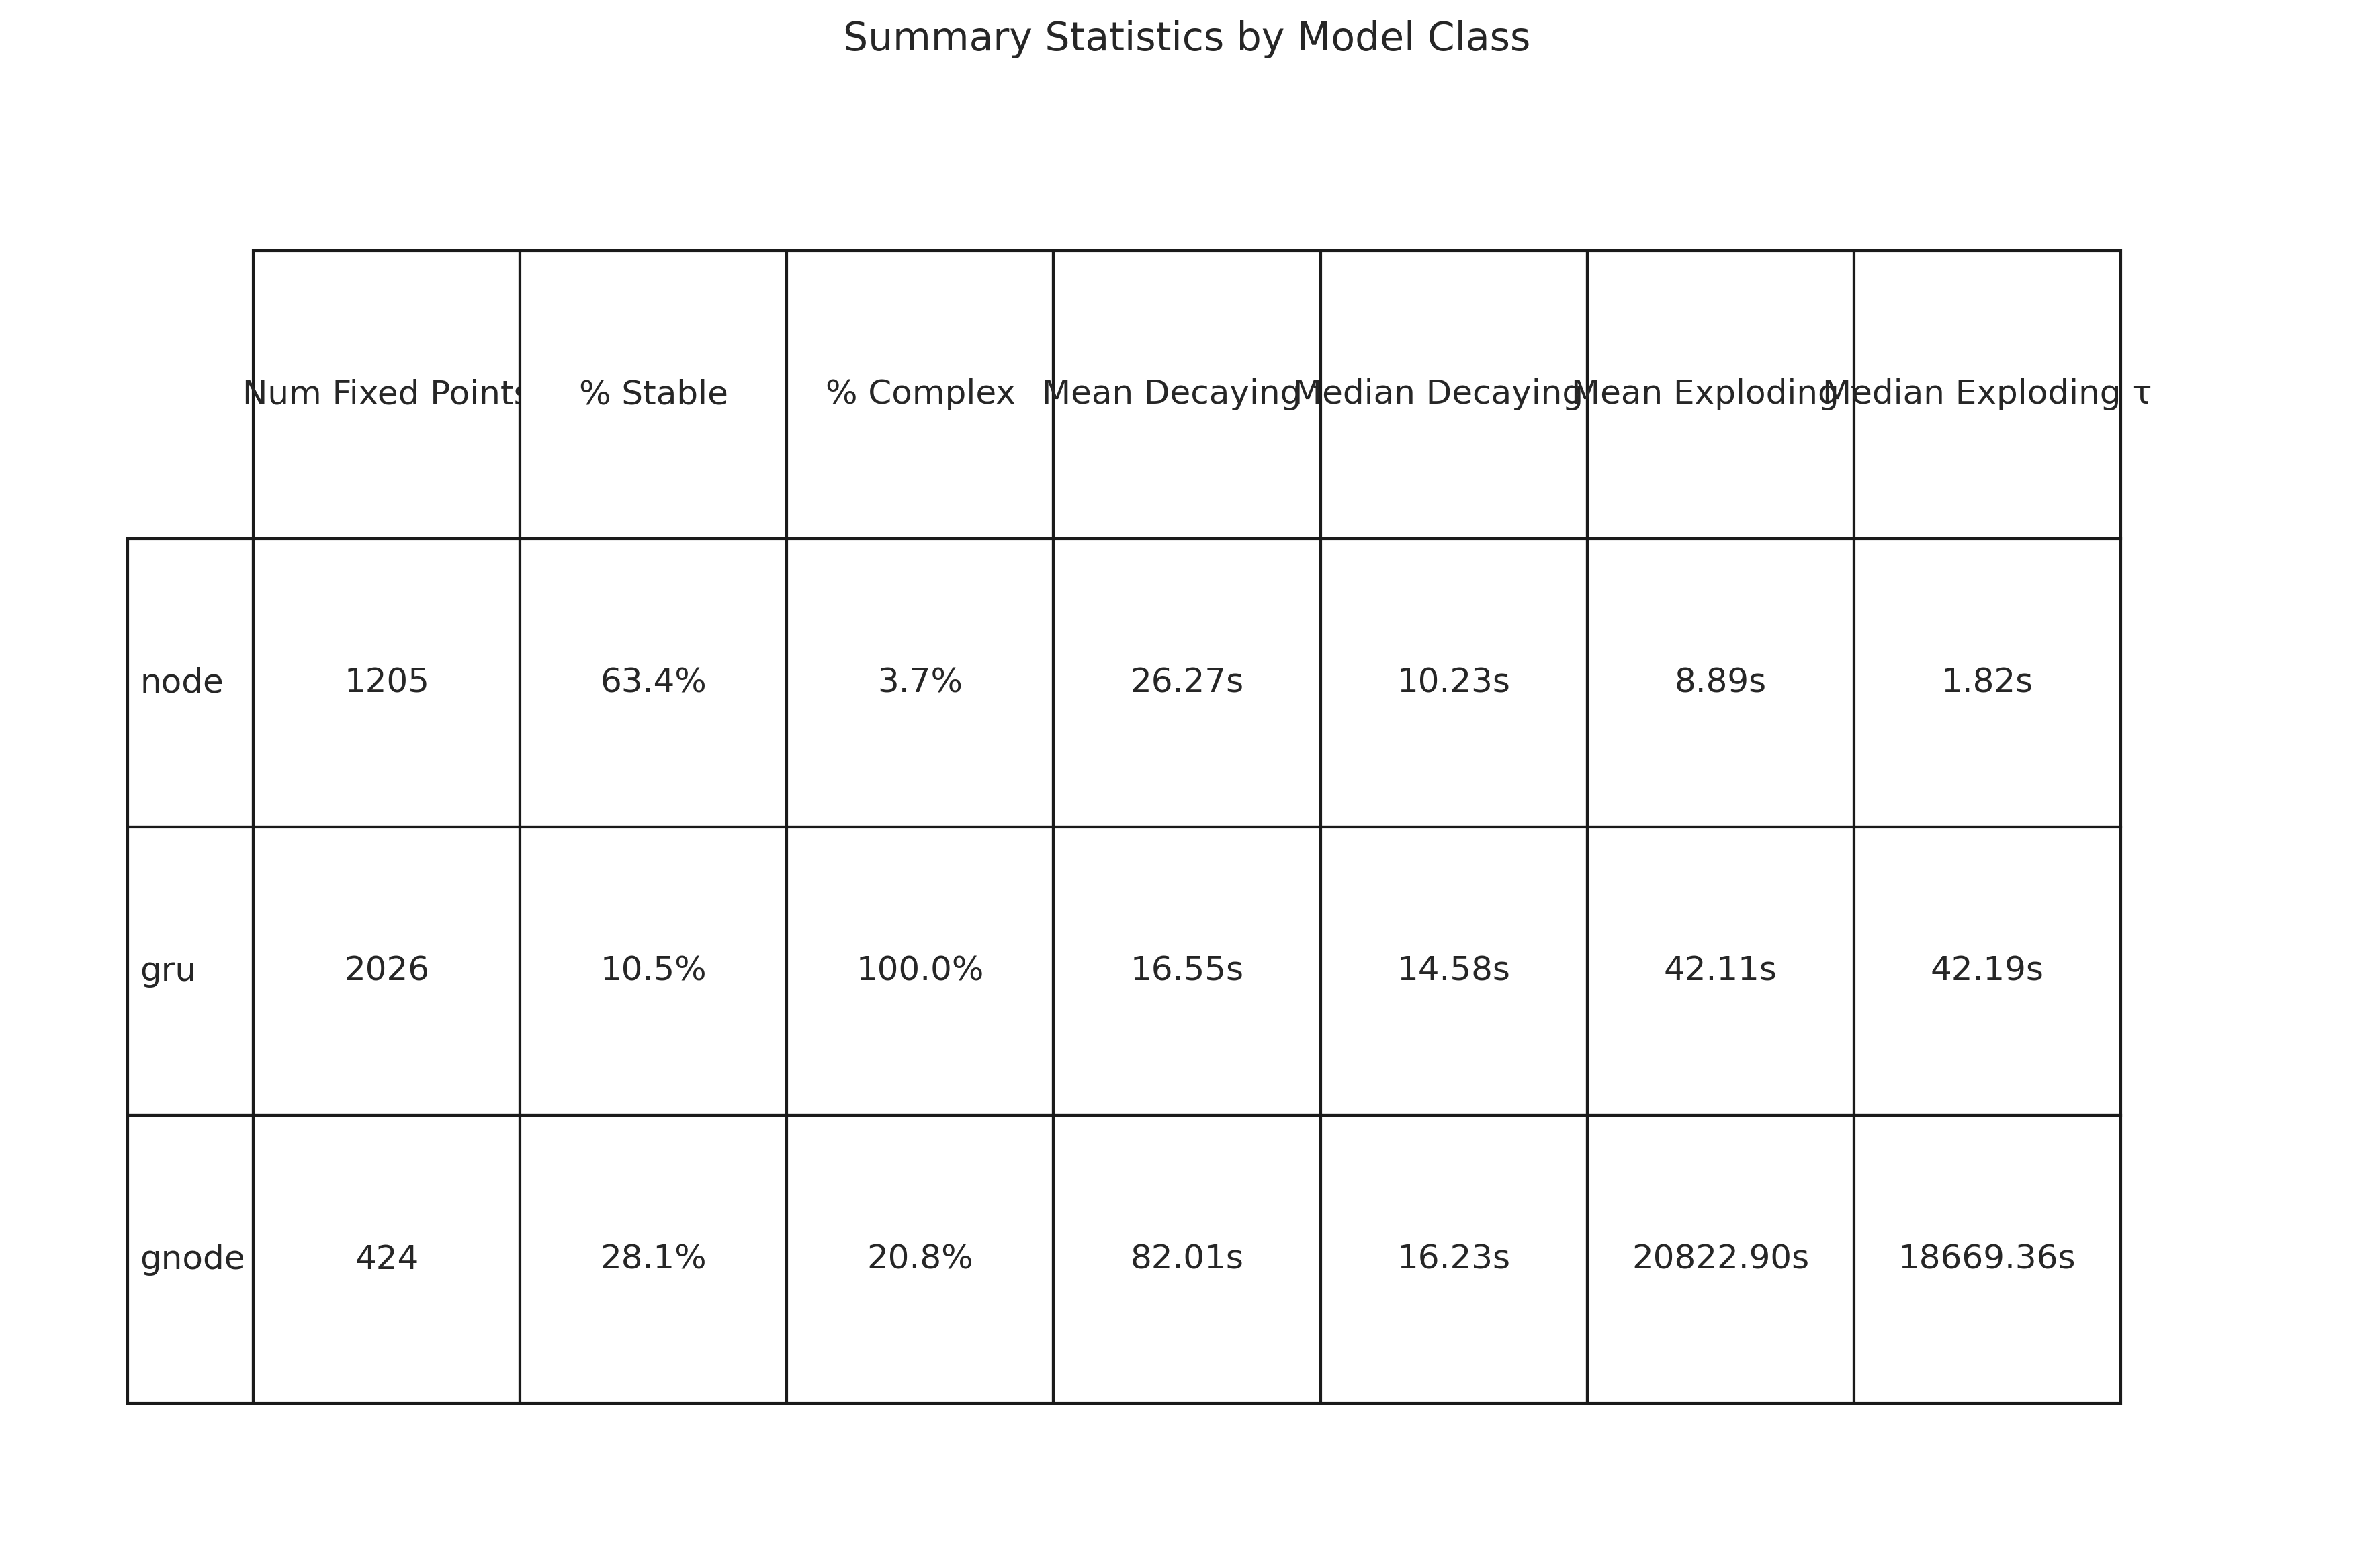

Analysis complete!

Summary Statistics by Model Class:

Model Class: NODE
  Number of Fixed Points: 1205
  Percent Stable: 63.4%
  Percent with Complex Eigenvalues: 3.7%
  Mean Decaying Timescale: 26.27s
  Median Decaying Timescale: 10.23s
  Mean Exploding Timescale: 8.89s
  Median Exploding Timescale: 1.82s

Model Class: GRU
  Number of Fixed Points: 2026
  Percent Stable: 10.5%
  Percent with Complex Eigenvalues: 100.0%
  Mean Decaying Timescale: 16.55s
  Median Decaying Timescale: 14.58s
  Mean Exploding Timescale: 42.11s
  Median Exploding Timescale: 42.19s

Model Class: GNODE
  Number of Fixed Points: 424
  Percent Stable: 28.1%
  Percent with Complex Eigenvalues: 20.8%
  Mean Decaying Timescale: 82.01s
  Median Decaying Timescale: 16.23s
  Mean Exploding Timescale: 20822.90s
  Median Exploding Timescale: 18669.36s


In [63]:
save_dir = './stability_TT_full'

results = run_stability_analysis_refined(
    fps_list, filenames_list, delta_t_list, alpha_list,
    filter_box=((-4, 4), (-4, 4)),
    filter_code="000",
    q_threshold=1e-5,
    save_dir=save_dir
)

/tmp/ipykernel_3589138/1359118943.py:125: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_3589138/1359118943.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model_class', y=y_col, ax=ax, palette=MODEL_COLORS,
/tmp/ipykernel_3589138/1359118943.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model_class', y=y_col, ax=ax, palette=MODEL_COLORS,
/tmp/ipykernel_3589138/1359118943.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model_class', y=y_col, ax=ax, p

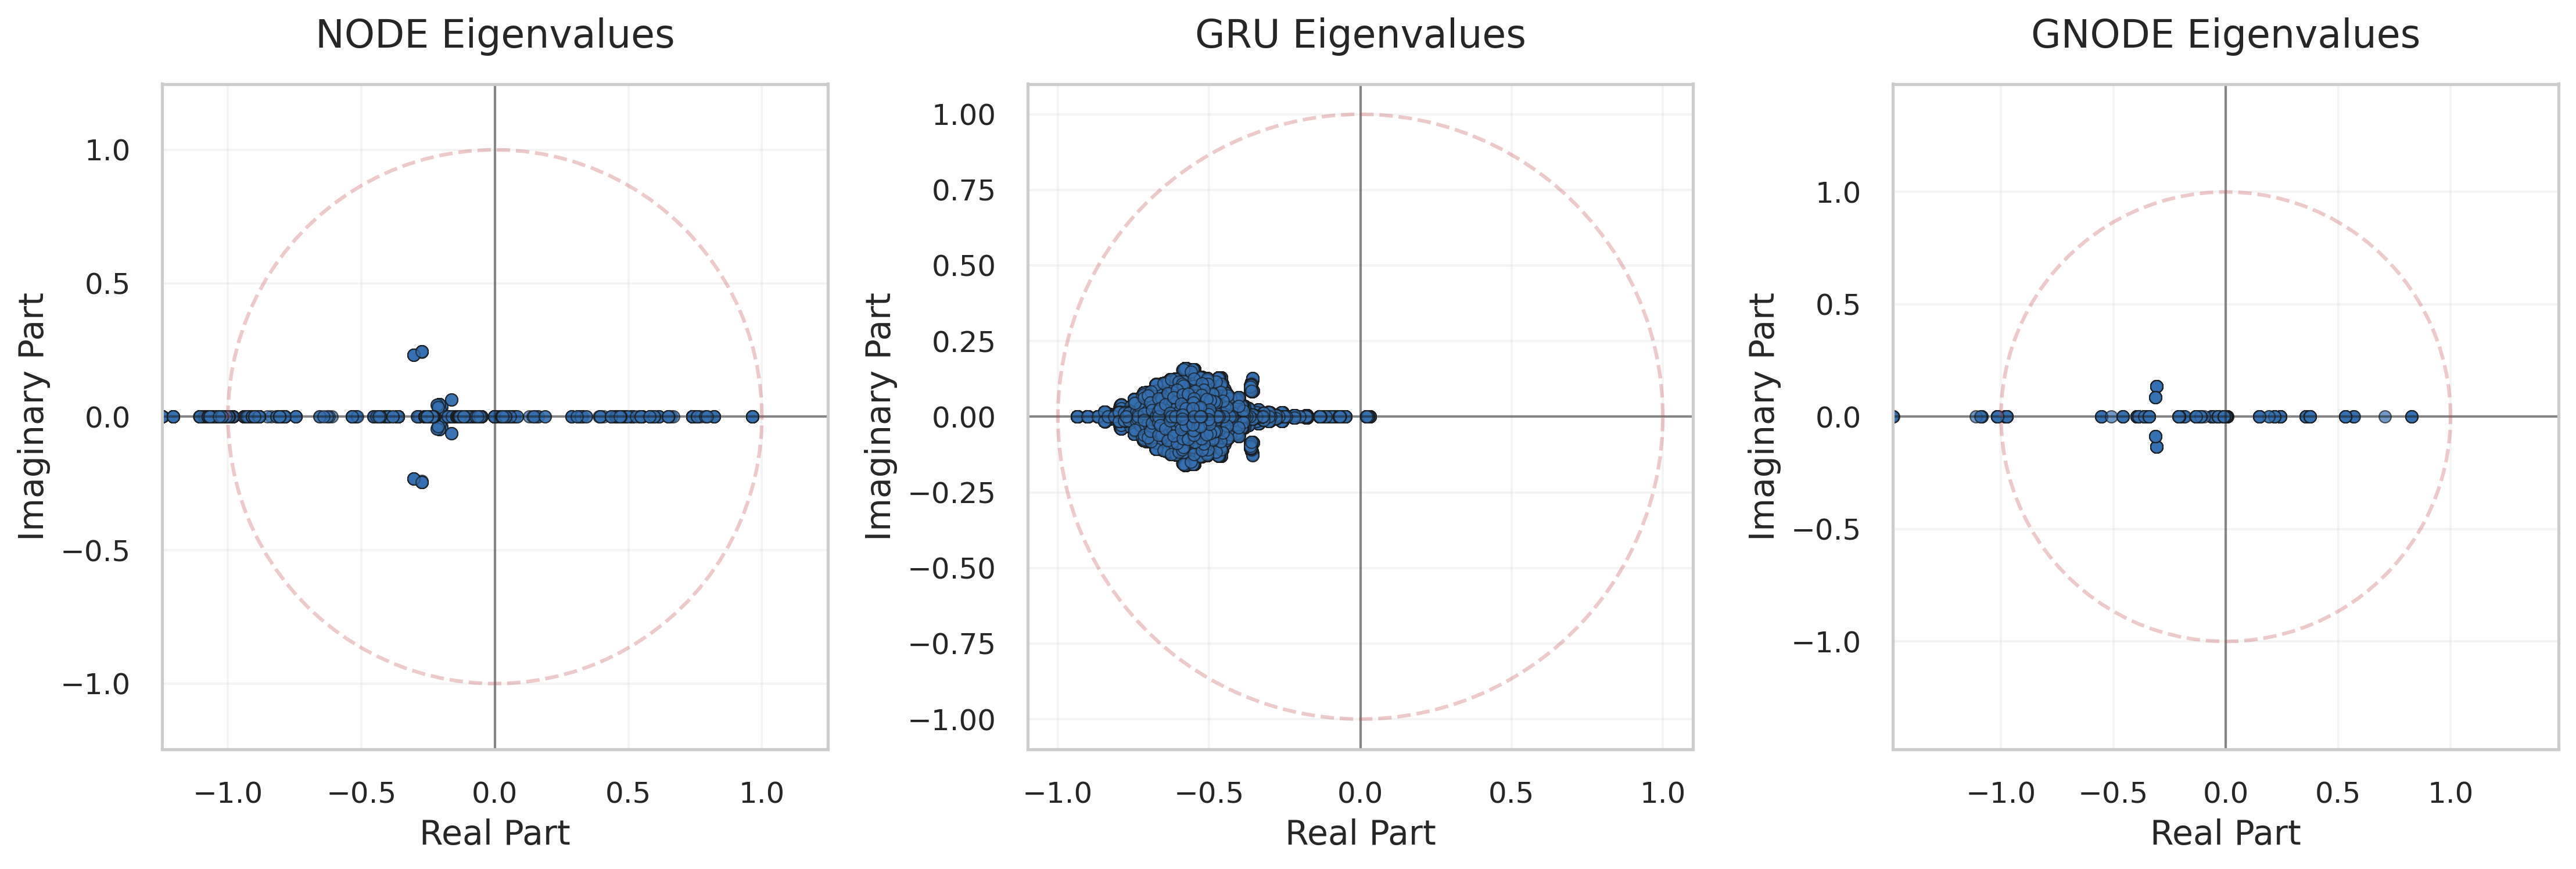

<Figure size 2400x1800 with 0 Axes>

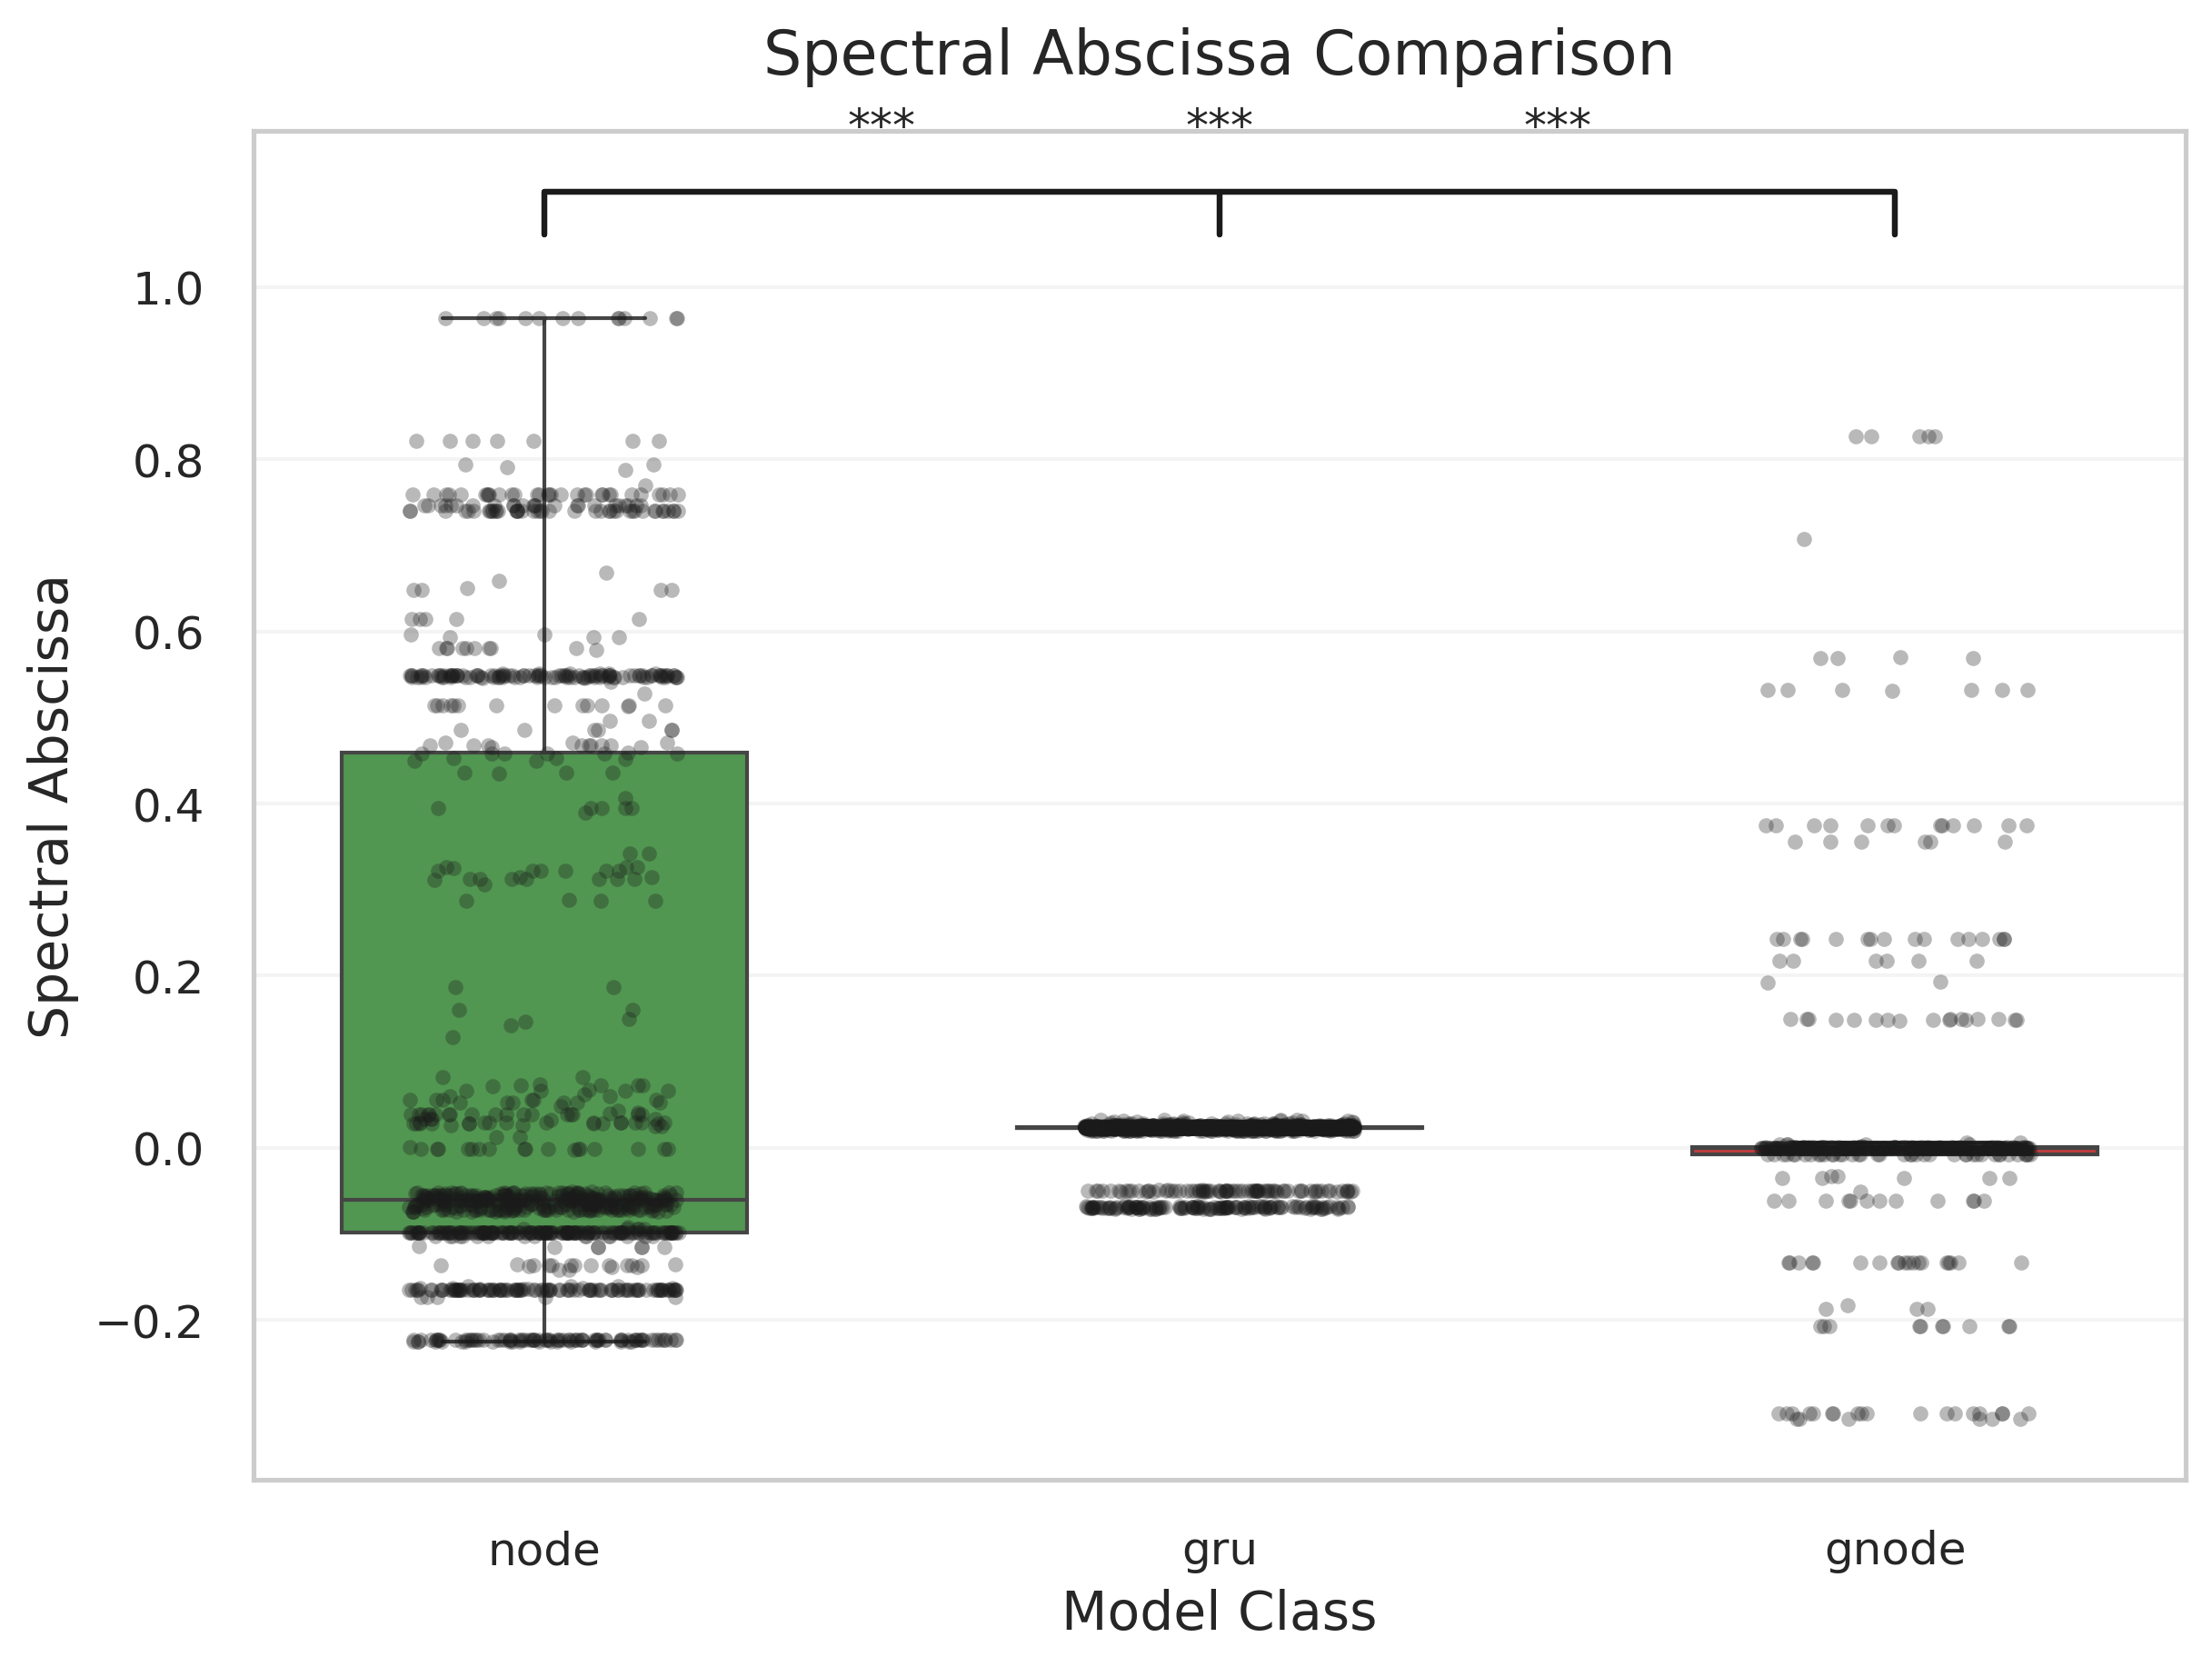

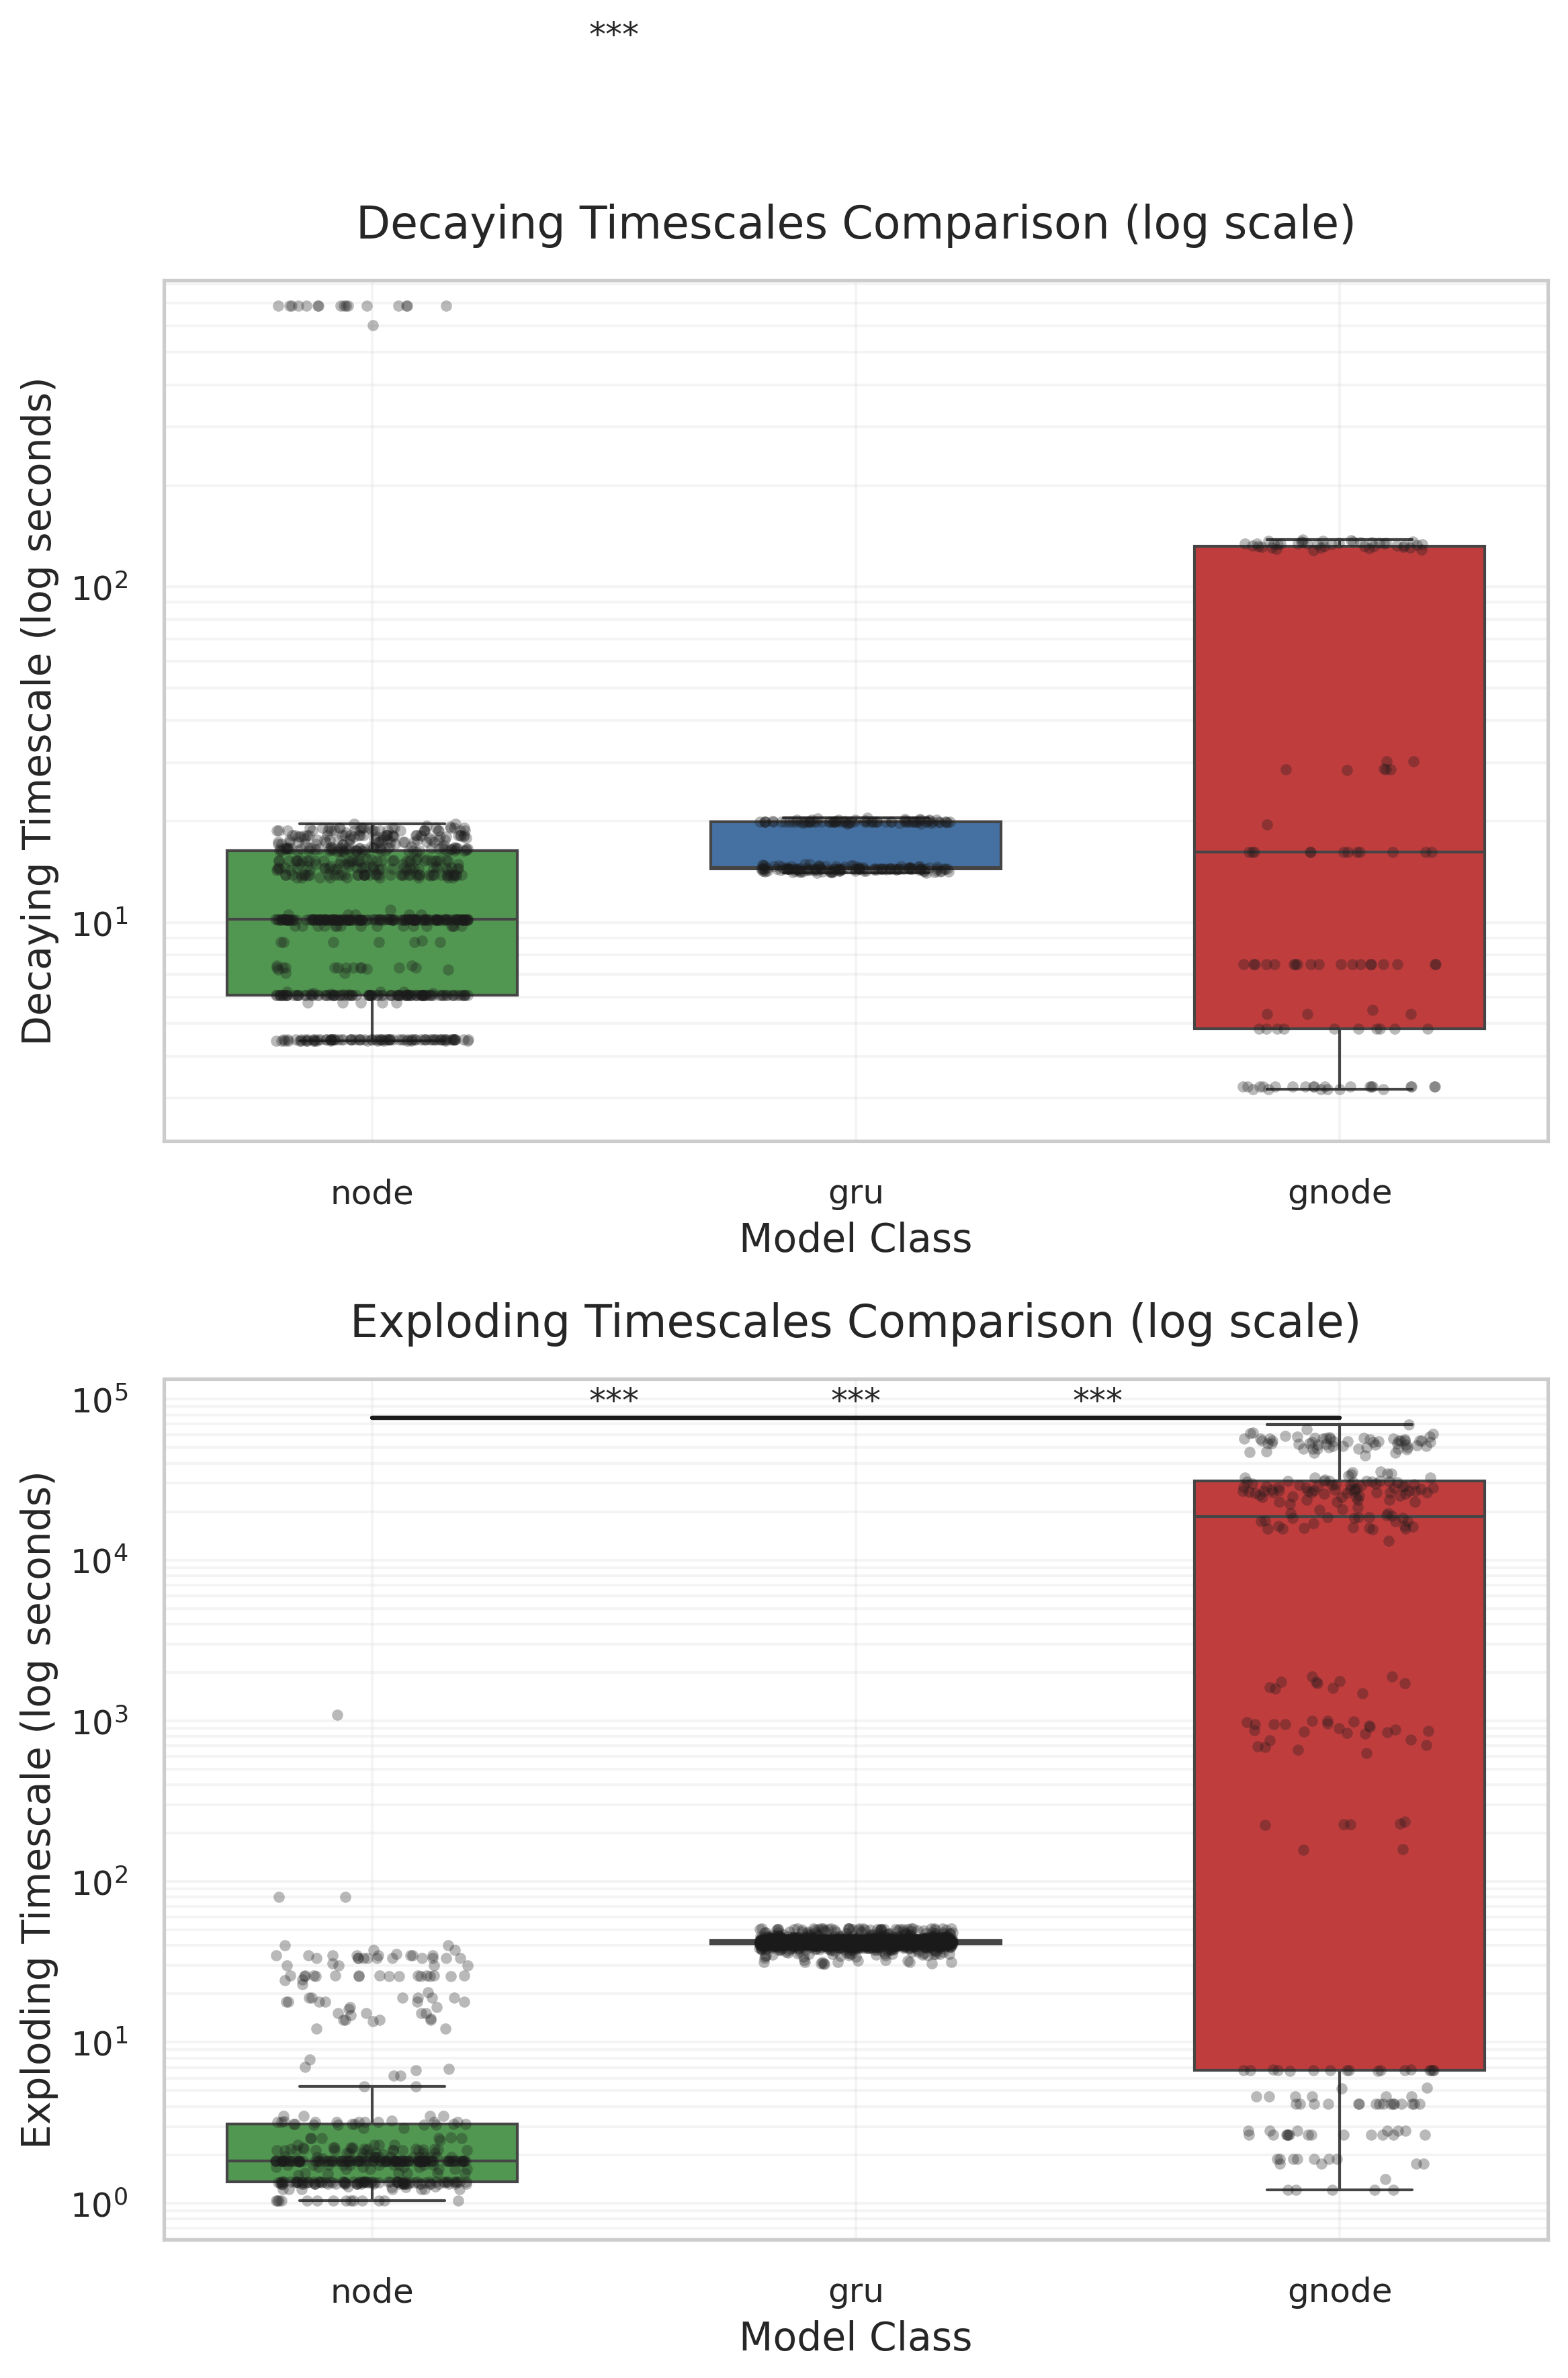

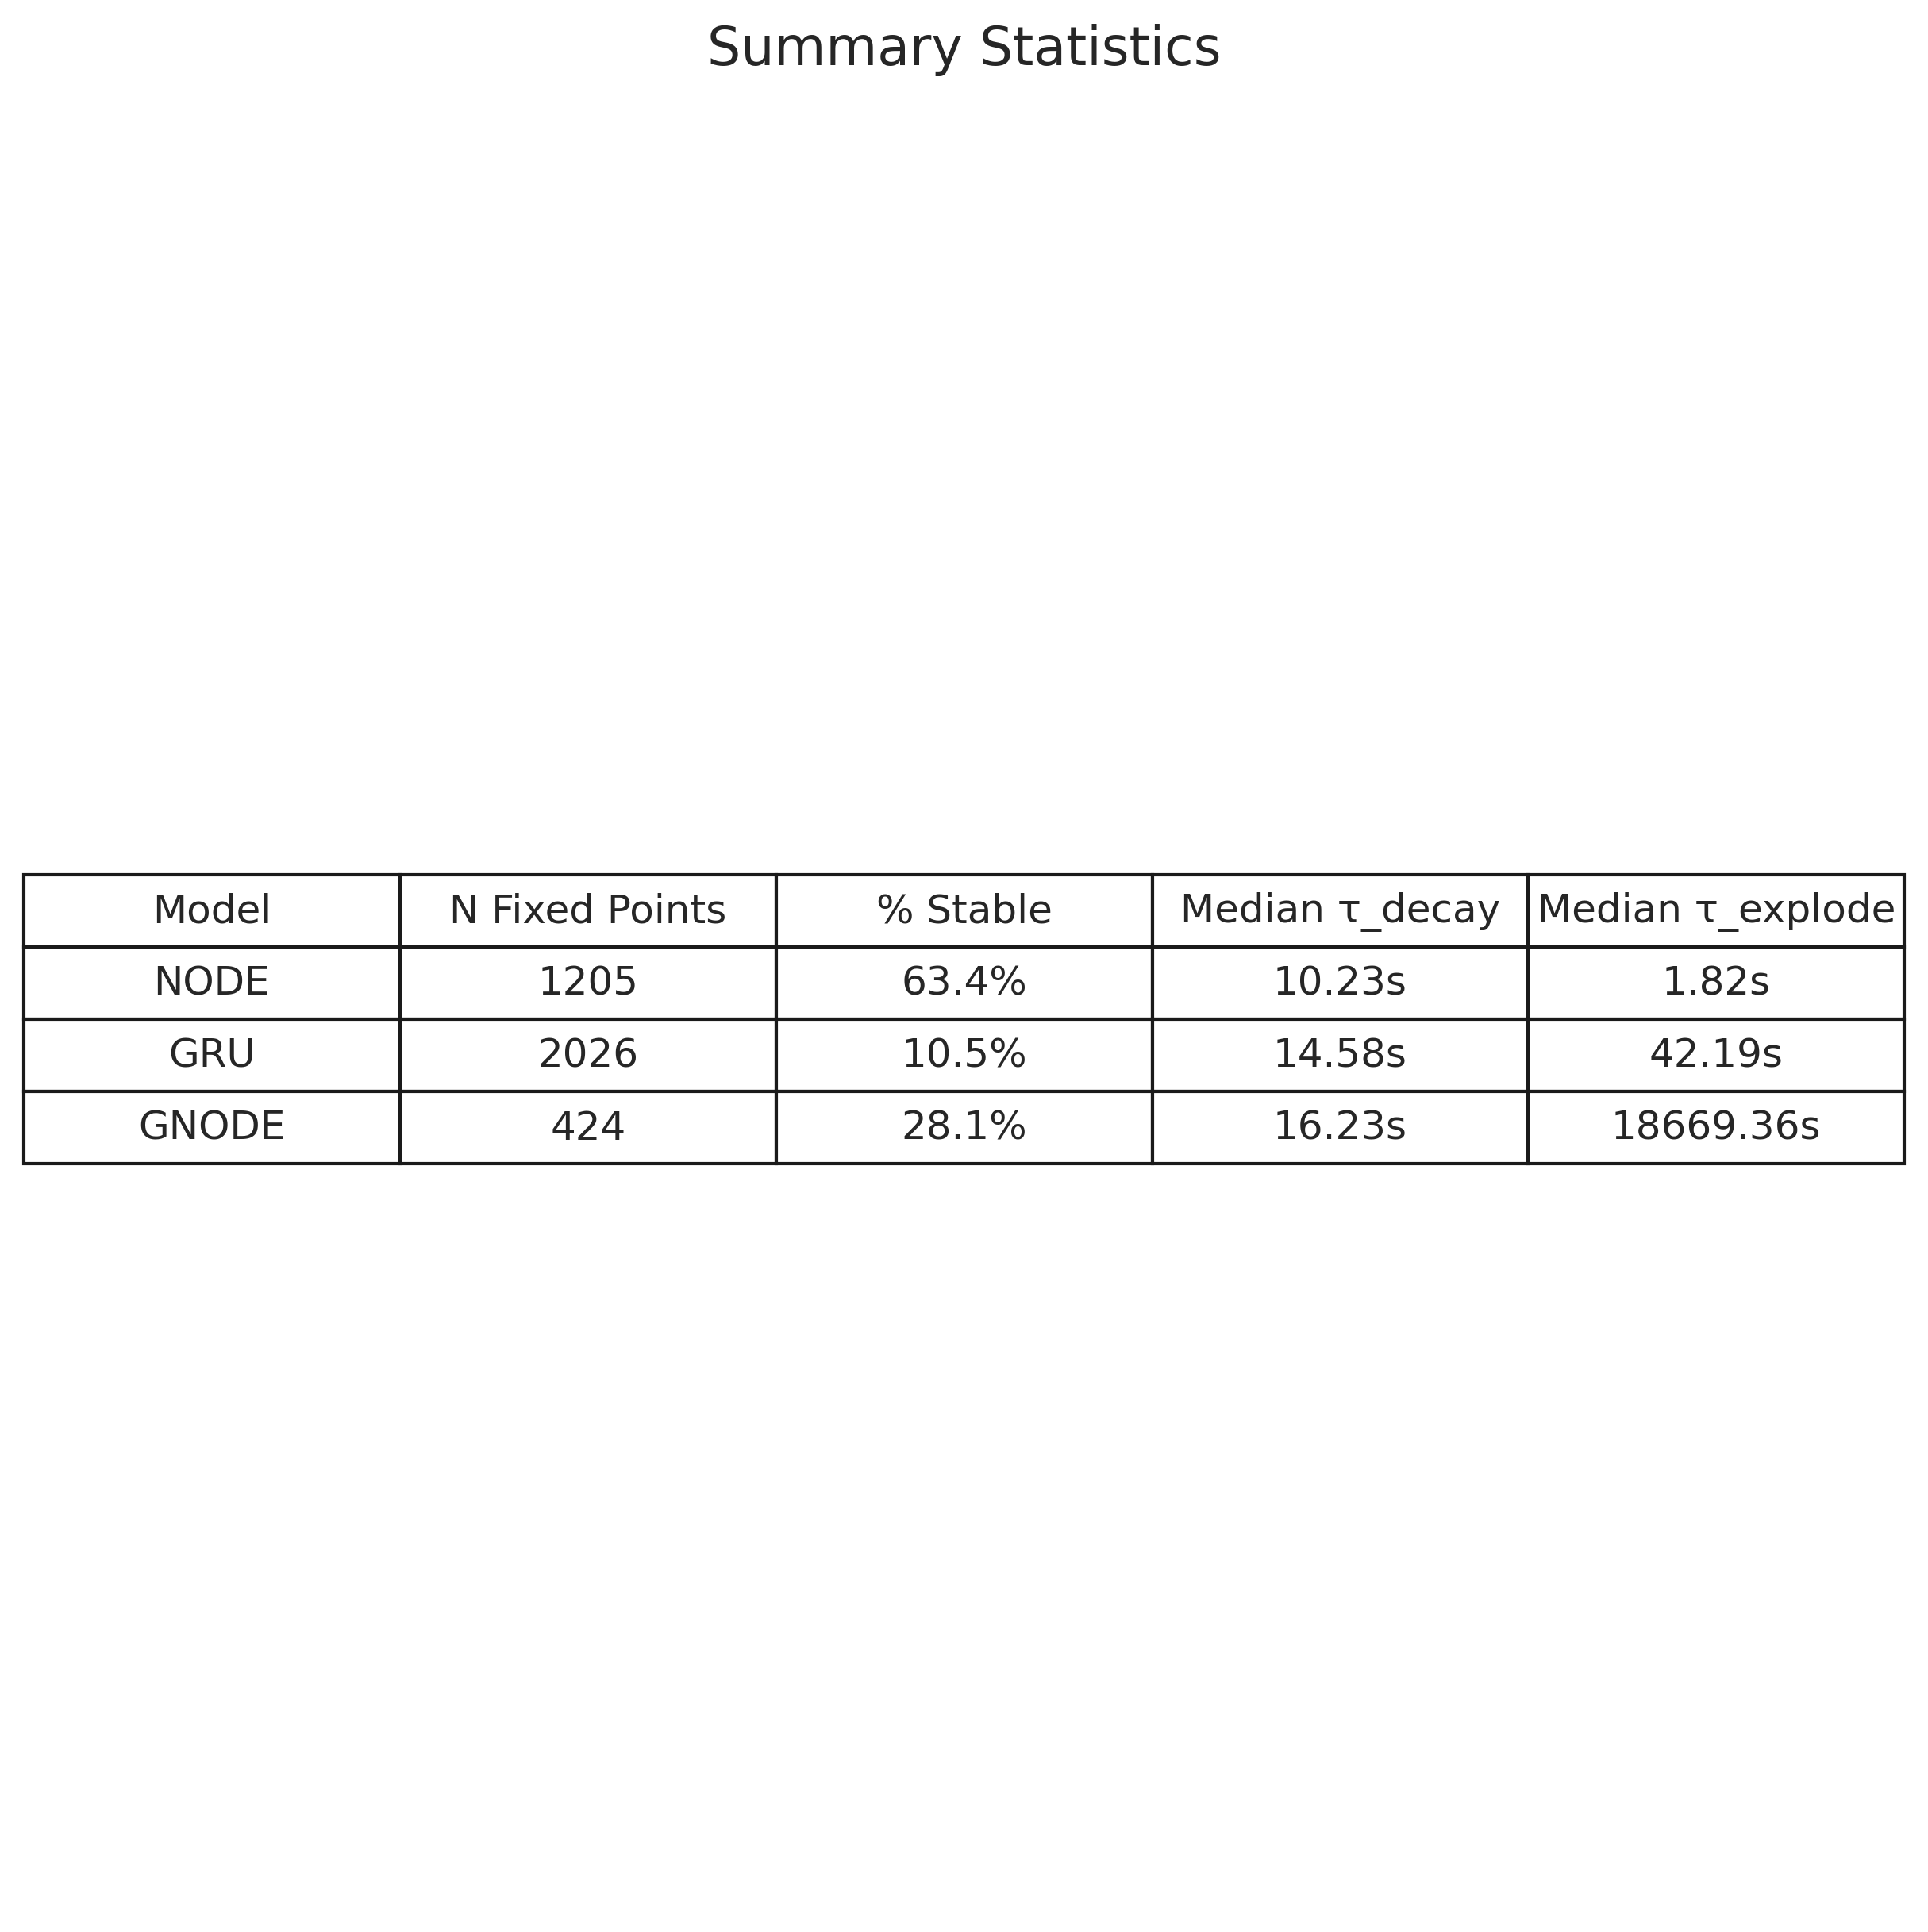

In [91]:
generate_visualizations_refined(results)

# Collecting all FP objects for DD models and store with hashes

# UPDATE: collecting 000 intrinsic fps for best and worst training models

In [2]:
import os
def find_file_with_string(root_dir, search_strings):
    out = {}
    for search_string in search_strings:
        for dirpath, dirnames, filenames in os.walk(root_dir):
            for dirname in dirnames:
                if search_string in dirname:
                    p = os.path.join(dirpath, dirname)
                    out[search_string] = p
    print("Found: ", len(out))
    print("Found all? ", len(out)==len(search_strings))
    return out  # if no such file is found

# not a problem if found more = exactly same params, expect similar behavior at least....

# root_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks"

# #gnode, node
# good = ['e0ed99f9', '0393f9dd', 'bc117a87', '17674d60','c41cfd0f','6fabb7c5','8f69cfdc','0cc3384a','fbf8412f','19f3a445']
# good_paths = find_file_with_string(root_dir, good)

# #gnode, node
# invented = ['4ec1fc58','1df312c6','f492a5f4','a9c6abc0','f741e874','64358cd7']
# invented_paths = find_file_with_string(root_dir, invented)

# # fr, gru - this is plot trial lats
# underfit = ['c631a64c','945575ce','b67d9926','3f93dbf0']
# underfit_paths = find_file_with_string(root_dir, underfit)

DD_collect_from_path(good_paths)

Found:  10
Found all?  True
Found:  6
Found all?  True
Found:  4
Found all?  True


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


e0ed99f9


/home/ad2002/ComputationThruDynamicsBenchmark/ctd/comparison/fixedpoints.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_trajs = torch.tensor(state_trajs, device=device, dtype=torch.float32)
/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Optimizing from 6168 initial points in 3 batches

Iteration 500/10000
Mean q = 4.56E-01
Mean dq = 9.60E-04
Best q = 4.17E-03
Temperature = 9.50E-01

Iteration 1000/10000
Mean q = 6.28E-01
Mean dq = 1.09E-03
Best q = 4.17E-03
Temperature = 9.00E-01

Iteration 1500/10000
Mean q = 6.53E-01
Mean dq = 1.05E-03
Best q = 4.17E-03
Temperature = 8.50E-01

Iteration 2000/10000
Mean q = 7.24E-01
Mean dq = 1.07E-03
Best q = 4.17E-03
Temperature = 8.00E-01

Iteration 2500/10000
Mean q = 6.66E-01
Mean dq = 9.33E-04
Best q = 4.17E-03
Temperature = 7.50E-01

Iteration 3000/10000
Mean q = 6.71E-01
Mean dq = 8.95E-04
Best q = 4.17E-03
Temperature = 7.00E-01

Iteration 3500/10000
Mean q = 5.69E-01
Mean dq = 7.66E-04
Best q = 4.17E-03
Temperature = 6.50E-01

Iteration 4000/10000
Mean q = 5.47E-01
Mean dq = 6.90E-04
Best q = 4.17E-03
Temperature = 6.00E-01

Iteration 4500/10000
Mean q = 4.60E-01
Mean dq = 5.82E-04
Best q = 4.17E-03
Temperature = 5.50E-01

Iteration 5000/10000
Mean q = 4.21E-01
Mean dq = 5.


Iteration 8500/10000
Mean q = 2.15E-03
Mean dq = 2.53E-06
Best q = 1.14E-13
Temperature = 1.50E-01

Iteration 9000/10000
Mean q = 1.70E-03
Mean dq = 1.22E-06
Best q = 1.14E-13
Temperature = 1.00E-01

Iteration 9500/10000
Mean q = 2.59E-04
Mean dq = 2.25E-07
Best q = 1.14E-13
Temperature = 5.00E-02

Iteration 10000/10000
Mean q = 2.00E-04
Mean dq = 1.24E-07
Best q = 1.14E-13
Temperature = 5.00E-02
Found 3575 unique fixed points.
Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.
c41cfd0f
Optimizing from 6168 initial points in 3 batches

Iteration 500/10000
Mean q = 5.85E-01
Mean dq = 7.60E-04
Best q = 1.14E-06
Temperature = 9.50E-01

Iteration 1000/10000
Mean q = 6.78E-01
Mean dq = 8.30E-04
Best q = 1.14E-06
Temperature = 9.00E-01

Iteration 1500/10000
Mean q = 6.27E-01
Mean dq = 8.19E-04
Best q = 1.14E-06
Temperature = 8.50E-01

Iteration 2000/10000
Mean q = 6.60E-01
Mean dq = 8.24E-04
Best q = 1.14E-06
Temperature = 8.00E-01

Iteration 2500/10000
Mean q = 5.89E


Iteration 5500/10000
Mean q = 2.49E-01
Mean dq = 3.29E-04
Best q = 0.00E+00
Temperature = 4.50E-01

Iteration 6000/10000
Mean q = 2.26E-01
Mean dq = 2.96E-04
Best q = 0.00E+00
Temperature = 4.00E-01

Iteration 6500/10000
Mean q = 1.71E-01
Mean dq = 2.36E-04
Best q = 0.00E+00
Temperature = 3.50E-01

Iteration 7000/10000
Mean q = 1.45E-01
Mean dq = 1.90E-04
Best q = 0.00E+00
Temperature = 3.00E-01

Iteration 7500/10000
Mean q = 9.95E-02
Mean dq = 1.37E-04
Best q = 0.00E+00
Temperature = 2.50E-01

Iteration 8000/10000
Mean q = 8.32E-02
Mean dq = 9.77E-05
Best q = 0.00E+00
Temperature = 2.00E-01

Iteration 8500/10000
Mean q = 5.53E-02
Mean dq = 5.79E-05
Best q = 0.00E+00
Temperature = 1.50E-01

Iteration 9000/10000
Mean q = 4.66E-02
Mean dq = 3.08E-05
Best q = 0.00E+00
Temperature = 1.00E-01

Iteration 9500/10000
Mean q = 3.36E-02
Mean dq = 1.35E-05
Best q = 0.00E+00
Temperature = 5.00E-02

Iteration 10000/10000
Mean q = 2.97E-02
Mean dq = 9.27E-06
Best q = 0.00E+00
Temperature = 5.00E-02

In [21]:
# Grouped hashname sets - SECND WITH THRESH ADJUSTED TO GNODES AND NODES BC WE ONLY TRUST THOSE
hashname_groups = {
    'gnode': {
        'inventing_features': {
            'high_rate_low_state': {
                'b8b48028', 'f492a5f4', '64358cd7', '5d4dfe4a', '9dc644f8',
                '02a69630', '1e9588f2', 'a9c6abc0', '4c2d6827', '2ac77f90',
                '7c029f3f', '5b5eed4c', '04e7df0e', '2decde61', 'f5bb38d1',
                '4ec1fc58', 'cd9a7f6e', '5affcbc0'
            },
            'high_co_low_cycle': {'7c029f3f', '4ec1fc58', '64358cd7', '9dc644f8'},
            'both': {'64358cd7', '7c029f3f', '4ec1fc58', '9dc644f8'}
        },
        'underfitting': {
            'low_rate_high_state': set(),
            'low_co_high_cycle': {'1f5ba8c6', '5c1ddcd4', '3ba4b0a9', '6496136e', '4c485089', 'f9b9eed0'},
            'both': set()
        },
        'top_performers': {
            'with_ground_truth': {'c41cfd0f', '6fabb7c5'},
            'without_ground_truth': {'0cc3384a', '8f69cfdc'}
        }
    },

    'gru': {
        'inventing_features': {
            'high_rate_low_state': set(),
            'high_co_low_cycle': {'1df312c6', 'f3c5e126'},
            'both': set()
        },
        'underfitting': {
            'low_rate_high_state': {'c631a64c', 'ff61b4da', '945575ce', '99e827ab'},
            'low_co_high_cycle': {
                'c631a64c', 'b67d9926', 'ff61b4da', '945575ce', '56f38c06', '812c1c42',
                '99e827ab', 'c16d6269', '668e9d89', 'f49d0127', '55fe4874', '01743df6',
                'c142fbce', 'e2ba8806', 'fff1781f', 'a058d181', '3f93dbf0', '2fe1636c'
            },
            'both': {'c631a64c', 'ff61b4da', '945575ce', '99e827ab'}
        },
        'top_performers': {
            'with_ground_truth': {'fbf8412f', '19f3a445'},
            'without_ground_truth': {'0393f9dd', 'e0ed99f9'}
        }
    },

    'node': {
        'inventing_features': {
            'high_rate_low_state': {
                'ec49fe76', 'a89d9062', '47849297', '0f85a8e3', '90ff7966', 'bf935b0b',
                'dc70cdf9', '558e9526', 'a6353ced', 'f3c6b011', '0d9116d3', 'e3cba591',
                'da23dded', '82843c5d', 'aaffb04f', '3d0639c4', 'f741e874'
            },
            'high_co_low_cycle': set(),
            'both': set()
        },
        'underfitting': {
            'low_rate_high_state': set(),
            'low_co_high_cycle': {
                'edd50266', 'a1397d01', 'ab098499', '5786594d', '4925fdf9', '8ae0abef',
                'e9d58413', 'd69306a4', 'ab17c719', '26784770'
            },
            'both': set()
        },
        'top_performers': {
            'with_ground_truth': {'bc117a87', '17674d60'},
            'without_ground_truth': {'0dba453e', 'd3a07ea8'}
        }
    }
}


In [ ]:
import os

def find_file_with_string(root_dir, search_strings):
    out = {}
    for search_string in search_strings:
        for dirpath, dirnames, filenames in os.walk(root_dir):
            for dirname in dirnames:
                if search_string in dirname:
                    p = os.path.join(dirpath, dirname)
                    out[search_string] = p
    print("Found:", len(out))
    print("Found all?", len(out) == len(search_strings))
    return out  # if no such file is found

# Adapted logic starts here:

def collect_fixed_points(root_dir, hashname_groups):
    # First, collect all relevant hashnames
    all_hashnames = set()

    for model_type, categories in hashname_groups.items():
        # Inventing features
        inventing = categories.get('inventing_features', {})
        for subcategory, hashes in inventing.items():
            all_hashnames.update(hashes)
        
        # Top performers
        top_perf = categories.get('top_performers', {})
        for subcategory, hashes in top_perf.items():
            all_hashnames.update(hashes)

    print(f"Total hashnames to process: {len(all_hashnames)}")

    # Find paths
    hashname_paths = find_file_with_string(root_dir, all_hashnames)

    # Process each path
    for hashname, path in hashname_paths.items():
        # Define the expected fixed point file path
        fixed_point_file = os.path.join(path, "fixed_points.pkl")  # or whatever the filename is

        if os.path.exists(fixed_point_file):
            print(f"Skipping {hashname}: fixed points file already exists.")
        else:
            print(f"Collecting from {hashname}...")
            DD_collect_from_path({hashname: path})

# Example usage
root_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks"
collect_fixed_points(root_dir, hashname_groups)


Total hashnames to process: 49
Found: 49
Found all? True
e0ed99f9
Optimizing from 6168 initial points in 3 batches

Iteration 500/10000
Mean q = 3.45E-01
Mean dq = 8.60E-04
Best q = 8.67E-05
Temperature = 9.50E-01

Iteration 1000/10000
Mean q = 5.22E-01
Mean dq = 9.73E-04
Best q = 8.67E-05
Temperature = 9.00E-01

Iteration 1500/10000
Mean q = 5.81E-01
Mean dq = 9.44E-04
Best q = 8.67E-05
Temperature = 8.50E-01

Iteration 2000/10000
Mean q = 6.51E-01
Mean dq = 9.63E-04
Best q = 8.67E-05
Temperature = 8.00E-01

Iteration 2500/10000
Mean q = 6.20E-01
Mean dq = 8.56E-04
Best q = 8.67E-05
Temperature = 7.50E-01

Iteration 3000/10000
Mean q = 6.19E-01
Mean dq = 8.08E-04
Best q = 8.67E-05
Temperature = 7.00E-01

Iteration 3500/10000
Mean q = 5.75E-01
Mean dq = 7.11E-04
Best q = 8.67E-05
Temperature = 6.50E-01

Iteration 4000/10000
Mean q = 5.42E-01
Mean dq = 6.47E-04
Best q = 8.67E-05
Temperature = 6.00E-01

Iteration 4500/10000
Mean q = 4.78E-01
Mean dq = 5.63E-04
Best q = 8.67E-05
Temperatu


Iteration 7000/10000
Mean q = 4.13E-01
Mean dq = 2.31E-04
Best q = 1.41E-03
Temperature = 3.00E-01

Iteration 7500/10000
Mean q = 3.45E-01
Mean dq = 1.98E-04
Best q = 1.41E-03
Temperature = 2.50E-01

Iteration 8000/10000
Mean q = 2.80E-01
Mean dq = 1.61E-04
Best q = 1.41E-03
Temperature = 2.00E-01

Iteration 8500/10000
Mean q = 2.24E-01
Mean dq = 1.32E-04
Best q = 1.41E-03
Temperature = 1.50E-01

Iteration 9000/10000
Mean q = 1.74E-01
Mean dq = 1.00E-04
Best q = 1.41E-03
Temperature = 1.00E-01

Iteration 9500/10000
Mean q = 1.35E-01
Mean dq = 7.78E-05
Best q = 1.41E-03
Temperature = 5.00E-02

Iteration 10000/10000
Mean q = 1.02E-01
Mean dq = 5.74E-05
Best q = 1.26E-03
Temperature = 5.00E-02
Only 0 points below threshold. Taking top 2056 best points.
Found 2056 unique fixed points.
Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.
0393f9dd
Optimizing from 6168 initial points in 3 batches

Iteration 500/10000
Mean q = 3.43E-01
Mean dq = 8.55E-04
Best q = 8.26E-05


Iteration 3000/10000
Mean q = 3.15E-01
Mean dq = 4.65E-04
Best q = 0.00E+00
Temperature = 7.00E-01

Iteration 3500/10000
Mean q = 2.31E-01
Mean dq = 3.74E-04
Best q = 0.00E+00
Temperature = 6.50E-01

Iteration 4000/10000
Mean q = 2.24E-01
Mean dq = 3.51E-04
Best q = 0.00E+00
Temperature = 6.00E-01

Iteration 4500/10000
Mean q = 1.79E-01
Mean dq = 2.89E-04
Best q = 0.00E+00
Temperature = 5.50E-01

Iteration 5000/10000
Mean q = 1.66E-01
Mean dq = 2.60E-04
Best q = 0.00E+00
Temperature = 5.00E-01

Iteration 5500/10000
Mean q = 1.27E-01
Mean dq = 2.01E-04
Best q = 0.00E+00
Temperature = 4.50E-01

Iteration 6000/10000
Mean q = 1.09E-01
Mean dq = 1.68E-04
Best q = 0.00E+00
Temperature = 4.00E-01

Iteration 6500/10000
Mean q = 6.88E-02
Mean dq = 1.19E-04
Best q = 0.00E+00
Temperature = 3.50E-01

Iteration 7000/10000
Mean q = 5.94E-02
Mean dq = 9.79E-05
Best q = 0.00E+00
Temperature = 3.00E-01

Iteration 7500/10000
Mean q = 3.96E-02
Mean dq = 6.61E-05
Best q = 0.00E+00
Temperature = 2.50E-01


Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.
1e9588f2
Optimizing from 6168 initial points in 3 batches

Iteration 500/10000
Mean q = 2.79E-01
Mean dq = 3.73E-04
Best q = 1.61E-03
Temperature = 9.50E-01

Iteration 1000/10000
Mean q = 5.11E-01
Mean dq = 4.42E-04
Best q = 1.61E-03
Temperature = 9.00E-01

Iteration 1500/10000
Mean q = 6.58E-01
Mean dq = 4.67E-04
Best q = 1.61E-03
Temperature = 8.50E-01

Iteration 2000/10000
Mean q = 7.66E-01
Mean dq = 4.83E-04
Best q = 1.61E-03
Temperature = 8.00E-01

Iteration 2500/10000
Mean q = 8.10E-01
Mean dq = 4.79E-04
Best q = 1.61E-03
Temperature = 7.50E-01

Iteration 3000/10000
Mean q = 8.39E-01
Mean dq = 4.70E-04
Best q = 1.61E-03
Temperature = 7.00E-01

Iteration 3500/10000
Mean q = 8.26E-01
Mean dq = 4.50E-04
Best q = 1.61E-03
Temperature = 6.50E-01

Iteration 4000/10000
Mean q = 8.03E-01
Mean dq = 4.25E-04
Best q = 1.61E-03
Temperature = 6.00E-01

Iteration 4500/10000
Mean q = 7.55E-01
Mean dq = 3.98E-04
Best q = 1


Iteration 7000/10000
Mean q = 3.11E-01
Mean dq = 1.98E-04
Best q = 9.25E-04
Temperature = 3.00E-01


In [26]:
# its the same interface but for AnalysisDD
from ctd.comparison.analysis.tt.tt import Analysis_TT
from ctd.comparison.analysis.dd.dd import Analysis_DD
from ctd.comparison.comparison import Comparison
import dotenv
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle



def DD_collect_from_path(path_dict, maxq=1e-8):
    
    for key, path in path_dict.items():
        
        # model_path = os.path.join(path, 'model.pkl')

        analysisDD = Analysis_DD.create(run_name = key, filepath = path + "/",model_type = "SAE")
            
        print(key)
                
        # output of this function is already under threshold
        fps = analysisDD.compute_FPs(noiseless=True,
                            inputs=np.array([0,0,0]),  # explicitly testing for FPs in intrinsic field
                            n_inits=2056,
                            noise_scale=0.25,
                            learning_rate=1e-3,
                            max_iters=10000,
                            device="cpu",
                            seed=0,
                            compute_jacobians=True,
                            q_thresh=maxq,
                            early_stop_threshold=1e-8,
                           )
        
        with open(f"/scratch/gpfs/ad2002/fixed_points/fps_{key}_000.pkl", "wb") as file:
            pickle.dump(fps, file)

In [3]:
# its the same interface but for AnalysisDD
from ctd.comparison.analysis.tt.tt import Analysis_TT
from ctd.comparison.analysis.dd.dd import Analysis_DD
from ctd.comparison.comparison import Comparison
import dotenv
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle



def DD_collect_intrinsic_fps(dd_sweep_dir, maxq=1e-8):
    # check if it exists
    if not os.path.isdir(dd_sweep_dir):
        print("Sweep dir not found - change it")
    
    for subdir, _, files in os.walk(dd_sweep_dir):
        model_path = os.path.join(subdir, 'model.pkl')
        if 'model.pkl' in files: # to know if training is complete
            filename = os.path.basename(subdir)
            analysisDD = Analysis_DD.create(run_name = filename, filepath = subdir + "/",model_type = "SAE")
            
            hashname = filename[3:]
            print(hashname)
                
            # output of this function is already under threshold
            fps = analysisDD.compute_FPs(noiseless=True,
                                inputs=np.array([1,0,0]),  # explicitly testing for FPs in intrinsic field
                                n_inits=2056,
                                noise_scale=0.5,
                                learning_rate=1e-3,
                                max_iters=10000,
                                device="cpu",
                                seed=0,
                                compute_jacobians=True,
                                q_thresh=maxq,
                                early_stop_threshold=1e-8,
                               )
            
            with open(f"fps_gnode_dd_100_{hashname}.pkl", "wb") as file:
                pickle.dump(fps, file)


dd_sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks"
DD_collect_intrinsic_fps(dd_sweep_dir)

e992cf5e
Optimizing from 6168 initial points in 3 batches

Iteration 500/10000
Mean q = 0.00E+00
Mean dq = 0.00E+00
Best q = 0.00E+00
Temperature = 9.50E-01

Iteration 1000/10000
Mean q = 0.00E+00
Mean dq = 0.00E+00
Best q = 0.00E+00
Temperature = 9.00E-01
Converged at iteration 1001. Early stopping.
Found 6168 unique fixed points.
Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.
2fc1eb32
Optimizing from 6168 initial points in 3 batches

Iteration 500/10000
Mean q = 2.86E-01
Mean dq = 6.90E-04
Best q = 0.00E+00
Temperature = 9.50E-01

Iteration 1000/10000
Mean q = 6.23E-01
Mean dq = 1.22E-03
Best q = 0.00E+00
Temperature = 9.00E-01

Iteration 1500/10000
Mean q = 6.05E-01
Mean dq = 1.07E-03
Best q = 0.00E+00
Temperature = 8.50E-01

Iteration 2000/10000
Mean q = 7.16E-01
Mean dq = 1.15E-03
Best q = 0.00E+00
Temperature = 8.00E-01

Iteration 2500/10000
Mean q = 5.37E-01
Mean dq = 8.97E-04
Best q = 0.00E+00
Temperature = 7.50E-01

Iteration 3000/10000
Mean q = 5.70


Iteration 7000/10000
Mean q = 4.09E-02
Mean dq = 7.87E-05
Best q = 0.00E+00
Temperature = 3.00E-01

Iteration 7500/10000
Mean q = 2.43E-02
Mean dq = 4.57E-05
Best q = 0.00E+00
Temperature = 2.50E-01

Iteration 8000/10000
Mean q = 1.85E-02
Mean dq = 3.27E-05
Best q = 0.00E+00
Temperature = 2.00E-01

Iteration 8500/10000
Mean q = 9.10E-03
Mean dq = 1.62E-05
Best q = 0.00E+00
Temperature = 1.50E-01

Iteration 9000/10000
Mean q = 6.43E-03
Mean dq = 9.01E-06
Best q = 0.00E+00
Temperature = 1.00E-01

Iteration 9500/10000
Mean q = 1.82E-03
Mean dq = 2.66E-06
Best q = 0.00E+00
Temperature = 5.00E-02

Iteration 10000/10000
Mean q = 1.28E-03
Mean dq = 1.34E-06
Best q = 0.00E+00
Temperature = 5.00E-02
Found 32 unique fixed points.
Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.


# Possible new metric: aligning FPs: geometry+stability

Key benefits of this approach:


Structure-focused: Directly captures the topological arrangement of fixed points in state space

Dynamics-aware: Incorporates local stability properties through Jacobian analysis

Flexible: Allows tuning of the importance of position vs. stability through weighting

Interpretable: Visualization function shows matched pairs and stability properties

Compatible: Complements existing DSA metrics by Versteeg et al.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import os

# Set global style parameters
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'figure.dpi': 300,
    'figure.constrained_layout.use': True,
    'grid.alpha': 0.2
})

# Color palette
MODEL_COLORS = {
    'gru': '#3570B2',
    'node': '#46A146',
    'gnode': '#D62728',
    'unknown': '#9467BD'
}

def plot_eigenvalue_spectrum(eigenvalues, ax=None, title=None):
    """Clean eigenvalue scatter plot that handles variable dimensions"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    # Flatten all eigenvalues regardless of original shape
    flat_eigs = []
    for arr in eigenvalues:
        if arr.size > 0:
            flat_eigs.extend(arr.ravel())
    flat_eigs = np.array(flat_eigs)
    
    # Remove NaNs and filter
    clean_eigs = flat_eigs[~np.isnan(flat_eigs)]
    reals = np.real(clean_eigs)
    imags = np.imag(clean_eigs)
    
    # Simple scatter plot
    ax.scatter(reals, imags, s=25, alpha=0.7, 
               edgecolor='k', linewidth=0.5, c=MODEL_COLORS.get('gru', '#3570B2'))
    
    # Reference lines and circle
    ax.axhline(0, color='k', linestyle='-', alpha=0.5, lw=1)
    ax.axvline(0, color='k', linestyle='-', alpha=0.5, lw=1)
    theta = np.linspace(0, 2*np.pi, 100)
#     ax.plot(np.cos(theta), np.sin(theta), 'r--', alpha=0.3, lw=1.5)
    
    ax.set(xlabel='Real Part', ylabel='Imaginary Part', aspect='equal')
    max_val = max(1.1, np.max(np.abs(reals)), np.max(np.abs(imags)))
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    
    if title: ax.set_title(title, pad=15)
    return ax

def add_stat_annotation(ax, x1, x2, y, pvalue, line_offset=0.05, text_offset=0.1):
    """Add statistical test annotation between boxplots"""
    ax.plot([x1, x1, x2, x2], 
            [y, y+line_offset, y+line_offset, y], 
            lw=1.5, color='k')
    stars = '***' if pvalue < 0.001 else '**' if pvalue < 0.01 else '*' if pvalue < 0.05 else 'n.s.'
    ax.text((x1+x2)*0.5, y+text_offset, stars, 
            ha='center', va='bottom', fontsize=12)

def plot_distribution_with_stats(df, y_col, line_y_pos=None, ax=None, title=None):
    """Boxplot distribution with statistical tests"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Boxplot + stripplot
    sns.boxplot(data=df, x='model_class', y=y_col, ax=ax, palette=MODEL_COLORS,
                width=0.6, fliersize=0)
    sns.stripplot(data=df, x='model_class', y=y_col, ax=ax, 
                 color='k', alpha=0.3, size=4, jitter=0.2)
    
    # Perform pairwise Mann-Whitney U tests
    models = df['model_class'].unique()
    if line_y_pos is not None:
        max_y = line_y_pos
    else:
        max_y = df[y_col].max()
        
    for i in range(len(models)):
        for j in range(i+1, len(models)):
            sample1 = df[df['model_class']==models[i]][y_col].dropna()
            sample2 = df[df['model_class']==models[j]][y_col].dropna()
            
            if len(sample1) > 3 and len(sample2) > 3:  # Only test with sufficient data
                _, p = stats.mannwhitneyu(sample1, sample2, alternative='two-sided')
                if p < 0.05:  # Only show significant comparisons
                    add_stat_annotation(ax, i, j, max_y*1.1, p)
    
    ax.set(xlabel='Model Class', ylabel=y_col.replace('_', ' ').title())
    if title: ax.set_title(title, pad=15)
    return ax

def generate_visualizations_refined(results_dict, save_dir=None):
    """Generate complete visualizations with eigenvalue plots and statistical comparisons"""
    combined_df = results_dict['combined_df']
    model_classes = combined_df['model_class'].unique()
    
    # 1. Eigenvalue spectra
    fig_spectra, axes = plt.subplots(1, len(model_classes), figsize=(5*len(model_classes), 5))
    if len(model_classes) == 1:
        axes = [axes]
    
    for ax, model in zip(axes, model_classes):
        eigvals = []
        for res in results_dict.values():
            if isinstance(res, dict) and res['model_class'] == model:
                eigvals.extend(res['eigenvalues'])
        plot_eigenvalue_spectrum(eigvals, ax=ax, title=f"{model.upper()} Eigenvalues")
    
    plt.tight_layout()
    
    # 2. Spectral abscissa comparison
    fig_abscissa = plt.figure(figsize=(8, 6))
    plot_distribution_with_stats(combined_df, 'spectral_abscissa', 
                               title="Spectral Abscissa Comparison")
    
    # 3. Timescale comparisons (log scale)
    fig_timescales, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))
    
    # Decaying timescales (log scale with fixed upper limit)
    plot_distribution_with_stats(combined_df, 'decaying_timescale', ax=ax1,
                              title="Decaying Timescales Comparison (log scale)")
    ax1.set_yscale('log')
    ax1.set_ylabel('Decaying Timescale (log seconds)')
    ax1.set_ylim(top=820)  # Set upper limit equivalent to 820 in linear scale
    ax1.grid(True, which="both", ls="-", alpha=0.2)
    
    # Exploding timescales (log scale with auto scale)
    plot_distribution_with_stats(combined_df, 'exploding_timescale', ax=ax2,
                               title="Exploding Timescales Comparison (log scale)")
    ax2.set_yscale('log')
    ax2.set_ylabel('Exploding Timescale (log seconds)')
    ax2.grid(True, which="both", ls="-", alpha=0.2)
    
    plt.tight_layout()
    
    # 4. Summary table
    fig_summary = plt.figure(figsize=(8, 8))
    ax = fig_summary.add_subplot(111)
    
    # Create summary statistics table
    stats_data = []
    for model in model_classes:
        model_df = combined_df[combined_df['model_class'] == model]
        stats_data.append({
            'Model': model.upper(),
            'N Fixed Points': len(model_df),
            '% Stable': f"{model_df['stable'].mean()*100:.1f}%",
            'Median τ_decay': f"{model_df['decaying_timescale'].median():.2f}s",
            'Median τ_explode': f"{model_df['exploding_timescale'].median():.2f}s"
        })
    
    ax.axis('off')
    table = ax.table(cellText=pd.DataFrame(stats_data).values,
                    colLabels=pd.DataFrame(stats_data).columns,
                    cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)
    ax.set_title('Summary Statistics', fontsize=16, pad=20)
    
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fig_spectra.savefig(f"{save_dir}/eigenvalue_spectra.png")
        fig_abscissa.savefig(f"{save_dir}/spectral_abscissa.png")
        fig_timescales.savefig(f"{save_dir}/timescale_comparisons.png")
        fig_summary.savefig(f"{save_dir}/summary_statistics.png")
    
    plt.show()

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
import pandas as pd
from scipy import stats
import matplotlib.gridspec as gridspec
import os
import re

def analyze_fixed_points_refined(fps_list, file_paths, delta_t_list, alpha_list, 
                                categories, subcategories,
                                filter_box=None, q_threshold=1e-5, filter_code="000", save_dir=None):
    """
    Refined stability analysis for fixed points across multiple models with categories and subcategories.
    
    Args:
        fps_list: List of FixedPoint objects
        file_paths: List of file paths containing model info
        delta_t_list: List of delta_t values for each model
        alpha_list: List of alpha values for each model
        categories: List of model categories (gru, node, gnode)
        subcategories: List of model subcategories (tt, good_dd, underfitting, inventing features)
        filter_box: Tuple ((x_min, x_max), (y_min, y_max)) for spatial filtering
        q_threshold: Threshold for discarding fixed points with fps.qstar > threshold
        filter_code: Code for filtering specific parameter combinations
        save_dir: Directory to save figures (None for no saving)
        
    Returns:
        results_dict: Dictionary containing analysis results
    """
    if not (len(fps_list) == len(file_paths) == len(delta_t_list) == len(alpha_list) == len(categories) == len(subcategories)):
        raise ValueError("All input lists must have the same length")
    
    # Extract model information from file paths
    model_info = []
    for i, file_path in enumerate(file_paths):
        # Extract model class (gru, node, gnode)
        model_class_match = re.search(r'(gru|node|gnode)', file_path.lower())
        model_class = model_class_match.group(1) if model_class_match else "unknown"
        
        # Extract parameter code (000, 110, 101, etc.)
        param_match = re.search(r'_(\d{3})', file_path)
        param_code = param_match.group(1) if param_match else "unknown"
        
        model_info.append({
            'file_path': file_path,
            'model_class': model_class,
            'param_code': param_code,
            'category': categories[i],
            'subcategory': subcategories[i]
        })
    
    num_models = len(fps_list)
    results_dict = {}
    all_data = []
    
    # Process each model
    for model_idx in range(num_models):
        fps = fps_list[model_idx]
        delta_t = delta_t_list[model_idx]
        alpha = alpha_list[model_idx]
        file_info = model_info[model_idx]
        
        # Filter fixed points
        filtered_fps = filter_fixed_points(fps, file_info["model_class"], file_info["param_code"],
                                           q_threshold, filter_box, filter_code)
        
        # If no fixed points remain after filtering
        if len(filtered_fps['J_xstar']) == 0:
            print(f"Warning: No fixed points remain after filtering for {file_info['file_path']}")
            continue
        
        # Compute stability metrics for each fixed point
        model_results = analyze_single_model_refined(filtered_fps, file_info, delta_t, alpha)
        results_dict[file_info['file_path']] = model_results
        
        # Create dataframe for this model's results
        fp_data = create_dataframe_from_results_refined(model_results)
        all_data.append(fp_data)
    
    # Combine all model data
    if all_data:
        combined_df = pd.concat(all_data, ignore_index=True)
        results_dict['combined_df'] = combined_df
        
        # Generate visualizations
        generate_visualizations_with_subcategories(results_dict, save_dir)
    else:
        print("No data available after filtering for visualization.")
    
    return results_dict

def filter_fixed_points(fps, model_type, param_code, q_threshold=1e-5, filter_box=None, filter_code=None):
    """Filter fixed points based on qstar and spatial bounding box."""
    # Create indices of points to keep
    indices_to_keep = []
    
    for i in range(len(fps.xstar)):
        # Check qstar threshold
        if hasattr(fps, 'qstar') and model_type=="gnode" and fps.qstar[i] > 1e-9:  # have to bound gnodes more tightly
            continue
        elif hasattr(fps, 'qstar') and fps.qstar[i] > q_threshold:
            continue

        # only for one phase
        if filter_code is not None and param_code != filter_code:
            continue
        
        # Check spatial bounding box if provided
        if filter_box is not None and model_type=="node":
            (x_min, x_max), (y_min, y_max) = filter_box
            x, y = fps.xstar[i][0], fps.xstar[i][1]
            if not (x_min <= x <= x_max and y_min <= y <= y_max):
                continue
        elif model_type == "gnode":   # tighter bound for gnodes
            (x_min, x_max), (y_min, y_max) = filter_box
            x, y = fps.xstar[i][0], fps.xstar[i][1]
            if not (x_min+1 <= x <= x_max-1 and y_min+1 <= y <= y_max-1):
                continue
        
        indices_to_keep.append(i)
    
    # Create filtered fps object (as a dictionary)
    filtered_fps = {
        'xstar': fps.xstar[indices_to_keep] if len(indices_to_keep) > 0 else np.array([]),
        'J_xstar': [fps.J_xstar[i] for i in indices_to_keep] if len(indices_to_keep) > 0 else []
    }
    
    if hasattr(fps, 'qstar'):
        filtered_fps['qstar'] = fps.qstar[indices_to_keep] if len(indices_to_keep) > 0 else np.array([])
    
    return filtered_fps

def analyze_single_model_refined(fps, file_info, delta_t, alpha):
    """Analyze fixed points for a single model with enhanced processing."""
    tau_param = 1.0  # fixed membrane constant
    delta_t_model = alpha
    
    results = {
        'file_path': file_info['file_path'],
        'model_class': file_info['model_class'],
        'param_code': file_info['param_code'],
        'category': file_info['category'],
        'subcategory': file_info['subcategory'],
        'n_fixed_points': len(fps['J_xstar']),
        'coords': [],
        'eigenvalues': [],
        'stability': [],
        'spectral_abscissa': [],
        'decaying_timescales': [],  # Positive timescales (stable modes)
        'exploding_timescales': [], # Negative timescales (unstable modes)
        'is_complex': [],
        'oscillatory_freq': []
    }
    
    for i, J_discrete in enumerate(fps['J_xstar']):
        # Store fixed point coordinates
        if 'xstar' in fps and len(fps['xstar']) > 0:
            results['coords'].append(fps['xstar'][i])
        
        # Calculate continuous Jacobian
        D = (J_discrete - np.eye(*J_discrete.shape))
        
        try:
            e_vals, e_vecs = np.linalg.eig(D)
            
            # Store eigenvalues
            results['eigenvalues'].append(e_vals)
            
            # Check stability (all eigenvalues with negative real parts)
            real_parts = np.real(e_vals)
            is_stable = np.all(real_parts < 0)
            results['stability'].append(is_stable)
            
            # Calculate spectral abscissa (maximum real part)
            spectral_abscissa = np.max(real_parts)
            results['spectral_abscissa'].append(spectral_abscissa)
            
            # Calculate timescale and distinguish decaying vs exploding
            if -1e-5 < spectral_abscissa <= 1e-5:   # values too close to zero are unstable
                # Special case: neither decay nor growth
                results['decaying_timescales'].append(np.nan)
                results['exploding_timescales'].append(np.nan)
            elif spectral_abscissa <= -1e-5:
                # Decaying mode (stable)
                results['decaying_timescales'].append(-tau_param / spectral_abscissa)
                results['exploding_timescales'].append(np.nan)
            else:
                # Exploding mode (unstable)
                results['decaying_timescales'].append(np.nan)
                results['exploding_timescales'].append(tau_param / spectral_abscissa)
            
            # Check if any eigenvalues are complex
            imag_parts = np.imag(e_vals)
            has_complex = np.any(np.abs(imag_parts) > 1e-10)
            results['is_complex'].append(has_complex)
            
            # Calculate oscillatory frequency if complex eigenvalues exist
            if has_complex:
                # Find complex eigenvalues
                complex_indices = np.where(np.abs(imag_parts) > 1e-10)[0]
                
                if len(complex_indices) > 0:
                    # Find the complex eigenvalue with largest real part
                    complex_real_parts = real_parts[complex_indices]
                    idx = complex_indices[np.argmax(complex_real_parts)]
                    freq = np.abs(imag_parts[idx]) / (2 * np.pi)
                    results['oscillatory_freq'].append(freq)
                else:
                    results['oscillatory_freq'].append(0)
            else:
                results['oscillatory_freq'].append(0)
            
        except np.linalg.LinAlgError:
            # Handle cases where eigenvalue computation fails
            n_dims = J_discrete.shape[0]
            results['eigenvalues'].append(np.full(n_dims, np.nan))
            results['stability'].append(False)
            results['spectral_abscissa'].append(np.nan)
            results['decaying_timescales'].append(np.nan)
            results['exploding_timescales'].append(np.nan)
            results['is_complex'].append(False)
            results['oscillatory_freq'].append(0)
    
    # Convert lists to numpy arrays
    for key in results:
        if key not in ['file_path', 'model_class', 'param_code', 'category', 'subcategory', 'n_fixed_points']:
            results[key] = np.array(results[key])
    
    # Calculate summary statistics
    results['percent_stable'] = np.mean(results['stability']) * 100
    
    valid_decaying = ~np.isnan(results['decaying_timescales'])
    if np.any(valid_decaying):
        results['mean_decaying_timescale'] = np.mean(results['decaying_timescales'][valid_decaying])
        results['median_decaying_timescale'] = np.median(results['decaying_timescales'][valid_decaying])
    else:
        results['mean_decaying_timescale'] = np.nan
        results['median_decaying_timescale'] = np.nan
    
    valid_exploding = ~np.isnan(results['exploding_timescales'])
    if np.any(valid_exploding):
        results['mean_exploding_timescale'] = np.mean(results['exploding_timescales'][valid_exploding])
        results['median_exploding_timescale'] = np.median(results['exploding_timescales'][valid_exploding])
    else:
        results['mean_exploding_timescale'] = np.nan
        results['median_exploding_timescale'] = np.nan
    
    results['percent_complex'] = np.mean(results['is_complex']) * 100
    
    return results

def create_dataframe_from_results_refined(results):
    """Create a pandas DataFrame from analysis results with separate timescale handling."""
    n_points = len(results['stability'])
    
    # Base data dictionary
    data = {
        'file_path': [results['file_path']] * n_points,
        'model_class': [results['model_class']] * n_points,
        'param_code': [results['param_code']] * n_points,
        'category': [results['category']] * n_points,
        'subcategory': [results['subcategory']] * n_points,
        'stable': results['stability'],
        'spectral_abscissa': results['spectral_abscissa'],
        'decaying_timescale': results['decaying_timescales'],
        'exploding_timescale': results['exploding_timescales'],
        'is_complex': results['is_complex'],
        'oscillatory_freq': results['oscillatory_freq']
    }
    
    # Add coordinates if available
    if len(results['coords']) > 0:
        coords = np.array(results['coords'])
        for dim in range(coords.shape[1]):
            data[f'coord_{dim}'] = coords[:, dim]
    
    return pd.DataFrame(data)

def generate_visualizations_with_subcategories(results_dict, save_dir=None):
    """Generate visualizations with focus on model classes and subcategories."""
    combined_df = results_dict['combined_df']
    model_classes = combined_df['model_class'].unique()
    
    # 1. Eigenvalue spectra by model class and subcategory
    for model_class in model_classes:
        # Filter data for this model class
        class_df = combined_df[combined_df['model_class'] == model_class]
        subcategories = class_df['subcategory'].unique()
        
        # Create figure for this model class
        fig = plt.figure(figsize=(15, 10))
        
        # Determine number of subplots needed
        n_subcategories = len(subcategories)
        ncols = min(3, n_subcategories)
        nrows = (n_subcategories + ncols - 1) // ncols  # Ceiling division
        
        # Create subplots for each subcategory
        for i, subcategory in enumerate(subcategories):
            ax = plt.subplot(nrows, ncols, i + 1)
            
            # Filter data for this subcategory
            subcat_df = class_df[class_df['subcategory'] == subcategory]
            
            # Collect all eigenvalues for this subcategory
            all_eigvals = []
            for _, row in subcat_df.iterrows():
                file_path = row['file_path']
                for model_results in results_dict.values():
                    if isinstance(model_results, dict) and model_results.get('file_path') == file_path:
                        all_eigvals.extend(model_results['eigenvalues'])
            
            if all_eigvals:
                eigvals = np.concatenate(all_eigvals)
                plot_eigenvalue_spectrum(eigvals, ax=ax, 
                                        title=f"{model_class.upper()} - {subcategory} Eigenvalue Spectrum")
            else:
                ax.text(0.5, 0.5, f"No eigenvalues for {subcategory}", 
                        horizontalalignment='center', verticalalignment='center',
                        transform=ax.transAxes)
        
        plt.tight_layout()
        if save_dir:
            plt.savefig(f"{save_dir}/{model_class}_eigenvalue_spectra_by_subcat.png", dpi=300)
    
    # 2. Spectral abscissa by model class and subcategory
    fig_abscissa = plt.figure(figsize=(15, 8))
    ax = fig_abscissa.add_subplot(111)
    plot_spectral_abscissa_with_subcategories(combined_df, ax=ax)
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/spectral_abscissa_by_model_subcat.png", dpi=300)
    
    # 3. Oscillatory frequency by model class and subcategory
    fig_freq = plt.figure(figsize=(15, 8))
    ax = fig_freq.add_subplot(111)
    plot_oscillatory_frequency_with_subcategories(combined_df, ax=ax)
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/oscillatory_freq_by_model_subcat.png", dpi=300)
    
    # 4. Decaying and exploding timescale distributions
    # Decaying timescales by model and subcategory
    fig_decay = plt.figure(figsize=(15, 8))
    ax = fig_decay.add_subplot(111)
    plot_timescale_with_subcategories(combined_df, 'decaying_timescale', 
                                    ax=ax, title='Decaying Timescale Distribution')
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/decaying_timescale_by_subcat.png", dpi=300)
    
    # Exploding timescales by model and subcategory
    fig_explode = plt.figure(figsize=(15, 8))
    ax = fig_explode.add_subplot(111)
    plot_timescale_with_subcategories(combined_df, 'exploding_timescale',
                                     ax=ax, title='Exploding Timescale Distribution')
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/exploding_timescale_by_subcat.png", dpi=300)
    
    # 5. Summary statistics table
    fig_summary = plt.figure(figsize=(20, 10))
    ax = fig_summary.add_subplot(111)
    plot_summary_table_with_subcategories(results_dict, ax=ax)
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/summary_statistics_with_subcat.png", dpi=300)
    
    plt.show()

def plot_eigenvalue_spectrum(eigenvalues, ax=None, title=None):
    """Plot eigenvalues in the complex plane."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    # Remove NaN values
    eigenvalues = eigenvalues[~np.isnan(eigenvalues)]
    
    # Plot eigenvalues in complex plane
    ax.scatter(np.real(eigenvalues), np.imag(eigenvalues), alpha=0.6, c="blue", s=20)
    
    # Add zero lines
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    # Add unit circle for reference
#     theta = np.linspace(0, 2*np.pi, 100)
#     ax.plot(np.cos(theta), np.sin(theta), 'r--', alpha=0.3)
    
    ax.set_xlabel('Real Part')
    ax.set_ylabel('Imaginary Part')
    if title:
        ax.set_title(title)
    
    # Equal aspect ratio
    ax.set_aspect('equal')
    
    # Set appropriate limits
    max_val = max(1.5, np.max(np.abs(np.real(eigenvalues))), np.max(np.abs(np.imag(eigenvalues))))
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    
    return ax

def plot_spectral_abscissa_with_subcategories(df, ax=None, title="Spectral Abscissa Distribution"):
    """Plot distribution of spectral abscissa values grouped by model class and subcategory."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 8))
    
    # Filter out NaNs
    mask = ~np.isnan(df['spectral_abscissa'])
    plot_df = df[mask]
    
    if len(plot_df) > 0:
        # Create a combined category for plotting
        plot_df = plot_df.copy()
        plot_df['model_subcat'] = plot_df['model_class'] + '_' + plot_df['subcategory']
        
        # Create a categorical order for better visualization
        model_order = ['gru', 'node', 'gnode']
        subcat_order = ['tt', 'good', 'underfitting', 'inventing']
        
        # Generate all combinations for ordering
        cat_order = []
        for model in model_order:
            for subcat in subcat_order:
                combined = f"{model}_{subcat}"
                if combined in plot_df['model_subcat'].values:
                    cat_order.append(combined)
        
        # Create a box plot with model_subcat on x-axis
        sns.boxplot(data=plot_df, x='model_subcat', y='spectral_abscissa', 
                   order=cat_order, ax=ax)
        
        # Add horizontal line at y=0
        ax.axhline(y=0, color='r', linestyle='--', alpha=0.6)
        
        # Rotate x-axis labels for better readability
        plt.xticks(rotation=45, ha='right')
        
        ax.set_xlabel('')
        ax.set_ylabel('Spectral Abscissa (max real part)')
        
        # Add grid lines for better readability
        ax.grid(True, linestyle='--', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes)
    
    if title:
        ax.set_title(title)
    
    return ax

def plot_oscillatory_frequency_with_subcategories(df, ax=None, title="Oscillatory Frequency Distribution"):
    """Plot distribution of oscillatory frequencies grouped by model class and subcategory."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 8))
    
    # Filter only points with complex eigenvalues
    plot_df = df[df['is_complex'] & (df['oscillatory_freq'] > 0)]
    
    if len(plot_df) > 0:
        # Create a combined category for plotting
        plot_df = plot_df.copy()
        plot_df['model_subcat'] = plot_df['model_class'] + '_' + plot_df['subcategory']
        
        # Create a categorical order for better visualization
        model_order = ['gru', 'node', 'gnode', 'fr']
        subcat_order = ['tt', 'good_dd', 'underfitting', 'inventing']
        
        # Generate all combinations for ordering
        cat_order = []
        for model in model_order:
            for subcat in subcat_order:
                combined = f"{model}_{subcat}"
                if combined in plot_df['model_subcat'].values:
                    cat_order.append(combined)
        
        # Create a box plot with model_subcat on x-axis
        sns.boxplot(data=plot_df, x='model_subcat', y='oscillatory_freq', 
                   order=cat_order, ax=ax)
        
        # Add individual points
        sns.stripplot(data=plot_df, x='model_subcat', y='oscillatory_freq', 
                     order=cat_order, ax=ax, size=3, color='.3', alpha=0.5)
        
        # Rotate x-axis labels for better readability
        plt.xticks(rotation=45, ha='right')
        
        ax.set_xlabel('')
        ax.set_ylabel('Oscillatory Frequency (Hz)')
        
        # Add grid lines for better readability
        ax.grid(True, linestyle='--', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No complex eigenvalues found', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes)
    
    if title:
        ax.set_title(title)
    
    return ax

def plot_timescale_with_subcategories(df, timescale_column, ax=None, title=None):
    """Plot distribution of timescales grouped by model class and subcategory."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 8))
    
    # Filter out NaNs
    mask = ~np.isnan(df[timescale_column])
    plot_df = df[mask]
    
    if len(plot_df) > 0:
        # Create a combined category for plotting
        plot_df = plot_df.copy()
        plot_df['model_subcat'] = plot_df['model_class'] + '_' + plot_df['subcategory']
        plot_df['log_timescale'] = np.log10(np.abs(plot_df[timescale_column]))
        
        # Create a categorical order for better visualization
        model_order = ['gru', 'node', 'gnode']
        subcat_order = ['tt', 'good', 'underfitting', 'inventing']
        
        # Generate all combinations for ordering
        cat_order = []
        for model in model_order:
            for subcat in subcat_order:
                combined = f"{model}_{subcat}"
                if combined in plot_df['model_subcat'].values:
                    cat_order.append(combined)
        
        # Create a box plot with model_subcat on x-axis
        sns.boxplot(data=plot_df, x='model_subcat', y='log_timescale', 
                   order=cat_order, ax=ax)
        
        # Add individual points
        sns.stripplot(data=plot_df, x='model_subcat', y='log_timescale', 
                     order=cat_order, ax=ax, size=3, color='.3', alpha=0.5)
        
        # Rotate x-axis labels for better readability
        plt.xticks(rotation=45, ha='right')
        
        ax.set_xlabel('')
        ax.set_ylabel('Log10 |Timescale|')
        
        # Add reference lines for different time scales
        time_refs = [0.01, 0.1, 1, 10, 100]  # seconds
        for t in time_refs:
            ax.axhline(y=np.log10(t), color='gray', linestyle='--', alpha=0.3)
            ax.text(ax.get_xlim()[1] * 1.01, np.log10(t), f"{t} s", 
                   va='center', ha='left', fontsize=8)
        
        # Add grid lines for better readability
        ax.grid(True, linestyle='--', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes)
    
    if title:
        ax.set_title(title)
    
    return ax

def plot_summary_table_with_subcategories(results_dict, ax=None):
    """Create a table of summary statistics by model class and subcategory."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 10))
    
    # Prepare data for table
    combined_df = results_dict['combined_df']
    
    # Group by model class and subcategory
    grouped = combined_df.groupby(['model_class', 'subcategory'])
    
    # Initialize lists for table data
    rows = []
    model_subcats = []
    
    for (model_class, subcategory), group in grouped:
        # Calculate summary statistics
        n_points = len(group)
        pct_stable = group['stable'].mean() * 100
        pct_complex = group['is_complex'].mean() * 100
        
        # Calculate timescale statistics
        valid_decaying = ~np.isnan(group['decaying_timescale'])
        if np.any(valid_decaying):
            decaying = group.loc[valid_decaying, 'decaying_timescale']
            mean_decaying = decaying.mean()
            median_decaying = decaying.median()
        else:
            mean_decaying = np.nan
            median_decaying = np.nan
        
        valid_exploding = ~np.isnan(group['exploding_timescale'])
        if np.any(valid_exploding):
            exploding = group.loc[valid_exploding, 'exploding_timescale']
            mean_exploding = exploding.mean()
            median_exploding = exploding.median()
        else:
            mean_exploding = np.nan
            median_exploding = np.nan
        
        # Add row to table
        row = [
            n_points,
            f"{pct_stable:.1f}%",
            f"{pct_complex:.1f}%",
            f"{mean_decaying:.2f}s" if not np.isnan(mean_decaying) else "N/A",
            f"{median_decaying:.2f}s" if not np.isnan(median_decaying) else "N/A",
            f"{mean_exploding:.2f}s" if not np.isnan(mean_exploding) else "N/A",
            f"{median_exploding:.2f}s" if not np.isnan(median_exploding) else "N/A"
        ]
        
        rows.append(row)
        model_subcats.append(f"{model_class}_{subcategory}")
    
    # Create DataFrame for table
    columns = ['Num FPs', '% Stable', '% Complex', 
              'Mean Decaying τ', 'Median Decaying τ', 
              'Mean Exploding τ', 'Median Exploding τ']
    
    df = pd.DataFrame(rows, index=model_subcats, columns=columns)
    
    # Plot as table
    ax.axis('off')
    table = ax.table(cellText=df.values, rowLabels=df.index, colLabels=df.columns,
                    cellLoc='center', loc='center', bbox=[0.1, 0.1, 0.8, 0.8])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    ax.set_title('Summary Statistics by Model Class and Subcategory', fontsize=14, pad=20)
    
    return ax

def run_stability_analysis_with_subcategories(fps_list, file_paths, delta_t_list, alpha_list, 
                                            categories, subcategories,
                                            filter_box=None, q_threshold=1e-5, save_dir=None, filter_code="000"):
    """Run the refined stability analysis pipeline with categories and subcategories."""
    print("Running stability analysis with categories and subcategories...")
    
    results = analyze_fixed_points_refined(
        fps_list, file_paths, delta_t_list, alpha_list,
        categories, subcategories,
        filter_box=filter_box, q_threshold=q_threshold, save_dir=save_dir, filter_code=filter_code
    )
    
    print("Analysis complete!")
    
    # Print summary statistics by model class and subcategory
    if 'combined_df' in results:
        combined_df = results['combined_df']
        
        # Group by model class and subcategory
        grouped = combined_df.groupby(['model_class', 'subcategory'])
        
        print("\nSummary Statistics by Model Class and Subcategory:")
        for (model_class, subcategory), group in grouped:
            print(f"\nModel Class: {model_class.upper()}, Subcategory: {subcategory}")
            print(f"  Number of Fixed Points: {len(group)}")
            print(f"  Percent Stable: {group['stable'].mean() * 100:.1f}%")
            print(f"  Percent with Complex Eigenvalues: {group['is_complex'].mean() * 100:.1f}%")
            
            # Decaying timescales
            valid_decaying = ~np.isnan(group['decaying_timescale'])
            if np.any(valid_decaying):
                decaying = group.loc[valid_decaying, 'decaying_timescale']
                print(f"  Mean Decaying Timescale: {decaying.mean():.2f}s")
                print(f"  Median Decaying Timescale: {decaying.median():.2f}s")
            else:
                print("  No valid decaying timescales")
            
            # Exploding timescales
            valid_exploding = ~np.isnan(group['exploding_timescale'])
            if np.any(valid_exploding):
                exploding = group.loc[valid_exploding, 'exploding_timescale']
                print(f"  Mean Exploding Timescale: {exploding.mean():.2f}s")
                print(f"  Median Exploding Timescale: {exploding.median():.2f}s")
            else:
                print("  No valid exploding timescales")
    
    return results

# Function to compare subcategories across models
def compare_subcategories_across_models(results_dict, subcategory, save_dir=None):
    """
    Generate visualizations comparing a specific subcategory across different model classes.
    
    Args:
        results_dict: Dictionary containing analysis results
        subcategory: Specific subcategory to compare (e.g., 'tt', 'underfitting')
        save_dir: Directory to save figures (None for no saving)
    """
    combined_df = results_dict['combined_df']
    
    # Filter for the specific subcategory
    subcat_df = combined_df[combined_df['subcategory'] == subcategory]
    
    if len(subcat_df) == 0:
        print(f"No data available for subcategory: {subcategory}")
        return
    
    # 1. Eigenvalue spectra comparison
    fig_eig = plt.figure(figsize=(15, 5))
    gs = gridspec.GridSpec(1, 3)  # Assuming 3 model types (gru, node, gnode)
    
    model_classes = subcat_df['model_class'].unique()
    
    for i, model_class in enumerate(model_classes):
        ax = plt.subplot(gs[0, i])
        model_df = subcat_df[subcat_df['model_class'] == model_class]
        
        # Collect all eigenvalues for this model class and subcategory
        all_eigvals = []
        for _, row in model_df.iterrows():
            file_path = row['file_path']
            for model_results in results_dict.values():
                if isinstance(model_results, dict) and model_results.get('file_path') == file_path:
                    all_eigvals.extend(model_results['eigenvalues'])
        
        if all_eigvals:
            eigvals = np.concatenate(all_eigvals)
            plot_eigenvalue_spectrum(eigvals, ax=ax, 
                                    title=f"{model_class.upper()} - {subcategory}")
        else:
            ax.text(0.5, 0.5, f"No eigenvalues for {model_class}", 
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax.transAxes)
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/compare_{subcategory}_eigenvalues.png", dpi=300)
    
    # 2. Spectral abscissa comparison
    fig_abscissa = plt.figure(figsize=(10, 6))
    ax = fig_abscissa.add_subplot(111)
    
    # Use violinplot for better visualization of distributions
    sns.violinplot(data=subcat_df, x='model_class', y='spectral_abscissa', ax=ax)
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color='r', linestyle='--', alpha=0.6)
    
    ax.set_xlabel('Model Class')
    ax.set_ylabel('Spectral Abscissa (max real part)')
    ax.set_title(f'Spectral Abscissa Distribution - {subcategory}')
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/compare_{subcategory}_spectral_abscissa.png", dpi=300)
    
    # 3. Timescale comparison
    fig_timescale = plt.figure(figsize=(15, 10))
    gs = gridspec.GridSpec(2, 1)
    
    # Decaying timescales
    ax1 = plt.subplot(gs[0, 0])
    valid_decaying = ~np.isnan(subcat_df['decaying_timescale'])
    if np.any(valid_decaying):
        decay_df = subcat_df[valid_decaying].copy()
        decay_df['log_timescale'] = np.log10(np.abs(decay_df['decaying_timescale']))
        sns.violinplot(data=decay_df, x='model_class', y='log_timescale', ax=ax1)
        ax1.set_title(f'Decaying Timescale Distribution - {subcategory}')
        ax1.set_xlabel('Model Class')
        ax1.set_ylabel('Log10 |Timescale|')
        
        # Add reference lines
        time_refs = [0.01, 0.1, 1, 10, 100]  # seconds
        for t in time_refs:
            ax1.axhline(y=np.log10(t), color='gray', linestyle='--', alpha=0.3)
            ax1.text(ax1.get_xlim()[1] * 1.01, np.log10(t), f"{t} s", 
                   va='center', ha='left', fontsize=8)
    else:
        ax1.text(0.5, 0.5, 'No decaying timescales available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax1.transAxes)
    
    # Exploding timescales
    ax2 = plt.subplot(gs[1, 0])
    valid_exploding = ~np.isnan(subcat_df['exploding_timescale'])
    if np.any(valid_exploding):
        explode_df = subcat_df[valid_exploding].copy()
        explode_df['log_timescale'] = np.log10(np.abs(explode_df['exploding_timescale']))
        sns.violinplot(data=explode_df, x='model_class', y='log_timescale', ax=ax2)
        ax2.set_title(f'Exploding Timescale Distribution - {subcategory}')
        ax2.set_xlabel('Model Class')
        ax2.set_ylabel('Log10 |Timescale|')
        
        # Add reference lines
        time_refs = [0.01, 0.1, 1, 10, 100]  # seconds
        for t in time_refs:
            ax2.axhline(y=np.log10(t), color='gray', linestyle='--', alpha=0.3)
            ax2.text(ax2.get_xlim()[1] * 1.01, np.log10(t), f"{t} s", 
                   va='center', ha='left', fontsize=8)
    else:
        ax2.text(0.5, 0.5, 'No exploding timescales available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax2.transAxes)
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/compare_{subcategory}_timescales.png", dpi=300)
    
    # 4. Stability percentage comparison
    fig_stability = plt.figure(figsize=(10, 6))
    ax = fig_stability.add_subplot(111)
    
    # Calculate stability percentage for each model class
    stability_data = []
    for model_class in model_classes:
        model_df = subcat_df[subcat_df['model_class'] == model_class]
        stability_data.append({
            'model_class': model_class,
            'percent_stable': model_df['stable'].mean() * 100
        })
    
    stability_df = pd.DataFrame(stability_data)
    
    # Plot as bar chart
    sns.barplot(data=stability_df, x='model_class', y='percent_stable', ax=ax)
    
    ax.set_xlabel('Model Class')
    ax.set_ylabel('Percentage of Stable Fixed Points')
    ax.set_title(f'Stability Comparison - {subcategory}')
    ax.set_ylim(0, 100)
    
    # Add percentage labels on bars
    for i, row in stability_df.iterrows():
        ax.text(i, row['percent_stable'] + 3, f"{row['percent_stable']:.1f}%", 
               ha='center', va='bottom')
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/compare_{subcategory}_stability.png", dpi=300)
    
    plt.show()
    
    print(f"Comparison for subcategory '{subcategory}' complete.")